# Analyze martinez and DEDB results

# Prepare data

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sys


sys.path.insert(0, '/nvme2/helen/EnzymeStructuralFiltering/')
import filterzyme
from filterzyme.utils.helpers import clean_plt, extract_docking_metrics

sys.path.insert(0, '/nvme2/helen/masterthesis/')
import plotting_utils as pu

PALETTE_grey_blue = sns.blend_palette(["darkgrey", pu.pastel_blue], as_cmap=True)

def preprocess_df(df):

    if "distance_ligand_to_closest_nuc" in df.columns:
        df['distance_ligand_closest_nucleophile'] = df['distance_ligand_to_closest_nuc'].apply(
        lambda d: list(d.values())[0] if isinstance(d, dict) and d else np.nan)

    if "distance_ligand_to_squidly_residues" in df.columns:
        df['distance_ligand_closest_catalytic_residue'] = df['distance_ligand_to_squidly_residues'].apply(
        lambda d: min(d.values()) if isinstance(d, dict) and d else np.nan)
    
    if "distance_ligand_to_catalytic_residues" in df.columns:
        df['distance_ligand_closest_catalytic_residue'] = df['distance_ligand_to_catalytic_residues'].apply(
        lambda d: min(d.values()) if isinstance(d, dict) and d else np.nan)

    if "distance_cofactor_to_catalytic_residues" in df.columns:
        df['distance_cofactor_closest_catalytic_residues'] = df['distance_cofactor_to_catalytic_residues'].apply(
        lambda d: min(d.values()) if isinstance(d, dict) and d else np.nan)

    nucleophilic_residues = {'SER', 'CYS'}

    def get_min_dist_to_nucleophile(d):
        if not isinstance(d, dict) or not d:
            return np.nan
        return min(
            [dist for res, dist in d.items() if res.split('_')[0] in nucleophilic_residues],
            default=np.nan
        )
    if "distance_ligand_to_squidly_residues" in df.columns:
        df['distance_ligand_closest_catalytic_nucleophile'] = df['distance_ligand_to_squidly_residues'].apply(get_min_dist_to_nucleophile)

    if "distance_ligand_to_catalytic_residues" in df.columns:
        df['distance_ligand_closest_catalytic_nucleophile'] = df['distance_ligand_to_catalytic_residues'].apply(get_min_dist_to_nucleophile)

    return df


In [3]:
# DEDB
DEDB_short = pd.read_pickle("/nvme2/helen/masterthesis/3_manuscript/DB_short_enzymes_v2/geometricfiltering/structural_features_final.pkl")
DEDB_long = pd.read_pickle("/nvme2/helen/masterthesis/3_manuscript/pipeline_output/geometricfiltering/structural_features_final.pkl")
DEDB = pd.concat([DEDB_long, DEDB_short])

DEDB["Dataset"] = DEDB["dataset"].replace({
    "native_substrate": "promiscuous",
    "nonpromiscuous": "non-promiscuous"
})
preprocess_df(DEDB)


# Martinez
martinez = pd.read_pickle('/nvme2/helen/masterthesis/3_manuscript/benchmark_martinez_v2/geometricfiltering/structural_features_final.pkl')
martinez_SI = pd.read_csv('/nvme2/helen/masterthesis/1_manuscript/data/SI_Martinez_et_al_S3.csv', sep=';', encoding='ISO-8859-1') 

# Add correct substrate names from SI
names = [
    ("1_napthyl_acetate", "1-Napthyl acetate"),
    ("ethyl_butyrate",  "Ethyl butyrate"),
    ("Vinyl_acrylate",  "Vinyl acrylate"),
    ("glyceryl_triacetate", "Glyceryl triacetate" ),
    ("isobutyl_cinnamate", "Isobutyl cinnamate" ),
    ("vinyl_oleate", "Vinyl oleate"),
    ("DCBDCB", "DCBDCB"),
    ("L_Pantolactone", "L-Pantolactone"),
    ("pentyl_benzoate", "n-Pentyl benzoate"),
    ("geranyl_acetae", "Geranyl acetate"),
]
martinez["Substrate"] = "other"

for old_name, new_name in names:
    mask = martinez["substrate_name"].str.contains(old_name, case=False, na=False, regex=False)
    martinez.loc[mask, "Substrate"] = new_name

# For each entry define as hydrolyzed or non-hydrolyzed
def norm(s):
    return str(s).strip().lower()

mart_sub_col = 'Substrate'
si_sub_col = "Substrate"
martinez_enzyme_col = "ID enzyme"

enz_names_norm = set(martinez[martinez_enzyme_col].astype(str).map(norm).unique())
si_cols_norm = {c: norm(c) for c in martinez_SI.columns}
enzyme_cols = [c for c in martinez_SI.columns if si_cols_norm[c] in enz_names_norm]

id_vars = [c for c in martinez_SI.columns if c not in enzyme_cols]

# Long df for martinez_SI
si_long = martinez_SI.melt(
    id_vars=id_vars,
    value_vars=enzyme_cols,
    var_name="ID enzyme",
    value_name="catalyzed_raw"
)
vals = pd.to_numeric(si_long["catalyzed_raw"], errors="coerce")
si_long["activity"] = pd.cut(
    vals, bins=[-np.inf, 0, np.inf],
    labels=["not hydrolyzed", "hydrolyzed"]
) 

martinez = martinez.merge(
    si_long[["Substrate", "ID enzyme", "activity"]],
    on=["Substrate", "ID enzyme"], how="left")

preprocess_df(martinez)

,Entry,docked_structure,tool,chai-chai_mean_proteinRMSD,chai-chai_std_proteinRMSD,chai-vina_mean_proteinRMSD,chai-vina_std_proteinRMSD,boltz-chai_mean_proteinRMSD,boltz-chai_std_proteinRMSD,vina-vina_mean_proteinRMSD,...,plip_pi_stacking,plip_pi_cation,plip_halogen_bonds,plip_water_bridges,plip_metal_complexes,Substrate,activity,distance_ligand_closest_nucleophile,distance_ligand_closest_catalytic_residue,distance_ligand_closest_catalytic_nucleophile
0,A0A0B5KQQ5_1_napthyl_acetate,A0A0B5KQQ5_1_napthyl_acetate_0_chai,chai,3.269513,1.184913,8.701693,0.248367,9.328405,3.758857,6.579641e-15,...,3,0,0,0,0,1-Napthyl acetate,hydrolyzed,2.459383,2.459383,2.459383
1,A0A0B5KQQ5_1_napthyl_acetate,A0A0B5KQQ5_1_napthyl_acetate_1_chai,chai,3.269513,1.184913,8.701693,0.248367,9.328405,3.758857,6.579641e-15,...,0,0,0,0,0,1-Napthyl acetate,hydrolyzed,2.926910,2.926910,2.926910
2,A0A0B5KQQ5_1_napthyl_acetate,A0A0B5KQQ5_1_napthyl_acetate_1_vina,vina,3.269513,1.184913,8.701693,0.248367,9.328405,3.758857,6.579641e-15,...,0,1,0,0,0,1-Napthyl acetate,hydrolyzed,6.938604,6.284493,6.938604
3,A0A0B5KQQ5_1_napthyl_acetate,A0A0B5KQQ5_1_napthyl_acetate_2_chai,chai,3.269513,1.184913,8.701693,0.248367,9.328405,3.758857,6.579641e-15,...,2,0,0,0,0,1-Napthyl acetate,hydrolyzed,2.556506,2.556506,2.556506
4,A0A0B5KQQ5_1_napthyl_acetate,A0A0B5KQQ5_1_napthyl_acetate_2_vina,vina,3.269513,1.184913,8.701693,0.248367,9.328405,3.758857,6.579641e-15,...,0,0,0,0,0,1-Napthyl acetate,hydrolyzed,4.493324,2.435616,4.493324
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5036,T1W153_vinyl_oleate,T1W153_vinyl_oleate_4_chai,chai,0.644278,0.137361,0.832120,0.028080,0.834311,0.070977,9.321353e-15,...,0,0,0,0,0,Vinyl oleate,not hydrolyzed,6.438065,13.124924,13.124924
5037,T1W153_vinyl_oleate,T1W153_vinyl_oleate_model_0_boltz,boltz,0.644278,0.137361,0.832120,0.028080,0.834311,0.070977,9.321353e-15,...,0,0,0,0,0,Vinyl oleate,not hydrolyzed,4.478868,4.478868,4.478868
5038,T1W153_vinyl_oleate,T1W153_vinyl_oleate_model_1_boltz,boltz,0.644278,0.137361,0.832120,0.028080,0.834311,0.070977,9.321353e-15,...,0,0,0,0,0,Vinyl oleate,not hydrolyzed,4.988269,4.988269,4.988269
5039,T1W153_vinyl_oleate,T1W153_vinyl_oleate_model_2_boltz,boltz,0.644278,0.137361,0.832120,0.028080,0.834311,0.070977,9.321353e-15,...,0,0,0,0,0,Vinyl oleate,not hydrolyzed,7.250320,7.250320,7.250320


### Dataframes with single and averaged features

In [4]:
# Martinez
martinez_vina_only =  martinez[martinez['tool'] == 'vina']
martinez_boltz_only =  martinez[martinez['tool'] == 'boltz']
martinez_chai_only = martinez[martinez['tool'] == 'chai']
martinez_first_only = martinez[martinez['is_first'] == True]

# DEDB
DEDB_first_only = DEDB[DEDB['is_first'] == True]
DEDB_boltz_only =  DEDB[DEDB['tool'] == 'boltz']
DEDB_chai_only = DEDB[DEDB['tool'] == 'chai']
DEDB_vina_only = DEDB[DEDB['tool'] == 'vina']

In [5]:
# Martinez
activity_map = dict(zip(martinez['Entry'], martinez['activity']))
martinez_avg_all = martinez.groupby("Entry", as_index=False).mean(numeric_only=True)
martinez_std_all = martinez.groupby("Entry", as_index=False).std(numeric_only=True) #standard deviations of means of all structures per entry
martinez_avg_all['activity'] = martinez_avg_all['Entry'].map(activity_map)
martinez_std_all['activity'] = martinez_std_all['Entry'].map(activity_map)

martinez_feature_means = martinez_avg_all.drop(columns=["Entry", "activity"]).mean()
martinez_feature_stds  = martinez_std_all.drop(columns=["Entry", "activity"]).mean() # Average standard deviations across entries

martinez_std_all_by_activity = martinez_std_all.groupby("activity",  as_index=False).mean(numeric_only=True)

# DEDB
activity_map = dict(zip(DEDB['Entry'], DEDB['Dataset']))
DEDB_avg_all = DEDB.groupby("Entry", as_index=False).mean(numeric_only=True)
DEDB_std_all = DEDB.groupby("Entry", as_index=False).std(numeric_only=True)
DEDB_avg_all['Dataset'] = DEDB_avg_all['Entry'].map(activity_map)
DEDB_std_all['Dataset'] = DEDB_std_all['Entry'].map(activity_map)

DEDB_feature_means = DEDB_avg_all.drop(columns=["Entry", "Dataset"]).mean()
DEDB_feature_stds  = DEDB_std_all.drop(columns=["Entry", "Dataset"]).mean()

DEDB_std_all_by_activity = DEDB_std_all.groupby("Dataset",  as_index=False).mean(numeric_only=True)


In [6]:
feature_columns_martinez = [
'chai-chai_mean_proteinRMSD',
'chai-chai_std_proteinRMSD',
'chai-vina_mean_proteinRMSD',
'chai-vina_std_proteinRMSD',
'boltz-chai_mean_proteinRMSD',
'boltz-chai_std_proteinRMSD',
'vina-vina_mean_proteinRMSD',
'vina-vina_std_proteinRMSD',
'boltz-vina_mean_proteinRMSD',
'boltz-vina_std_proteinRMSD',
'boltz-boltz_mean_proteinRMSD',
'boltz-boltz_std_proteinRMSD',
'entry_overall_mean_proteinRMSD',
'entry_overall_std_proteinRMSD',
'chai_aggregate_score',
'chai_ptm',
'chai_iptm',
'boltz2_confidence_score',
'boltz2_ptm',
'boltz2_iptm',
'boltz2_ligand_iptm',
'boltz2_protein_iptm',
'boltz2_complex_plddt',
'boltz2_complex_iplddt',
'boltz2_complex_pde',
'boltz2_complex_ipde',
'boltz2_affinity_pred_value',
'boltz2_affinity_probability_binary',
'boltz2_affinity_pred_value1',
'boltz2_affinity_probability_binary1',
'boltz2_affinity_pred_value2',
'boltz2_affinity_probability_binary2',
'boltz_boltz_mean_ligandRMSD',
'boltz_boltz_std_ligandRMSD',
'boltz_chai_mean_ligandRMSD',
'boltz_chai_std_ligandRMSD',
'boltz_vina_mean_ligandRMSD',
'boltz_vina_std_ligandRMSD',
'chai_chai_mean_ligandRMSD',
'chai_chai_std_ligandRMSD',
'chai_vina_mean_ligandRMSD',
'chai_vina_std_ligandRMSD',
'vina_vina_mean_ligandRMSD',
'vina_vina_std_ligandRMSD',
'overall_ligandRMSD_mean',
'overall_ligandRMSD_std',
'vina_affinity',
'fpocket_Pocket_Score',
'fpocket_Drug_Score',
'fpocket_Num_alpha_spheres',
'fpocket_Mean_alpha_sphere_radius',
'fpocket_Mean_alpha_sphere_Solvent_Acc',
'fpocket_Mean_B_factor',
'fpocket_Hydrophobicity_Score',
'fpocket_Polarity_Score',
'fpocket_Amino_Acid_based_volume_Score',
'fpocket_Pocket_volume_Monte_Carlo',
'fpocket_Pocket_volume_convex_hull',
'fpocket_Charge_Score',
'fpocket_Local_hydrophobic_density_Score',
'fpocket_Num_apolar_alpha_sphere',
'fpocket_Proportion_apolar_alpha_sphere',
'total_sasa',
'polar_sasa',
'apolar_sasa',
'sasa_ligand_in_complex',
'sasa_ligand_alone',
'buried_sasa',
'percentage_buried_sasa',
'plip_hydrogen_nbonds',
'plip_hydrophobic_contacts',
'plip_salt_bridges',
'plip_pi_stacking',
'plip_pi_cation',
'plip_halogen_bonds',
'plip_water_bridges',
'plip_metal_complexes',
'distance_ligand_closest_nucleophile',
'distance_ligand_closest_catalytic_residue',
'distance_ligand_closest_catalytic_nucleophile'
]

feature_columns_DEDB = [
'chai-chai_mean_proteinRMSD',
'chai-chai_std_proteinRMSD',
'chai-vina_mean_proteinRMSD',
'chai-vina_std_proteinRMSD',
'boltz-chai_mean_proteinRMSD',
'boltz-chai_std_proteinRMSD',
'vina-vina_mean_proteinRMSD',
'vina-vina_std_proteinRMSD',
'boltz-vina_mean_proteinRMSD',
'boltz-vina_std_proteinRMSD',
'boltz-boltz_mean_proteinRMSD',
'boltz-boltz_std_proteinRMSD',
'entry_overall_mean_proteinRMSD',
'entry_overall_std_proteinRMSD',
'chai_aggregate_score',
'chai_ptm',
'chai_iptm',
'boltz2_confidence_score',
'boltz2_ptm',
'boltz2_iptm',
'boltz2_ligand_iptm',
'boltz2_protein_iptm',
'boltz2_complex_plddt',
'boltz2_complex_iplddt',
'boltz2_complex_pde',
'boltz2_complex_ipde',
'boltz2_affinity_pred_value',
'boltz2_affinity_probability_binary',
'boltz2_affinity_pred_value1',
'boltz2_affinity_probability_binary1',
'boltz2_affinity_pred_value2',
'boltz2_affinity_probability_binary2',
'boltz_boltz_mean_ligandRMSD',
'boltz_boltz_std_ligandRMSD',
'boltz_chai_mean_ligandRMSD',
'boltz_chai_std_ligandRMSD',
'boltz_vina_mean_ligandRMSD',
'boltz_vina_std_ligandRMSD',
'chai_chai_mean_ligandRMSD',
'chai_chai_std_ligandRMSD',
'chai_vina_mean_ligandRMSD',
'chai_vina_std_ligandRMSD',
'vina_vina_mean_ligandRMSD',
'vina_vina_std_ligandRMSD',
'overall_ligandRMSD_mean',
'overall_ligandRMSD_std',
'vina_affinity',
'fpocket_Pocket_Score',
'fpocket_Drug_Score',
'fpocket_Num_alpha_spheres',
'fpocket_Mean_alpha_sphere_radius',
'fpocket_Mean_alpha_sphere_Solvent_Acc',
'fpocket_Mean_B_factor',
'fpocket_Hydrophobicity_Score',
'fpocket_Polarity_Score',
'fpocket_Amino_Acid_based_volume_Score',
'fpocket_Pocket_volume_Monte_Carlo',
'fpocket_Pocket_volume_convex_hull',
'fpocket_Charge_Score',
'fpocket_Local_hydrophobic_density_Score',
'fpocket_Num_apolar_alpha_sphere',
'fpocket_Proportion_apolar_alpha_sphere',
'total_sasa',
'polar_sasa',
'apolar_sasa',
'sasa_ligand_in_complex',
'sasa_ligand_alone',
'buried_sasa',
'percentage_buried_sasa',
'plip_hydrogen_nbonds',
'plip_hydrophobic_contacts',
'plip_salt_bridges',
'plip_pi_stacking',
'plip_pi_cation',
'plip_halogen_bonds',
'plip_water_bridges',
'plip_metal_complexes',
'distance_ligand_closest_nucleophile',
'distance_ligand_closest_catalytic_residue',
'distance_cofactor_closest_catalytic_residues',
'distance_ligand_to_cofactor',
'distance_ligand_closest_catalytic_nucleophile'
]

missing_columns_chai = ['vina_affinity', 'boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 
                    'boltz2_complex_ipde', 'boltz2_complex_iplddt', 'boltz2_complex_pde','boltz2_affinity_pred_value', 'boltz2_affinity_probability_binary', 
                    'boltz2_affinity_pred_value1', 'boltz2_affinity_probability_binary1', 'boltz2_affinity_pred_value2', 'boltz2_affinity_probability_binary2']

missing_columns_boltz = ['vina_affinity', 'chai_aggregate_score', 'chai_ptm', 'chai_iptm']

missing_columns_vina = ['chai_aggregate_score', 'chai_ptm', 'chai_iptm', 'boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 
                   'boltz2_complex_ipde', 'boltz2_complex_iplddt', 'boltz2_complex_pde','boltz2_affinity_pred_value', 'boltz2_affinity_probability_binary', 
                    'boltz2_affinity_pred_value1', 'boltz2_affinity_probability_binary1', 'boltz2_affinity_pred_value2', 'boltz2_affinity_probability_binary2']


### Standard deviation of averaged features (averaged over all structures and all entries)

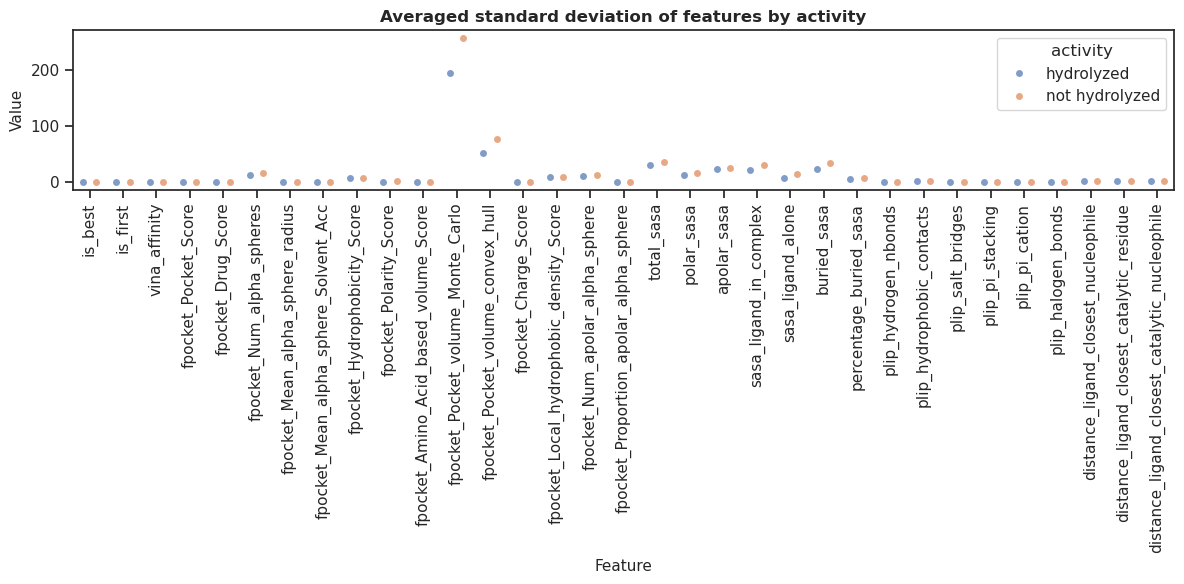

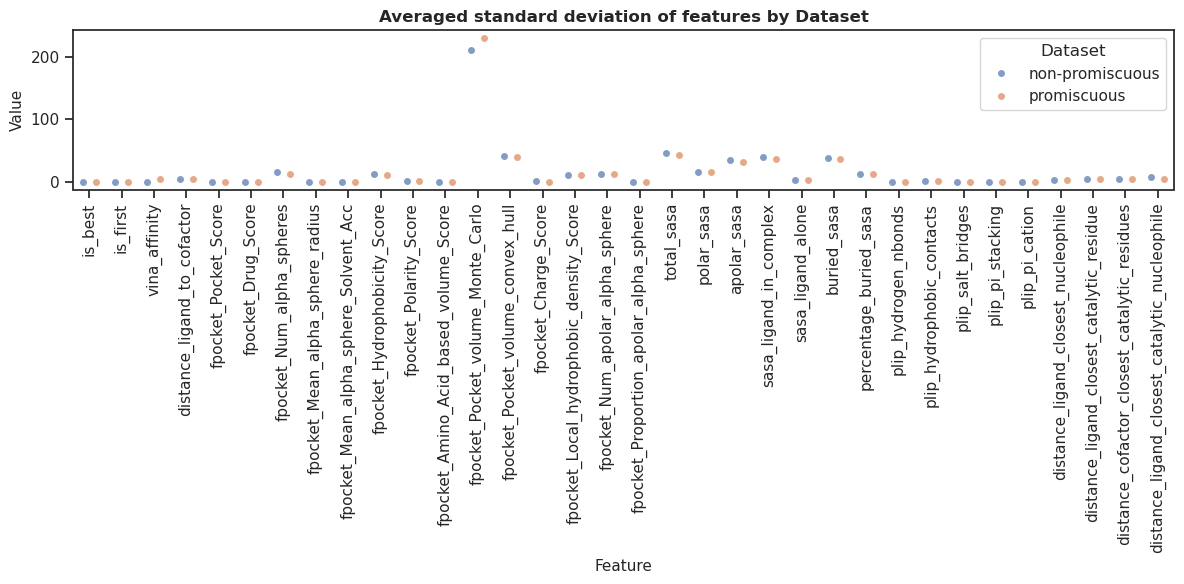

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_jittered_feature_scatter_seaborn(df, activity_col, jitter=True, jitter_width=0.3,
                                          figsize=(12,6), log_scale=False):
    # Filter numeric columns where not all zero
    numeric_cols = df.select_dtypes(include='number').columns
    cols_nonzero = [col for col in numeric_cols if df[col].sum() != 0]

    cols_to_keep = [activity_col] + cols_nonzero
    df_filtered = df[cols_to_keep]

    # turn into long df
    df_long = df_filtered.melt(id_vars=activity_col, var_name='Feature', value_name='Value')

    plt.figure(figsize=figsize)

    sns.stripplot(data=df_long, x='Feature', y='Value', hue=activity_col,
                  jitter=jitter, dodge=True, alpha=0.7)

    plt.xticks(rotation=90)
    plt.xlabel('Feature')
    plt.ylabel('Value')
    plt.title(f'Averaged standard deviation of features by {activity_col}')
    plt.legend(title=activity_col)
    plt.tight_layout()

    if log_scale:
        plt.yscale('log')

    plt.show()

plot_jittered_feature_scatter_seaborn(martinez_std_all_by_activity, activity_col='activity', jitter_width=0.25, log_scale=False)
plot_jittered_feature_scatter_seaborn(DEDB_std_all_by_activity, activity_col='Dataset', jitter_width=0.25, log_scale=False)

# Feature correlations

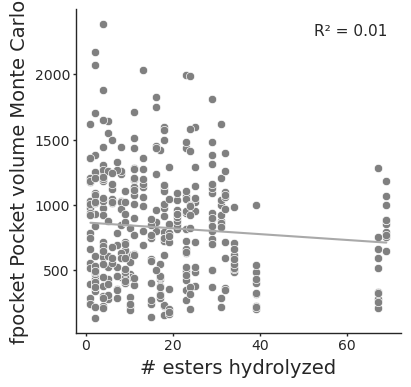

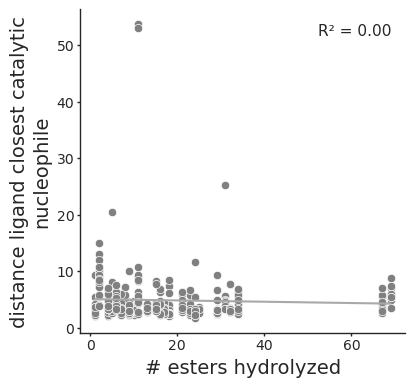

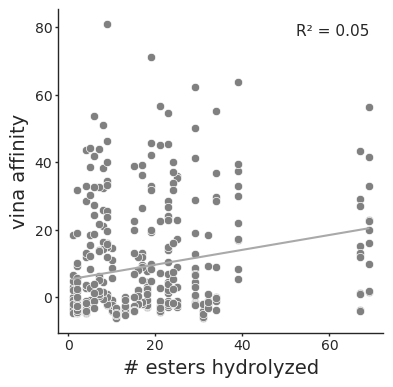

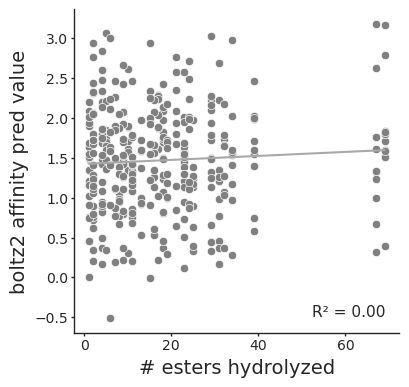

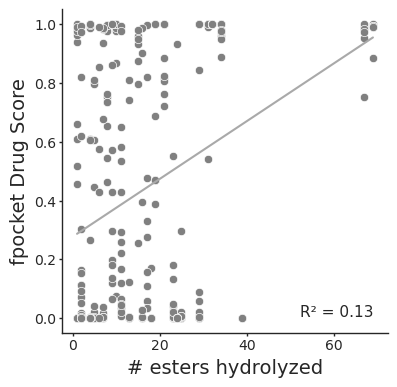

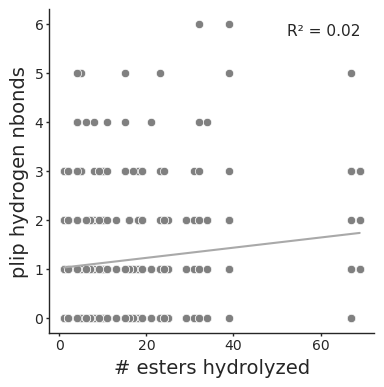

<Axes: xlabel='# esters hydrolyzed', ylabel='plip hydrogen nbonds'>

In [8]:
# Martinez

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from typing import Optional, Tuple


def plot_feature_scatter(
    df: pd.DataFrame,
    x: str,
    y: str,
    *,
    hue: Optional[str] = None,
    style: Optional[str] = None,
    size: Optional[str] = None,
    alpha: float = 1,
    palette: Optional[str] = None,   
    figsize: Tuple[float, float] = (4.2, 4.2),
    title: Optional[str] = None,
    annotate: Optional[str] = None,  # column to label points (e.g., "ID enzyme")
    coerce_numeric: bool = True,     
    dropna: bool = True,             
    logx: bool = False,
    logy: bool = False,
    add_trend: bool = False,         
    trend_per_hue: bool = False,     
    show_corr: bool = False,         
    save_path: Optional[str] = None
):

    # keep only needed columns
    cols = {x, y}
    for c in [hue, style, size, annotate]:
        if c is not None:
            cols.add(c)
    data = df[list(cols)].copy()

    # coerce features to numeric
    if coerce_numeric:
        data[x] = pd.to_numeric(data[x], errors="coerce")
        data[y] = pd.to_numeric(data[y], errors="coerce")

    if dropna:
        data = data.dropna(subset=[x, y])

    # plot
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=data, x=x, y=y,
        hue=hue, style=style, size=size,
        alpha=alpha, color="grey", ax=ax
    )

    # log scales
    if logx: ax.set_xscale("log")
    if logy: ax.set_yscale("log")

    # trend lines 
    if add_trend and not trend_per_hue:
        sns.regplot(data=data, x=x, y=y, scatter=False, ci=None, color="darkgrey", ax=ax, line_kws={"linewidth": 1.5})
    elif add_trend and trend_per_hue and hue is not None:
        for hval, sub in data.groupby(hue):
            if sub[x].notna().sum() > 1 and sub[y].notna().sum() > 1:
                sns.regplot(data=sub, x=x, y=y, scatter=False, color="darkgrey", ci=None, ax=ax, line_kws={"linewidth": 1.2})

    ax.set_xlabel('# esters hydrolyzed')
    ax.set_ylabel(y.replace("_", " "))

    if annotate is not None:
        for _, r in data.iterrows():
            ax.annotate(str(r[annotate]), (r[x], r[y]), xytext=(3, 3),
                        textcoords="offset points", fontsize=8)

    if show_corr:
        xnum = pd.to_numeric(data[x], errors="coerce")
        ynum = pd.to_numeric(data[y], errors="coerce")
        valid = xnum.notna() & ynum.notna()
        if valid.sum() >= 2:
            r = np.corrcoef(xnum[valid], ynum[valid])[0, 1]
            r2 = r**2
            ax.plot([], [], ' ', label=f"R² = {r2:.2f}")
            ax.legend()

    ax = pu.clean_plt(ax, max_label_chars=40)
    plt.legend(frameon=False)
    #plt.tight_layout()
    plt.show()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    return ax 


plt.rcParams.update({
    'svg.fonttype': 'path',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
    'axes.labelsize': 14,
    'axes.titleweight': 'semibold',
})

martinez_first_only_unique = martinez_first_only.drop_duplicates(subset='Entry', keep='first')

# Correlation active site volume vs promiscuity
plot_feature_scatter(
    martinez_first_only_unique,
    x="Nr of ester hydrolyzed",
    y="fpocket_Pocket_volume_Monte_Carlo",
    hue=None,
    add_trend=True,           
    show_corr=True           
)

# Correlation distance ligand to nucleophilic squidly residue
plot_feature_scatter(
    martinez_first_only_unique,
    x="Nr of ester hydrolyzed",
    y="distance_ligand_closest_catalytic_nucleophile",
    hue=None,
    add_trend=True,           
    show_corr=True            
)

martinez_vina_only_unique = martinez_vina_only.drop_duplicates(subset='Entry', keep='first')

# Correlation vina score vs promiscuity
plot_feature_scatter(
    martinez_vina_only_unique,
    x="Nr of ester hydrolyzed",
    y="vina_affinity",
    hue = None,
    add_trend=True,           
    show_corr=True            
)

martinez_boltz_only_unique = martinez_boltz_only.drop_duplicates(subset='Entry', keep='first')

# Correlation boltz affinity vs promiscuity
plot_feature_scatter(
    martinez_boltz_only_unique,
    x="Nr of ester hydrolyzed",
    y="boltz2_affinity_pred_value",
    hue = None,
    add_trend=True,           
    show_corr=True            
)


# Correlation f drug score affinity vs promiscuity
plot_feature_scatter(
    martinez_vina_only_unique,
    x="Nr of ester hydrolyzed",
    y="fpocket_Drug_Score",
    hue=None,
    add_trend=True,           
    show_corr=True            
)

# Correlation plip_hydrogen_nbonds vs promiscuity
plot_feature_scatter(
    martinez_vina_only_unique,
    x="Nr of ester hydrolyzed",
    y="plip_hydrogen_nbonds",
    hue=None,
    add_trend=True,           
    show_corr=True            
)


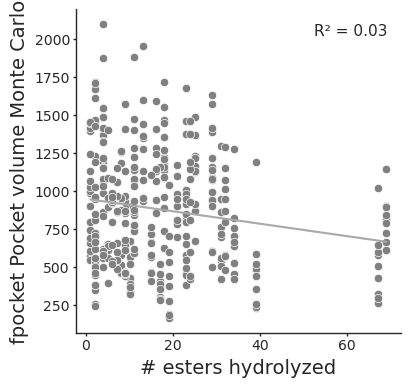

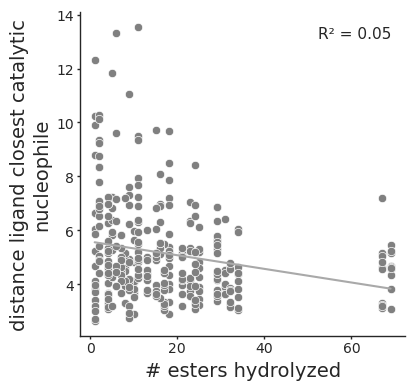

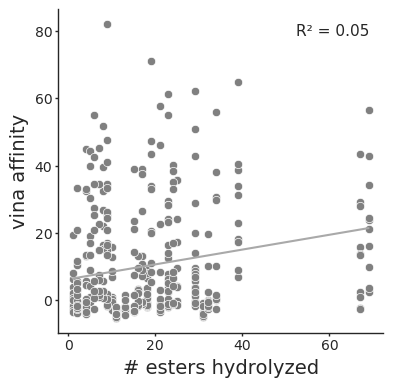

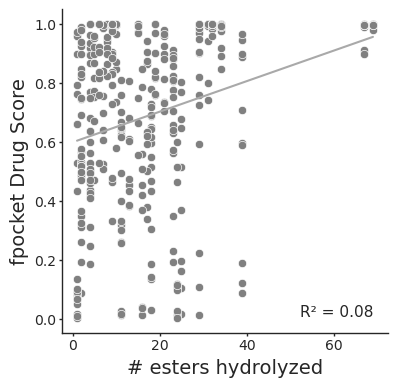

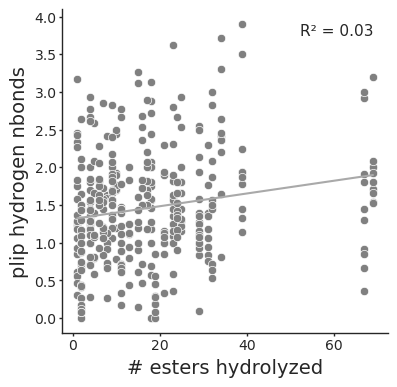

<Axes: xlabel='# esters hydrolyzed', ylabel='plip hydrogen nbonds'>

In [9]:
# Martinez - averaged

# Correlation active site volume vs promiscuity
plot_feature_scatter(
    martinez_avg_all,
    x="Nr of ester hydrolyzed",
    y="fpocket_Pocket_volume_Monte_Carlo",
    add_trend=True,           # optional
    show_corr=True            # optional
)

# Correlation distance ligand to nucleophilic squidly residue
plot_feature_scatter(
    martinez_avg_all,
    x="Nr of ester hydrolyzed",
    y="distance_ligand_closest_catalytic_nucleophile",
    add_trend=True,           # optional
    show_corr=True            # optional
)

# Correlation vina score vs promiscuity
plot_feature_scatter(
    martinez_avg_all,
    x="Nr of ester hydrolyzed",
    y="vina_affinity",
    add_trend=True,           # optional
    show_corr=True            # optional
)

# Correlation boltz affinity vs promiscuity



# Correlation f drug score affinity vs promiscuity
plot_feature_scatter(
    martinez_avg_all,
    x="Nr of ester hydrolyzed",
    y="fpocket_Drug_Score",
    add_trend=True,           # optional
    show_corr=True            # optional
)

# Correlation plip_hydrogen_nbonds vs promiscuity
plot_feature_scatter(
    martinez_avg_all,
    x="Nr of ester hydrolyzed",
    y="plip_hydrogen_nbonds",
    add_trend=True,           # optional
    show_corr=True            # optional
)

# PCA of features

### Martinez

In [10]:
import matplotlib.colors as mcolors 
mcolors.to_hex(pu.pastel_blue)

'#a1c9f4'

/tmp/ipykernel_1349886/1313946653.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)


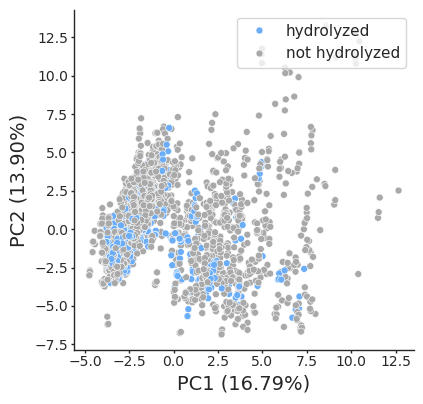

top PC1 loadings: entry_overall_mean_proteinRMSD    0.270598
chai-chai_mean_proteinRMSD        0.263591
chai_ptm                          0.263007
entry_overall_std_proteinRMSD     0.262901
boltz-chai_std_proteinRMSD        0.262552
boltz-chai_mean_proteinRMSD       0.252812
boltz-boltz_mean_proteinRMSD      0.252549
boltz-boltz_std_proteinRMSD       0.236492
boltz-vina_mean_proteinRMSD       0.228175
chai-chai_std_proteinRMSD         0.224421
Name: PC1, dtype: float64
top PC2 loadings: fpocket_Pocket_volume_Monte_Carlo        0.283297
sasa_ligand_in_complex                   0.267692
percentage_buried_sasa                   0.249474
total_sasa                               0.247489
fpocket_Pocket_volume_convex_hull        0.233333
polar_sasa                               0.227044
apolar_sasa                              0.208761
sasa_ligand_alone                        0.192593
fpocket_Mean_alpha_sphere_Solvent_Acc    0.188937
overall_ligandRMSD_mean                  0.180775
Name: PC

/tmp/ipykernel_1349886/1313946653.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)


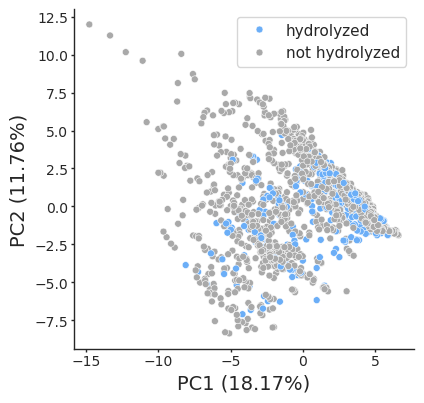

top PC1 loadings: boltz2_ptm                        0.221055
entry_overall_mean_proteinRMSD    0.209125
chai-chai_mean_proteinRMSD        0.208784
boltz2_confidence_score           0.204697
entry_overall_std_proteinRMSD     0.197905
boltz-chai_mean_proteinRMSD       0.196625
boltz-chai_std_proteinRMSD        0.193979
boltz-boltz_mean_proteinRMSD      0.192896
boltz2_complex_iplddt             0.186837
boltz2_complex_plddt              0.183829
Name: PC1, dtype: float64
top PC2 loadings: sasa_ligand_in_complex               0.217939
boltz-vina_mean_proteinRMSD          0.215143
fpocket_Pocket_volume_Monte_Carlo    0.210026
percentage_buried_sasa               0.205716
entry_overall_mean_proteinRMSD       0.194898
boltz-boltz_mean_proteinRMSD         0.190324
chai-vina_mean_proteinRMSD           0.189551
polar_sasa                           0.182498
boltz-vina_std_proteinRMSD           0.179038
entry_overall_std_proteinRMSD        0.176255
Name: PC2, dtype: float64


In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt


label_column = 'activity'
dPALETTE_grey_blue = ["#6baef7", "darkgrey"]

def visualize_PCA(df, feature_columns, missing_columns, label_column, tool, note, set_NaN_zero = False, ):
    label_column = label_column

    s2 = set(missing_columns)        
    feature_columns = [x for x in feature_columns if x not in s2]

    if tool == None: 
        df_normalized = df.loc[:,feature_columns + [label_column]].copy()
    else: 
        df_normalized = df.loc[df["tool"] == tool, feature_columns + [label_column]].copy()
    if set_NaN_zero == True: 
        df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)

    df_normalized.dropna(inplace=True)
    feature_columns = [c for c in feature_columns if c in df_normalized.columns]
    X = df_normalized[feature_columns].to_numpy()  
    y = df_normalized[label_column].to_numpy()    

    # standardize features using standard normalization i.e. mean=0 and variance=1
    scaler = StandardScaler()
    X_scaled  = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2, svd_solver="full", random_state=0)
    X_pca = pca.fit_transform(X_scaled)   

    # plot
    pca_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], label_column: y})
    exp_var_pct = pca.explained_variance_ratio_ * 100

    plt.figure(figsize=(4.4, 4.2))
    ax = sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=label_column, alpha = 1, s=25, palette=dPALETTE_grey_blue)
    ax.set_xlabel(f"PC1 ({exp_var_pct[0]:.2f}%)")
    ax.set_ylabel(f"PC2 ({exp_var_pct[1]:.2f}%)")
    #ax.set_title(f"PCA of standardized features ({tool} - {note})")
    pu.clean_plt(ax) 
    plt.legend(frameon=True, loc = 'upper right', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig(f'/nvme2/helen/masterthesis/3_manuscript/figures/PCA_overview_DEDB_{tool}_{note.replace(" ", "_")}.png', dpi=300)
    plt.show()
    

    # extract loadings

    # Loadings: each row is a PC, each column a feature
    loadings = pd.DataFrame(
        pca.components_.T, 
        index=feature_columns, 
        columns=[f'PC{i+1}' for i in range(pca.n_components_)]
    )

    # sort by absolute contribution
    top_PC1 = loadings['PC1'].abs().sort_values(ascending=False).head(10)
    top_PC2 = loadings['PC2'].abs().sort_values(ascending=False).head(10)
    print(f'top PC1 loadings: {top_PC1}')
    print(f'top PC2 loadings: {top_PC2}')


visualize_PCA(martinez, feature_columns_martinez, missing_columns_chai, 'activity', 'chai', 'first structures only', set_NaN_zero=True)
visualize_PCA(martinez, feature_columns_martinez, missing_columns_boltz, 'activity', 'boltz', 'first structures only', set_NaN_zero=True)
#visualize_PCA(martinez, feature_columns_martinez, missing_columns_vina, 'activity', 'vina', 'first structures only', set_NaN_zero=True)

/tmp/ipykernel_1349886/1717770213.py:84: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  is_categorical = pd.api.types.is_categorical_dtype(cvals) or cvals.dtype == object
/tmp/ipykernel_1349886/1717770213.py:84: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  is_categorical = pd.api.types.is_categorical_dtype(cvals) or cvals.dtype == object


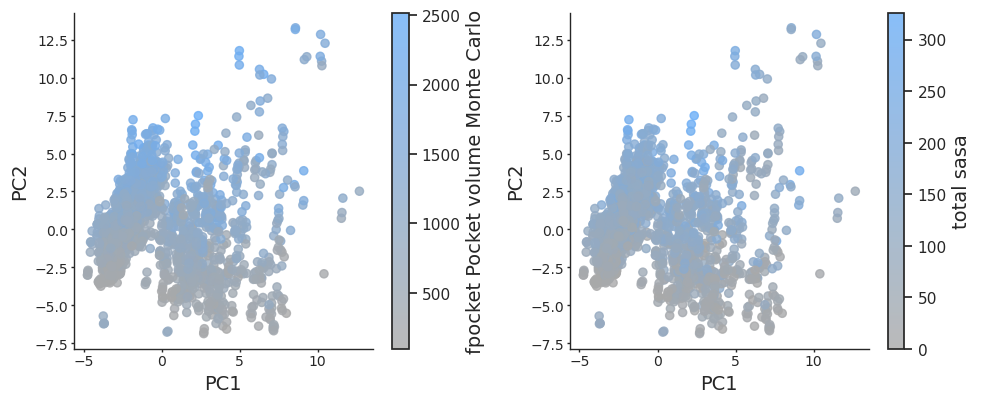

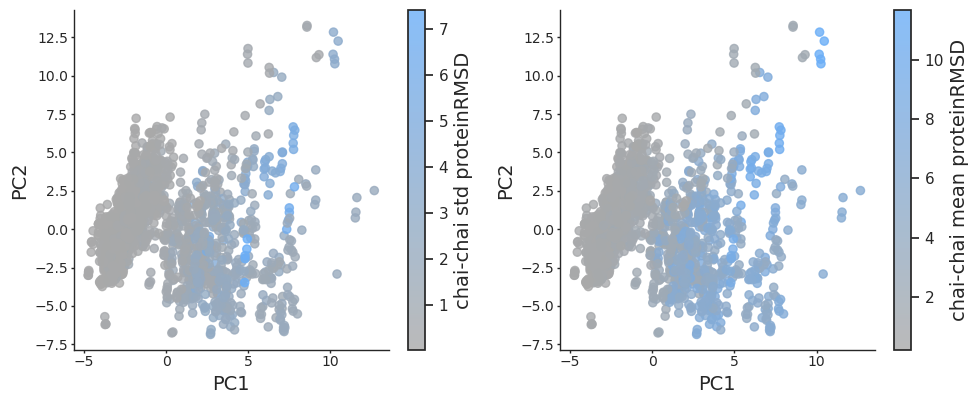

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cPALETTE_grey_blue = sns.blend_palette(["darkgrey", "#6baef7"], as_cmap=True)
dPALETTE_grey_blue = ["#6baef7", "darkgrey"]

def pca_scatter_color_by_features(
    df: pd.DataFrame,
    feature_columns: list,
    color_by,                     
    *,
    label_column: str = None,     
    tool: str | None = None,
    set_NaN_zero: bool = False,    
    scale: bool = True,
    n_components: int = 2,
    point_alpha: float = 0.8,
    point_size: float = 35,
    cmap: str = "viridis",
    figsize_per_plot=(5, 4.2),
    title_prefix: str = "PCA colored by"
):
    """
    Runs PCA on feature_columns and plot as scatter plot

    """

    cols_needed = set(feature_columns)
    cols_missing = [c for c in feature_columns if c not in df.columns]
    if cols_missing:
        if set_NaN_zero:
            for c in cols_missing:
                df[c] = 0.0
        else:
            print(f"Warning: dropping missing feature columns: {cols_missing}")
            feature_columns = [c for c in feature_columns if c in df.columns]
            if not feature_columns:
                raise ValueError("No valid feature columns remain after dropping missing ones.")

    # filter by tool 
    if tool is not None:
        if "tool" not in df.columns:
            raise KeyError("'tool' column not found in df, but tool filtering was requested.")
        work = df.loc[df["tool"] == tool].copy()
    else:
        work = df.copy()

    color_missing = [c for c in color_by if c not in work.columns]
    if color_missing:
        if set_NaN_zero:
            for c in color_missing:
                work[c] = 0.0
            print(f"Info: created missing color_by columns as zeros: {color_missing}")
        else:
            raise KeyError(f"color_by columns not found in DataFrame: {color_missing}")

    # subset X for PCA
    X = work[feature_columns].to_numpy(dtype=float)
    # handle NaNs
    if np.isnan(X).any():
        X = np.nan_to_num(X, nan=0.0)

    # scale
    if scale:
        X = StandardScaler().fit_transform(X)

    # PCA
    pca = PCA(n_components=n_components, random_state=0)
    Z = pca.fit_transform(X)  # shape (n_samples, n_components)

    n_plots = len(color_by)
    fig, axes = plt.subplots(
        1, n_plots,
        figsize=(figsize_per_plot[0] * n_plots, figsize_per_plot[1]),
        squeeze=False
    )
    axes = axes[0]

    for ax, cfeat in zip(axes, color_by):
        cvals = work[cfeat]
        is_categorical = pd.api.types.is_categorical_dtype(cvals) or cvals.dtype == object
        cfeat = cfeat.replace("_", " ")

        if is_categorical:
            # map categories to integers for coloring and build a legend
            cats = pd.Categorical(cvals)
            codes = cats.codes  # -1 for NaN
            sc = ax.scatter(Z[:, 0], Z[:, 1], c=codes, s=point_size, alpha=point_alpha, cmap=cPALETTE_grey_blue)
            # legend with unique categories
            norm = plt.Normalize(vmin=codes.min(), vmax=codes.max())
            handles = []
            labels = []
            for code, name in enumerate(cats.categories):
                color = cmap(norm(code))
                h = ax.scatter([], [], color=color, label=str(name), s=point_size)
                handles.append(h)
                labels.append(str(name))
            ax.legend(handles, labels, title=cfeat, loc="best", frameon=True)
            
        else:
            # continuous
            carray = pd.to_numeric(cvals, errors="coerce").to_numpy()
            # optional NaN handling in color_by
            if np.isnan(carray).any():
                carray = np.nan_to_num(carray, nan=np.nanmean(carray) if not np.isnan(np.nanmean(carray)) else 0.0)
            sc = ax.scatter(Z[:, 0], Z[:, 1], c=carray, s=point_size, alpha=point_alpha, cmap=cPALETTE_grey_blue)
            cb = plt.colorbar(sc, ax=ax)
            cb.set_label(cfeat)

        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(False)
        pu.clean_plt(ax)

    plt.tight_layout()

    return fig, axes, pca



fig, axes, pca  = pca_scatter_color_by_features(
    df=martinez,
    feature_columns=feature_columns_martinez,
    color_by=["fpocket_Pocket_volume_Monte_Carlo", "total_sasa"],
    label_column="activity",       
    tool='chai',                    
    set_NaN_zero=True,              
    cmap=sns.blend_palette(["lightgrey", "cadetblue"], as_cmap=True)    
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/PCA_chai_fpocket_volume_monte_carlo_total_sasa_chai_proteinRMSD.png', dpi=300)

fig, axes, pca = pca_scatter_color_by_features(
    df=martinez,
    feature_columns=feature_columns_martinez,
    color_by=["chai-chai_std_proteinRMSD", "chai-chai_mean_proteinRMSD"],
    label_column="activity",        
    tool='chai',                      
    set_NaN_zero=True,                
    cmap=sns.blend_palette(["lightgrey", "cadetblue"], as_cmap=True)
)


fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/PCA_chai_chai_proteinRMSD.png', dpi=300)

### DEDB

/tmp/ipykernel_1349886/1313946653.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_normalized[feature_columns] = df_normalized[feature_columns].fillna(0)


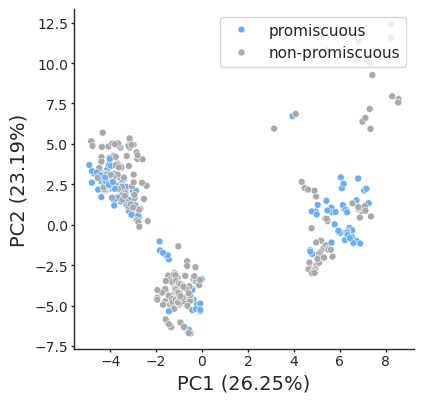

top PC1 loadings: boltz-chai_mean_proteinRMSD       0.234131
chai_ptm                          0.234020
entry_overall_mean_proteinRMSD    0.233793
chai-vina_mean_proteinRMSD        0.232967
entry_overall_std_proteinRMSD     0.232339
chai-chai_mean_proteinRMSD        0.230674
boltz-chai_std_proteinRMSD        0.226970
chai-vina_std_proteinRMSD         0.222370
boltz-vina_std_proteinRMSD        0.217534
boltz-boltz_mean_proteinRMSD      0.214970
Name: PC1, dtype: float64
top PC2 loadings: boltz_chai_mean_ligandRMSD                 0.220579
overall_ligandRMSD_mean                    0.218501
overall_ligandRMSD_std                     0.213465
chai_vina_mean_ligandRMSD                  0.211130
fpocket_Num_apolar_alpha_sphere            0.199031
fpocket_Local_hydrophobic_density_Score    0.197975
fpocket_Pocket_Score                       0.195221
chai_chai_mean_ligandRMSD                  0.192479
polar_sasa                                 0.191132
chai_chai_std_ligandRMSD                

In [13]:
# PCA of DEDB

#visualize_PCA(DEDB, feature_columns_DEDB, missing_columns_chai, 'Dataset', None,'all structures', set_NaN_zero=True)
visualize_PCA(DEDB, feature_columns_DEDB, missing_columns_chai, 'Dataset', 'chai','all structures', set_NaN_zero=True)

#visualize_PCA(DEDB, feature_columns_DEDB, missing_columns_boltz, 'Dataset', 'boltz', 'all structures',set_NaN_zero=False)
#visualize_PCA(DEDB, feature_columns_DEDB, missing_columns_vina, 'Dataset', 'vina', 'all structures',set_NaN_zero=False)

/tmp/ipykernel_1349886/1717770213.py:84: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  is_categorical = pd.api.types.is_categorical_dtype(cvals) or cvals.dtype == object
/tmp/ipykernel_1349886/1717770213.py:84: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  is_categorical = pd.api.types.is_categorical_dtype(cvals) or cvals.dtype == object
/tmp/ipykernel_1349886/1717770213.py:84: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  is_categorical = pd.api.types.is_categorical_dtype(cvals) or cvals.dtype == object
/tmp/ipykernel_1349886/1717770213.py:84: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) i

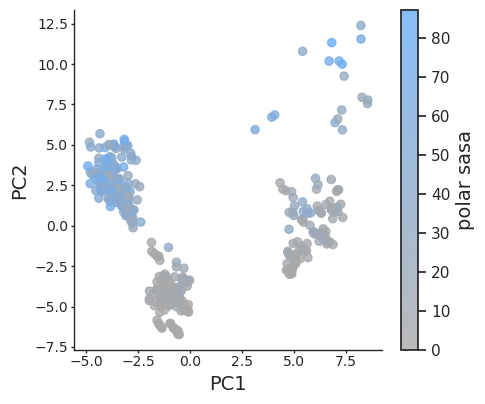

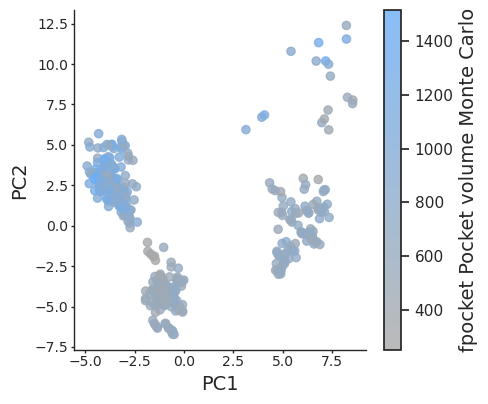

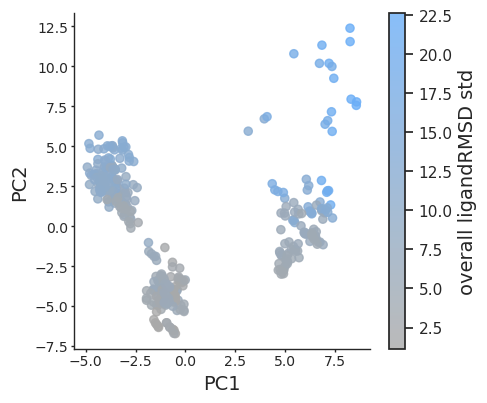

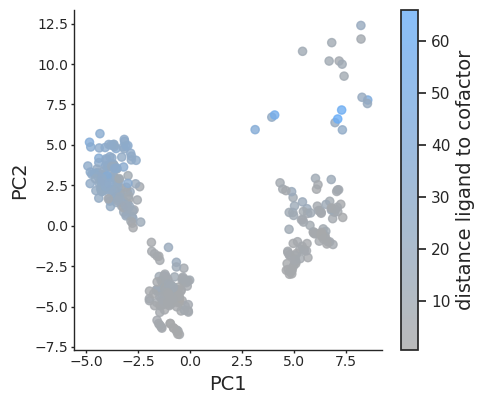

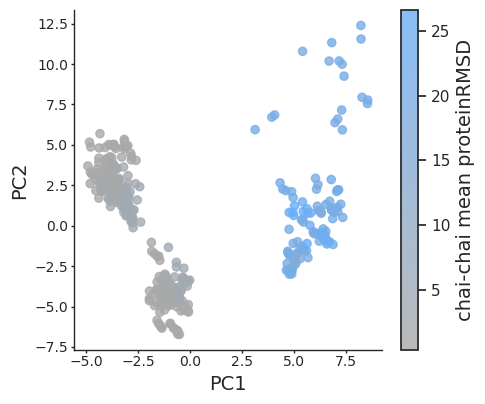

In [14]:


fig, axes, pca  = pca_scatter_color_by_features(
    df=DEDB,
    feature_columns=feature_columns_DEDB,
    color_by=["polar_sasa"],
    label_column="activity",           
    tool='chai',                         
    set_NaN_zero=True   
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/DEDB_PCA_chai_polar_sasa.png', dpi=300)


fig, axes, pca  = pca_scatter_color_by_features(
    df=DEDB,
    feature_columns=feature_columns_DEDB,
    color_by=["fpocket_Pocket_volume_Monte_Carlo"],
    label_column="activity",           
    tool='chai',                         
    set_NaN_zero=True   
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/DEDB_PCA_chai_fpocket_volume_monte_carlo.png', dpi=300)

fig, axes, pca  = pca_scatter_color_by_features(
    df=DEDB,
    feature_columns=feature_columns_DEDB,
    color_by=["overall_ligandRMSD_std"],
    label_column="activity",          
    tool='chai',                        
    set_NaN_zero=True
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/DEDB_PCA_chai_overall_ligandRMSD_std.png', dpi=300)

fig, axes, pca  = pca_scatter_color_by_features(
    df=DEDB,
    feature_columns=feature_columns_DEDB,
    color_by=["distance_ligand_to_cofactor"],
    label_column="activity",          
    tool='chai',                         
    set_NaN_zero=True)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/DEDB_PCA_chai_distance_ligand_to_cofactor.png', dpi=300)

fig, axes, pca = pca_scatter_color_by_features(
    df=DEDB,
    feature_columns=feature_columns_DEDB,
    color_by=["chai-chai_mean_proteinRMSD"],
    label_column="activity",           
    tool='chai',                         
    set_NaN_zero=True)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/DEDB_PCA_chai_chai_mean_proteinRMSD.png', dpi=300)

## Make binary plots

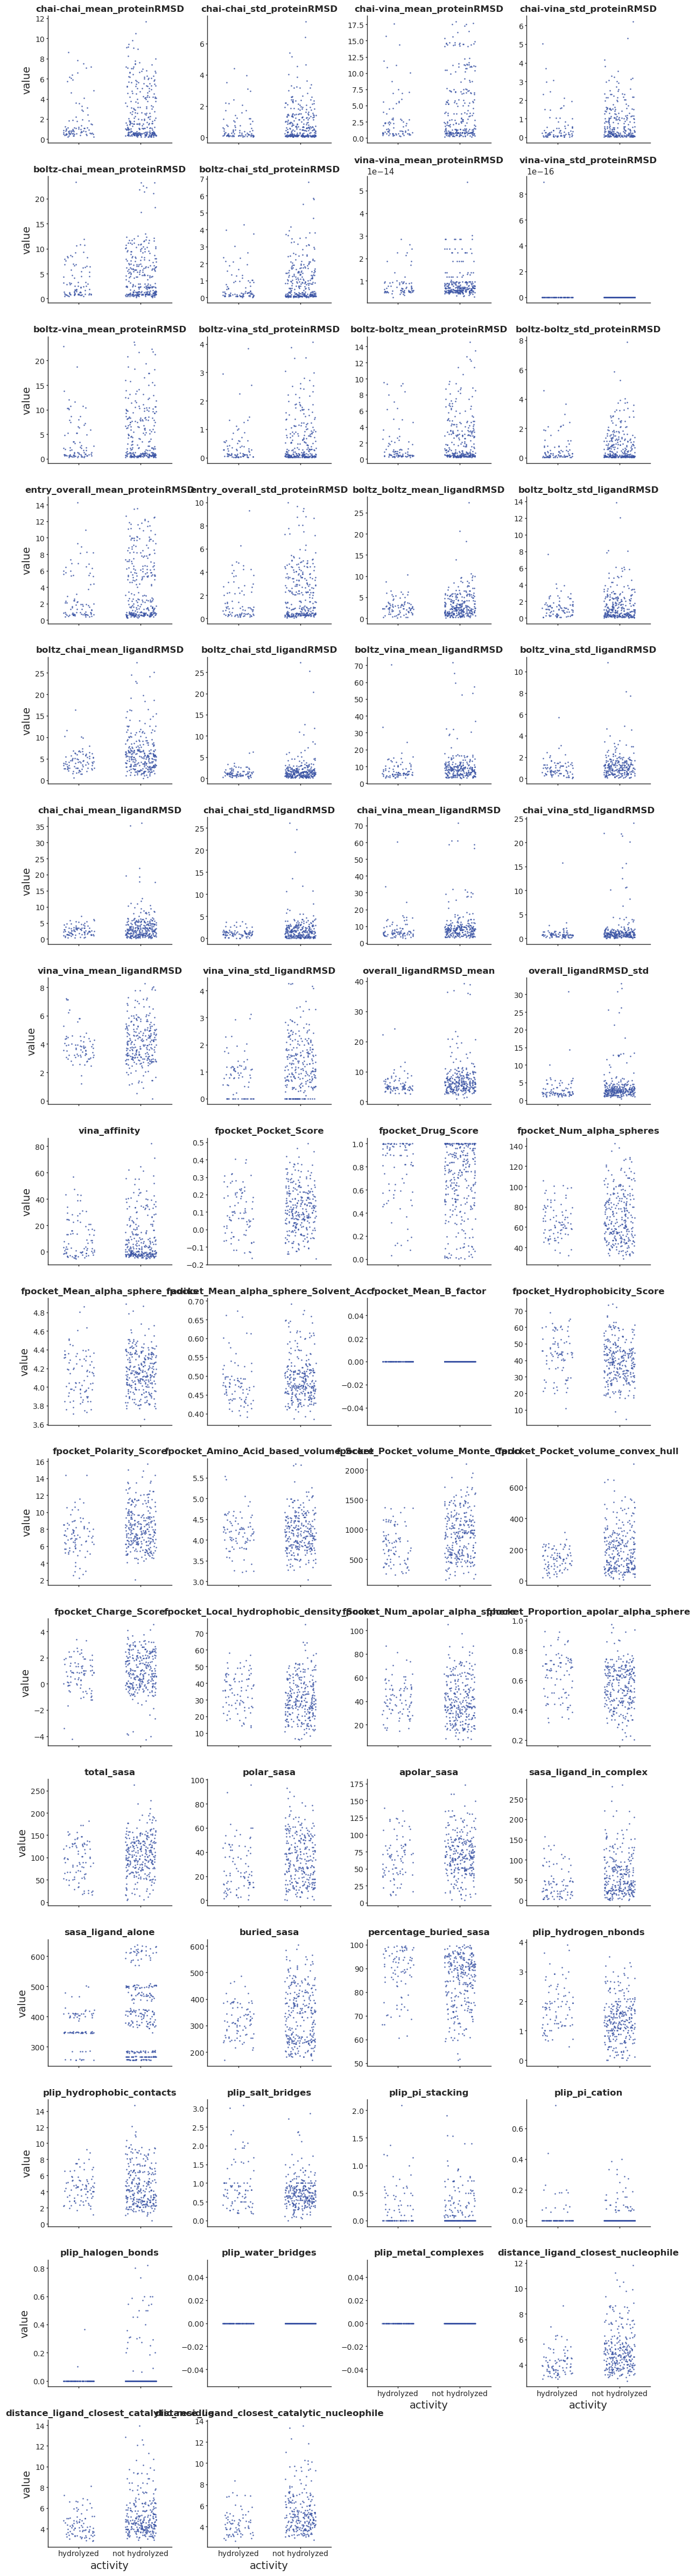

In [15]:
def scatter_all_vs_activity(df, feature_columns, label_col="activity", col_wrap=4, height=3):
    # Long format: one row per (sample, feature)
    df_long = df[feature_columns + [label_col]].melt(
        id_vars=[label_col], var_name="feature", value_name="value"
    ).dropna(subset=["value"])

    g = sns.catplot(
        data=df_long,
        x=label_col, y="value",
        col="feature", col_wrap=col_wrap, kind="strip",
        color="#3A53A4",
        jitter=0.25, s=4, alpha=0.8, height=height, sharex=True, sharey=False
    )

    for ax in g.axes.flatten():
        ax.set_xlabel(label_col)
        ax.set_title(ax.get_title().split(" = ")[-1])  # cleaner facet titles
        try:
            clean_plt(ax)
        except NameError:
            pass
    clean_plt(ax) 
    plt.tight_layout()
    plt.show()


missing_columns = ['boltz2_affinity_pred_value', 'boltz2_affinity_probability_binary', 'boltz2_affinity_pred_value1', 'boltz2_affinity_probability_binary1', 'boltz2_affinity_pred_value2', 'boltz2_affinity_probability_binary2', 
                   'boltz2_chains_ptm', 'boltz2_pair_chains_iptm', 'chai_aggregate_score', 'chai_ptm', 'chai_iptm', 'boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 'boltz2_complex_iplddt', 'boltz2_complex_pde', 'boltz2_complex_ipde']
s2 = set(missing_columns)        
feature_columns_martinez = [x for x in feature_columns_martinez if x not in s2]

scatter_all_vs_activity(martinez_avg_all, feature_columns_martinez, label_col="activity", col_wrap=4)


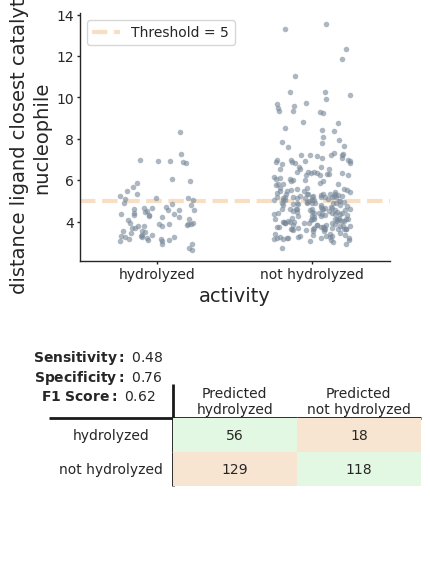

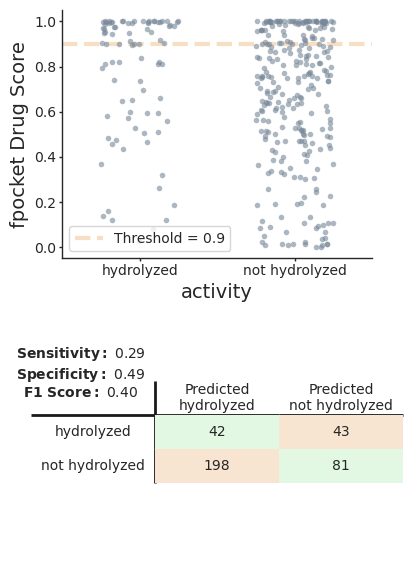

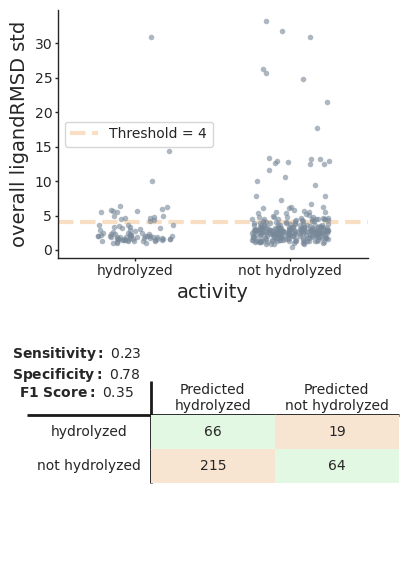

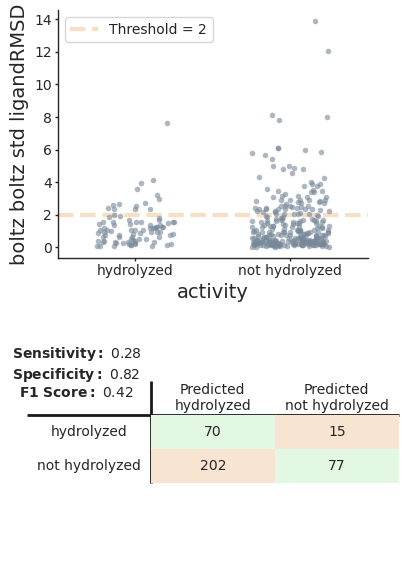

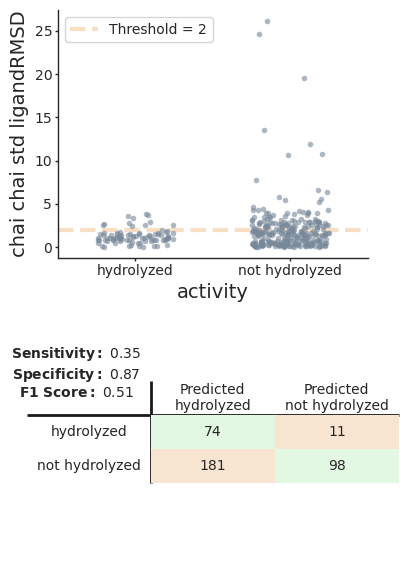

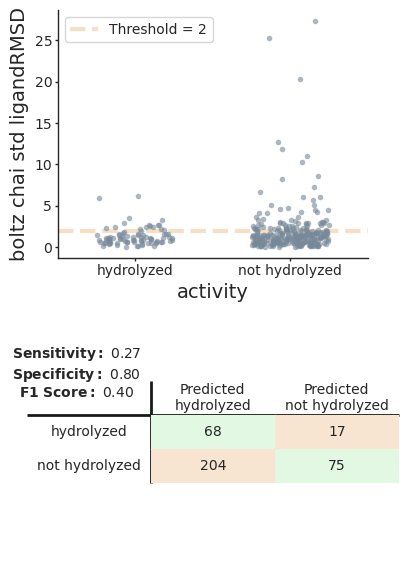

In [16]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

def plot_feature_with_threshold(df, feature, threshold, label_col="activity"):
    """
    Plot a feature against a binary label with a threshold line, and show a table
    with confusion matrix values and sensitivity/specificity.
    """
    # Filter out missing values
    data = df[[feature, label_col]].dropna()
    unique_labels = data[label_col].unique()
    
    # Map string labels to binary: {label_0: 0, label_1: 1}
    label_mapping = {label: i for i, label in enumerate(sorted(unique_labels))}
    inv_label_mapping = {v: k for k, v in label_mapping.items()}
    
    data["label_binary"] = data[label_col].map(label_mapping)
    
    # Predictions based on threshold
    data["pred_binary"] = (data[feature] >= threshold).astype(int)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(data["label_binary"], data["pred_binary"]).ravel()

    # Metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    fig = plt.figure(figsize=(4, 7))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1]) 
    
    # plot with threshold line
    ax0 = fig.add_subplot(gs[0])
    sns.stripplot(
        data=data, x=label_col, y=feature, color='lightslategrey', jitter=0.25, alpha=0.6, size=4, ax=ax0 )
    ax0.axhline(threshold, color="#F8DFC3", linestyle='--', label=f"Threshold = {threshold}", linewidth = 3)
    ax0.legend(fontsize=10)
    ax0.set_ylabel(feature.replace("_", " "))

    # Table with confusion matrix and metrics
    actual_0 = inv_label_mapping[0]
    actual_1 = inv_label_mapping[1]
    f1 = f1_score(data["label_binary"], data["pred_binary"]) if (tp + fp) > 0 and (tp + fn) > 0 else 0

    table_data = [
        ["", f"Predicted\n{actual_0}", f"Predicted\n{actual_1}"],
        [f"{actual_0}", f"{tn}", f"{fp}"],
        [f"{actual_1}", f"{fn}", f"{tp}"]
    ]

    ax1 = fig.add_subplot(gs[1])
    ax1.axis("off")
    
    table = ax1.table(
        cellText=table_data,
        loc="center",
        cellLoc='center',
        colWidths=[0.2, 0.2, 0.2]
    )

    for cell in table.get_celld().values():
        cell.visible_edges = 'LBRT'
        cell.set_linewidth(0.0)  # keep a consistent width for the edges we add

    table[(2,1)].set_facecolor("#F7E5D2")  
    table[(1,1)].set_facecolor("#E3F8E3")  
    table[(1,2)].set_facecolor("#F7E5D2")  
    table[(2,1)].set_facecolor("#F7E5D2")  
    table[(2,2)].set_facecolor("#E3F8E3")  

    table[(1,0)].visible_edges = 'RT' 
    cell = table[(1,0)]
    cell.set_linewidth(2.0)

    table[(2,0)].visible_edges = 'R' 
    cell = table[(2,0)]
    cell.set_linewidth(2.0)

    table[(0,1)].visible_edges = 'LB' 
    cell = table[(0,1)]
    cell.set_linewidth(2.0)

    table[(0,2)].visible_edges = 'B' 
    cell = table[(0,2)]
    cell.set_linewidth(2.0)

    # Adjust scaling & position
    table.scale(2, 2)
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    # Push plot area up so table has space
    clean_plt(ax0,max_label_chars=40)
    clean_plt(ax1, max_label_chars=40)
    plt.subplots_adjust(bottom=0.1)

    # Place a styled text box
    metrics_text = (
    r"$\bf{Sensitivity:}$" + f" {sensitivity:.2f}\n"
    + r"$\bf{Specificity:}$" + f" {specificity:.2f}\n"
    + r"$\bf{F1\ Score:}$" + f" {f1:.2f}"
)
    ax1.text(
        0.06, 0.85, metrics_text,
        ha='center', va='top', fontsize=10,
        transform=ax1.transAxes
        #bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="lightslategrey")
    )
    
    plt.show()


plot_feature_with_threshold(
    df=martinez_avg_all,
    feature="distance_ligand_closest_catalytic_nucleophile",  # or any single feature you want
    threshold=5,
    label_col="activity"  # binary column: 0 or 1
)

plot_feature_with_threshold(
    df=martinez_avg_all,
    feature="fpocket_Drug_Score",  # or any single feature you want
    threshold=0.9,
    label_col="activity"  # binary column: 0 or 1
)

plot_feature_with_threshold(
    df=martinez_avg_all,
    feature="overall_ligandRMSD_std",  # or any single feature you want
    threshold=4,
    label_col="activity"  # binary column: 0 or 1
)

plot_feature_with_threshold(
    df=martinez_avg_all,
    feature="boltz_boltz_std_ligandRMSD",  # or any single feature you want
    threshold=2,
    label_col="activity"  # binary column: 0 or 1
)

plot_feature_with_threshold(
    df=martinez_avg_all,
    feature="chai_chai_std_ligandRMSD",  # or any single feature you want
    threshold=2,
    label_col="activity"  # binary column: 0 or 1
)


plot_feature_with_threshold(
    df=martinez_avg_all,
    feature="boltz_chai_std_ligandRMSD",  # or any single feature you want
    threshold=2,
    label_col="activity"  # binary column: 0 or 1
)

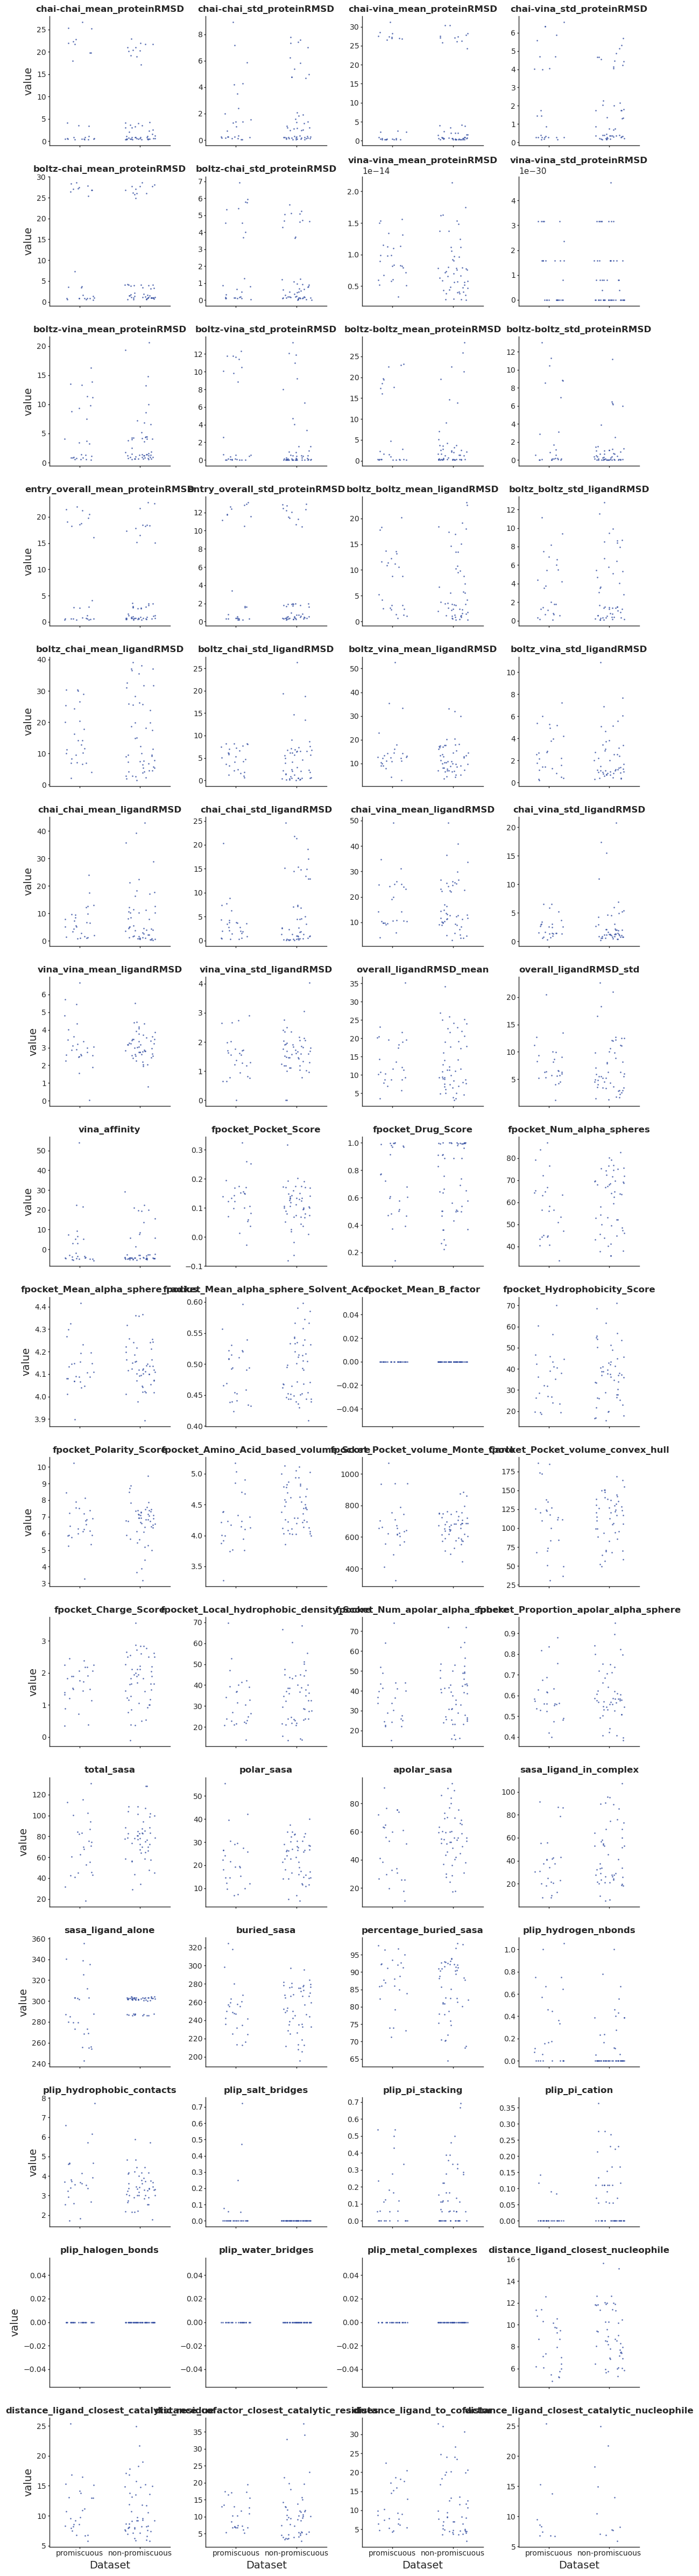

In [17]:

missing_columns = ['boltz2_affinity_pred_value', 'boltz2_affinity_probability_binary', 'boltz2_affinity_pred_value1', 'boltz2_affinity_probability_binary1', 'boltz2_affinity_pred_value2', 'boltz2_affinity_probability_binary2', 
                   'boltz2_chains_ptm', 'boltz2_pair_chains_iptm', 'chai_aggregate_score', 'chai_ptm', 'chai_iptm', 'boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 'boltz2_complex_iplddt', 'boltz2_complex_pde', 'boltz2_complex_ipde']
s2 = set(missing_columns)        
feature_columns_DEDB = [x for x in feature_columns_DEDB if x not in s2]

scatter_all_vs_activity(DEDB_avg_all, feature_columns_DEDB, label_col="Dataset", col_wrap=4)

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap as tw

# stats
from scipy.stats import mannwhitneyu, ttest_ind, kruskal
try:
    from statsmodels.stats.multitest import multipletests
    _has_statsmodels = True
except Exception:
    _has_statsmodels = False

def _format_p(p):
    if p is None or np.isnan(p):
        return "p = n/a"
    if p < 1e-4:
        return "p < 1e-4 ***"
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    return f"p = {p:.2e} {stars}"

def violin_all_vs_activity_with_p(
    df, feature_columns, label_col="activity",
    col_wrap=4, height=3,
    overlay_jitter=0.18, overlay_size=1.6, overlay_alpha=0.7,
    test="mannwhitney",            # 'mannwhitney' | 'ttest' | 'auto'
    adjust="fdr_bh"                # 'fdr_bh' | None
):
    """
    Violin plots per feature vs. label with raw-point overlay and per-feature p-value.
    - For 2 classes: Mann–Whitney (default) or t-test if test='ttest'
    - For >2 classes: Kruskal–Wallis
    - adjust='fdr_bh' applies Benjamini–Hochberg (requires statsmodels)
    """
    # Long format
    df_long = (
        df[feature_columns + [label_col]]
        .melt(id_vars=[label_col], var_name="feature", value_name="value")
        .dropna(subset=["value"])
    )

    # Colors
    try:
        blue = pu.pastel_blue
    except Exception:
        blue = "#6baef7"

    cats = pd.Categorical(df_long[label_col]).categories.tolist()
    if len(cats) == 2:
        palette_map = {cats[0]: "darkgrey", cats[1]: blue}
    else:
        # fallback palette for multi-class
        palette_map = sns.color_palette("tab10", n_colors=len(cats))

    # ---- compute p-values per feature ----
    pvals = {}
    features_present = df_long["feature"].unique().tolist()

    for feat in features_present:
        sub = df_long.loc[df_long["feature"] == feat]
        groups = [sub.loc[sub[label_col] == c, "value"].dropna().values for c in cats]
        # drop empty groups
        groups = [g for g in groups if len(g) > 0]

        p = np.nan
        if len(groups) == 2:
            a, b = groups
            if len(a) > 0 and len(b) > 0:
                if test == "ttest":
                    p = ttest_ind(a, b, equal_var=False, nan_policy="omit").pvalue
                elif test == "auto":
                    # heuristic: if both groups fairly large and look normal-ish you might choose ttest;
                    # we keep it simple and use MWU:
                    p = mannwhitneyu(a, b, alternative="two-sided").pvalue
                else:
                    p = mannwhitneyu(a, b, alternative="two-sided").pvalue
        elif len(groups) > 2:
            # Kruskal–Wallis for k>2
            try:
                p = kruskal(*groups, nan_policy="omit").pvalue
            except Exception:
                p = np.nan

        pvals[feat] = p

    # Optional multiple testing correction
    if adjust and _has_statsmodels:
        feats = list(pvals.keys())
        raw = np.array([pvals[f] if pvals[f] is not None else np.nan for f in feats], dtype=float)
        mask = ~np.isnan(raw)
        if mask.sum() > 0:
            _, p_adj, _, _ = multipletests(raw[mask], method=adjust)
            for f, padj in zip(np.array(feats)[mask], p_adj):
                pvals[f] = float(padj)
    elif adjust and not _has_statsmodels:
        print("Warning: statsmodels not available; skipping multiple-testing correction.")

    # ---- plot violins ----
    g = sns.catplot(
        data=df_long,
        x=label_col, y="value",
        col="feature", col_wrap=col_wrap,
        kind="violin",
        hue=label_col,
        palette=palette_map,
        dodge=False,
        inner="quartile",
        cut=0,
        linewidth=0.8,
        height=height,
        sharex=True, sharey=False,
        legend=False
    )

    for key, ax in g.axes_dict.items():
        feat = key if isinstance(key, str) else key[-1]
        wrapped = tw.fill(str(feat).replace("_", " "), width=18)  # adjust width to taste
        ax.set_title(wrapped, fontsize=9, pad=10)

    # overlay raw points in black
    g.map_dataframe(
        sns.stripplot,
        x=label_col, y="value",
        color="black",
        jitter=overlay_jitter,
        size=overlay_size,
        alpha=overlay_alpha,
        dodge=False,
        linewidth=0
    )

    # annotate p on each facet, keep x ticks visible
    for key, ax in g.axes_dict.items():  # key is the facet value of "feature"
        feat = key if isinstance(key, str) else key[-1]
        ax.tick_params(axis='x', labelbottom=True)
        for lbl in ax.get_xticklabels():
            lbl.set_visible(True)
        ax.set_title(feat)

        # place p-value in the top center of the panel
        p = pvals.get(feat, np.nan)
        ax.text(0.5, 0.98, _format_p(p), transform=ax.transAxes,
                ha="center", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8))

        # optional cleanup
        try:
            pu.clean_plt(ax)
        except Exception:
            pass

    g.set_axis_labels(label_col, "value")
    plt.tight_layout()
    plt.show()

    # return p-values for reference
    return pd.DataFrame({"feature": list(pvals.keys()), "p_value": list(pvals.values())})\
             .sort_values("p_value", na_position="last")


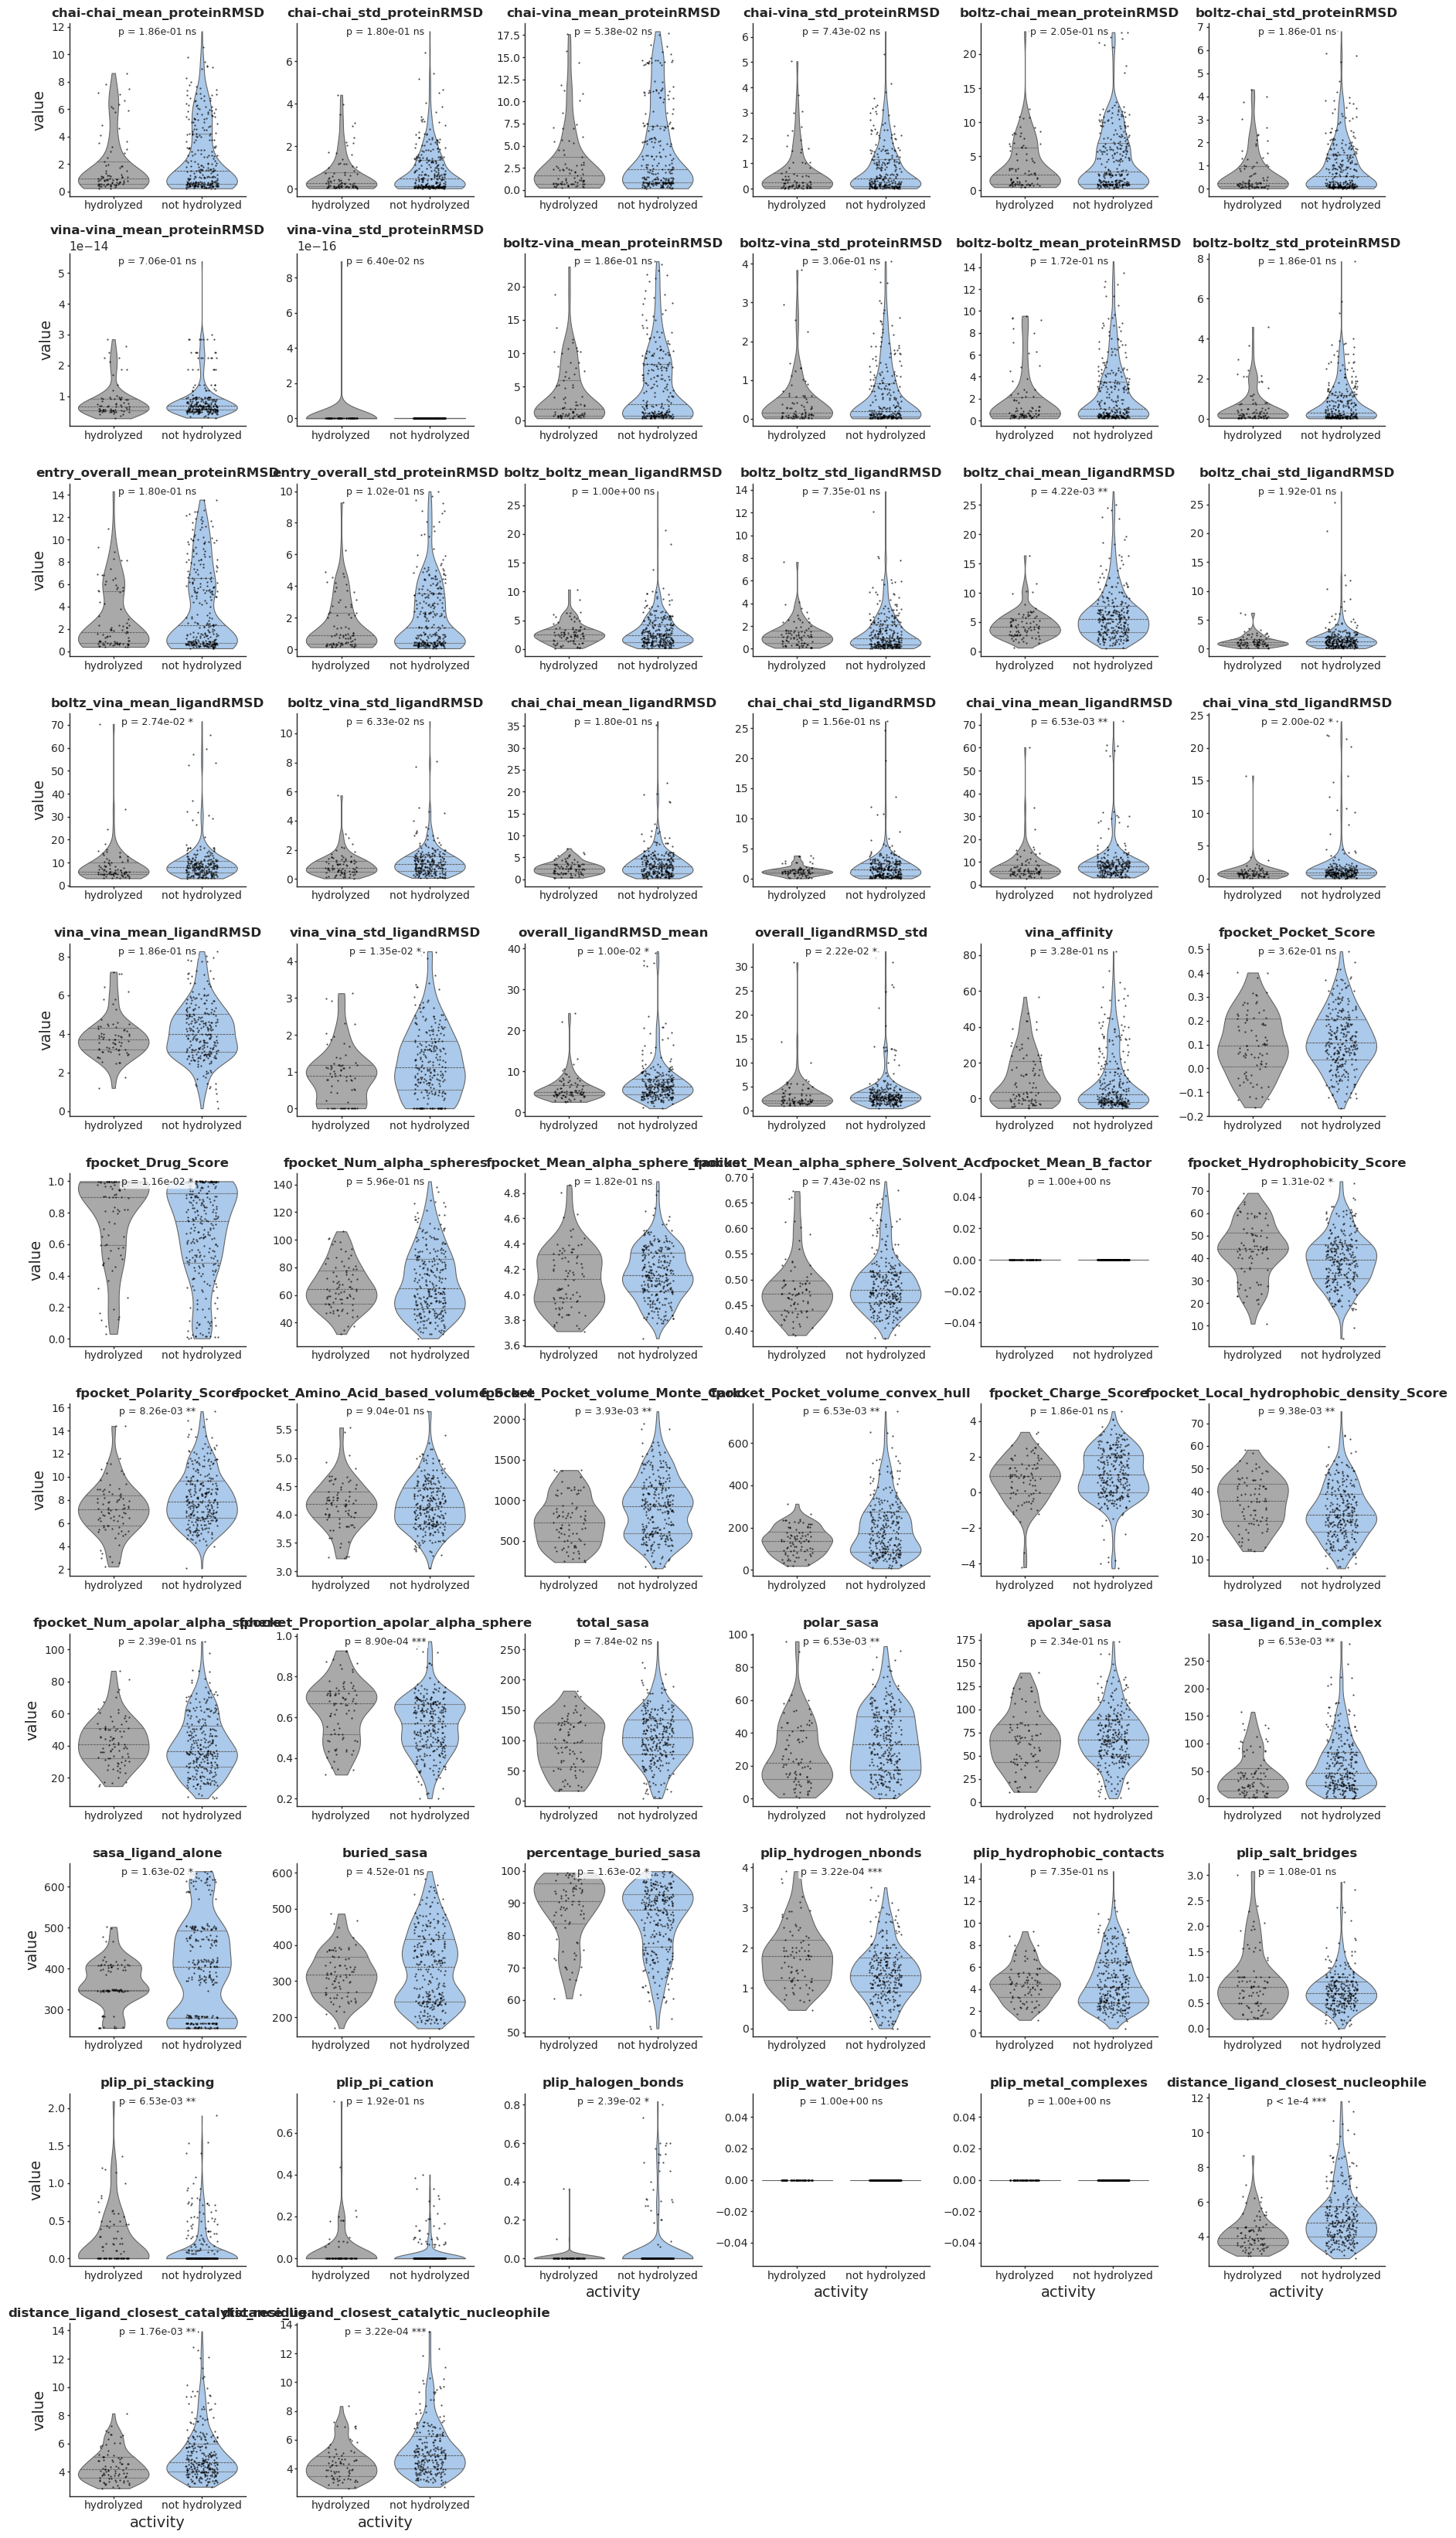

                                          feature   p_value
59            distance_ligand_closest_nucleophile  0.000001
51                           plip_hydrogen_nbonds  0.000322
61  distance_ligand_closest_catalytic_nucleophile  0.000322
43         fpocket_Proportion_apolar_alpha_sphere  0.000890
60      distance_ligand_closest_catalytic_residue  0.001755


In [37]:
s2 = set(missing_columns)
feature_columns_martinez = [x for x in feature_columns_martinez if x not in s2]

pvals_df = violin_all_vs_activity_with_p(
    martinez_avg_all,
    feature_columns_martinez,
    label_col="activity",
    col_wrap=6,
    height=3,
    test="mannwhitney",   # or 'ttest' or 'auto'
    adjust="fdr_bh"       # or None (requires statsmodels to apply)
)
print(pvals_df.head())


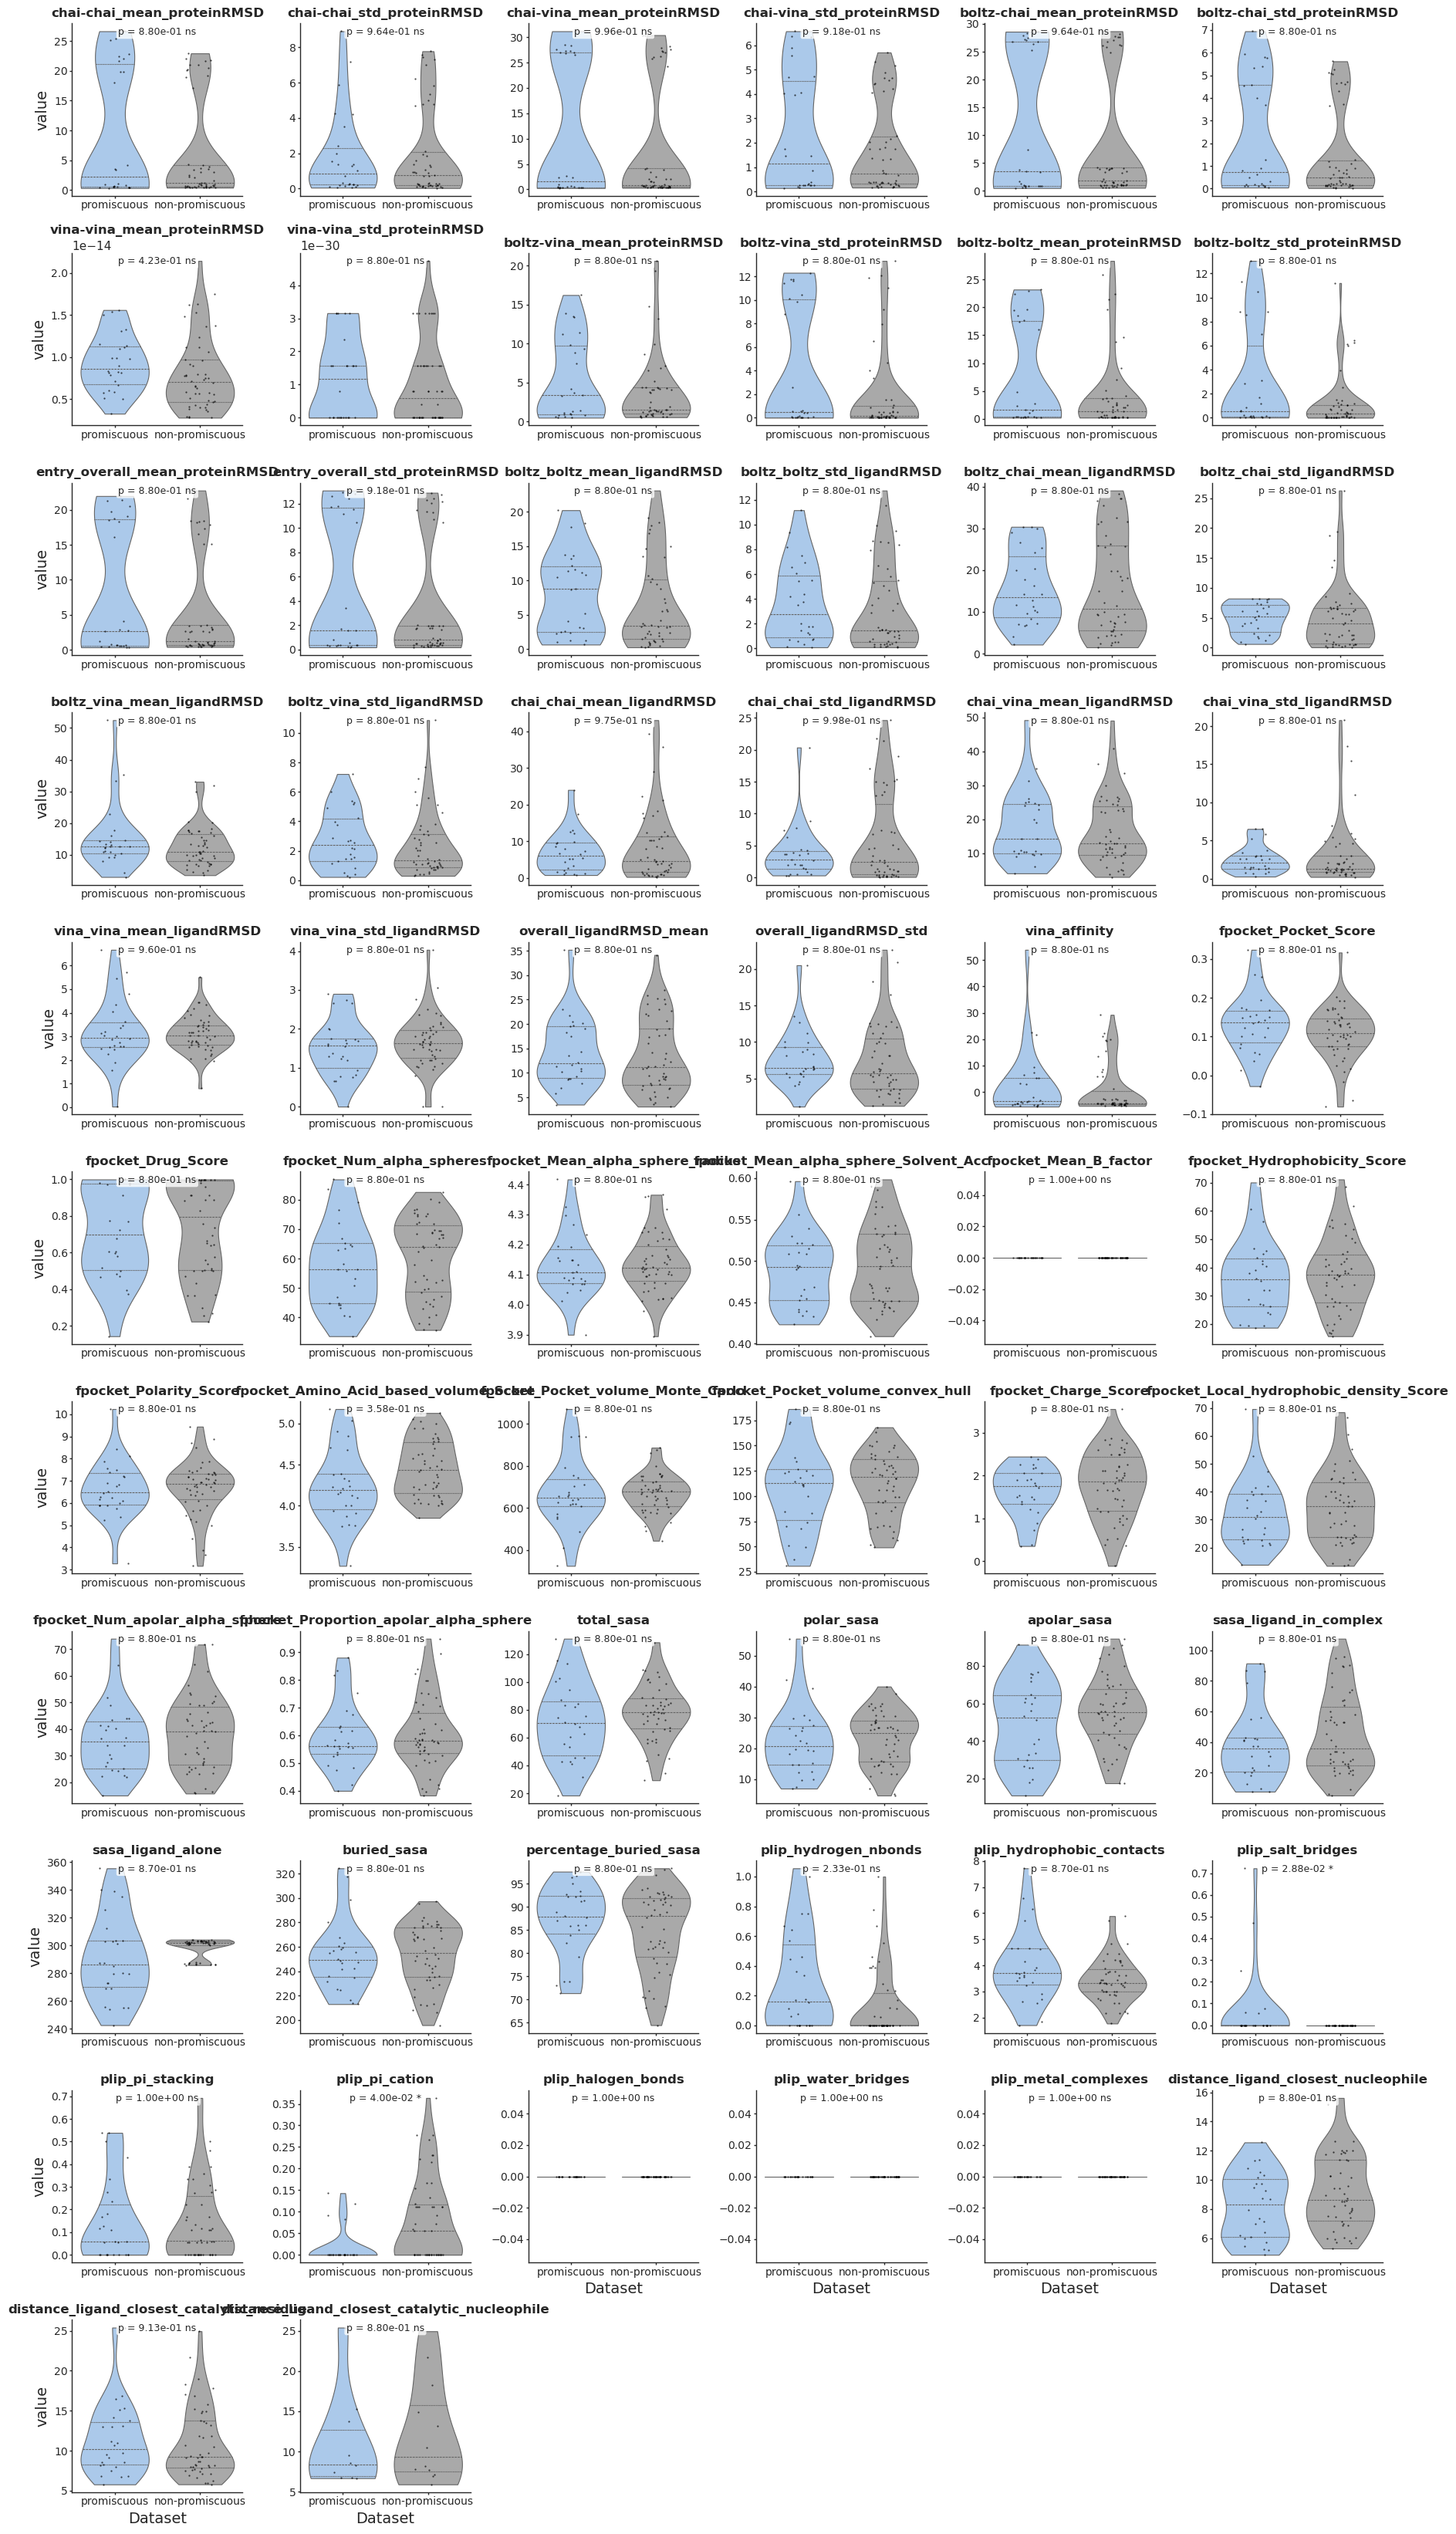

                                  feature   p_value
53                      plip_salt_bridges  0.028792
55                         plip_pi_cation  0.040005
51                   plip_hydrogen_nbonds  0.232920
37  fpocket_Amino_Acid_based_volume_Score  0.357922
6              vina-vina_mean_proteinRMSD  0.423113


In [28]:
missing_columns = ['boltz2_affinity_pred_value', 'boltz2_affinity_probability_binary', 'boltz2_affinity_pred_value1', 'boltz2_affinity_probability_binary1', 'boltz2_affinity_pred_value2', 'boltz2_affinity_probability_binary2', 
                   'boltz2_chains_ptm', 'boltz2_pair_chains_iptm', 'chai_aggregate_score', 'chai_ptm', 'chai_iptm', 'boltz2_confidence_score', 'boltz2_ptm', 'boltz2_iptm', 'boltz2_ligand_iptm', 'boltz2_protein_iptm', 'boltz2_complex_plddt', 'boltz2_complex_iplddt', 'boltz2_complex_pde', 'boltz2_complex_ipde']
s2 = set(missing_columns)        
feature_columns_DEDB = [x for x in feature_columns_DEDB if x not in s2]


pvals_df = violin_all_vs_activity_with_p(
    DEDB_avg_all,
    feature_columns_martinez,
    label_col="Dataset",
    col_wrap=6,
    height=3,
    test="mannwhitney",   # or 'ttest' or 'auto'
    adjust="fdr_bh"       # or None (requires statsmodels to apply)
)
print(pvals_df.head())


/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


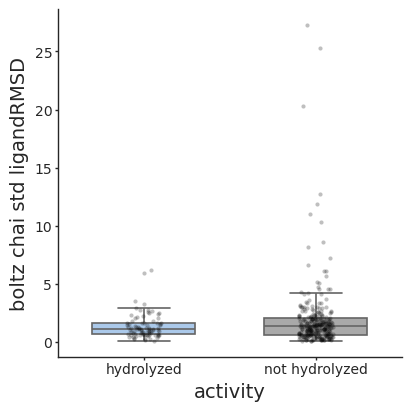

/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


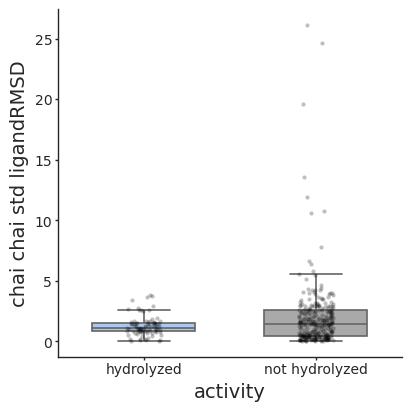

/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


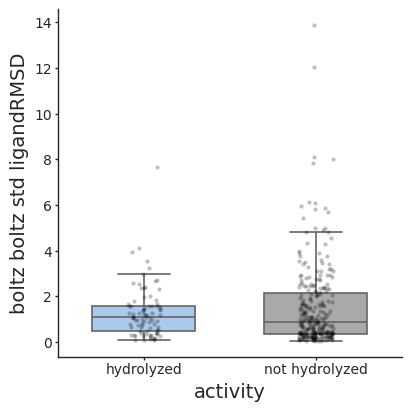

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def boxplot_features(
    df, features, *,
    label_col="activity",
    order=None,                 # None -> infer from data
    logy=False,
    figsize_scale=4,
    palette=None                # None -> auto colors
):
    """
    Box + strip plots for multiple features across classes in `label_col`.
    No statistical testing or p-values.
    """
    # validate features present
    valid = [f for f in features if f in df.columns]
    if not valid:
        raise ValueError("None of the requested features are in the DataFrame.")


    # determine classes and order
    classes = pd.Series(df[label_col]).dropna().unique().tolist()
    if order is None:
        order = sorted(classes) if pd.api.types.is_numeric_dtype(df[label_col]) else classes
    else:
        order = list(order)

    # coerce categorical with explicit order (prevents reindexing issues)
    df = df.copy()
    df[label_col] = pd.Categorical(df[label_col], categories=order, ordered=True)

    # auto palette
    if palette is None:
        n = len(order)
        if n == 2:
            palette = {order[0]: pu.pastel_blue, order[1]: "darkgrey"}
        else:
            pal_list = sns.color_palette("tab20", n_colors=n)
            palette = {cls: pal_list[i] for i, cls in enumerate(order)}

    # layout
    n_feat = len(valid)
    ncols = min(3, max(1, n_feat))
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(figsize_scale*ncols, figsize_scale*nrows),
        constrained_layout=True
    )
    axes = np.atleast_1d(axes).ravel()

    for i, feat in enumerate(valid):
        ax = axes[i]

        # Boxplot: color by x categories using palette (no hue)
        sns.boxplot(
            data=df, x=label_col, y=feat,
            order=order, palette=palette,
            ax=ax, showfliers=False, linewidth=1.2, width=0.6
        )

        # Raw points in black on top
        sns.stripplot(
            data=df, x=label_col, y=feat,
            order=order,
            ax=ax, color="black", alpha=0.25, size=3, jitter=True
        )

        # axes formatting
        ax.set_xlabel(label_col)
        ax.set_ylabel(feat.replace("_", " "))
        if logy:
            ax.set_yscale("log")

        # simple legend with palette key only
        handles = []
        labels = []
        for cls in order:
            h = plt.Line2D([0],[0], marker='s', linestyle='',
                           markerfacecolor=palette.get(cls, "grey"),
                           markeredgecolor='none', markersize=8)
            handles.append(h); labels.append(str(cls))
         #ax.legend(handles, labels, frameon=True, loc="upper right", title="")
        clean_plt(ax, max_label_chars=40)

    # remove any unused axes
    for j in range(len(valid), len(axes)):
        axes[j].remove()

    plt.show()
    return fig

# Average numeric columns per Entry
df_martinez_avg = martinez.groupby("Entry", as_index=False).mean(numeric_only=True)
# Add activity back 
activity_map = martinez.groupby("Entry")["activity"].first()
df_martinez_avg = df_martinez_avg.merge(activity_map, on="Entry", how="left")

fig = boxplot_features(
    df_martinez_avg,
    features=["boltz_chai_std_ligandRMSD"],
    label_col="activity",
    order=("hydrolyzed","not hydrolyzed")
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/boxplot_boltz_chai_std_ligandRMSD_martinez_avg_all.png', dpi=300)

fig = boxplot_features(
    df_martinez_avg,
    features=["chai_chai_std_ligandRMSD"],
    label_col="activity",
    order=("hydrolyzed","not hydrolyzed")
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/boxplot_chai_chai_std_ligandRMSD_martinez_avg_all.png', dpi=300)

fig = boxplot_features(
    df_martinez_avg,
    features=["boltz_boltz_std_ligandRMSD"],
    label_col="activity",
    order=("hydrolyzed","not hydrolyzed")
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/boxplot_boltz_boltz_std_ligandRMSD_martinez_avg_all.png', dpi=300)



/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


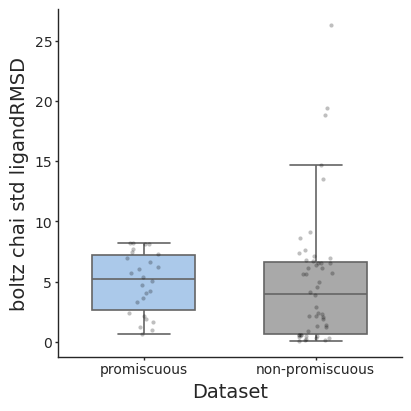

/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


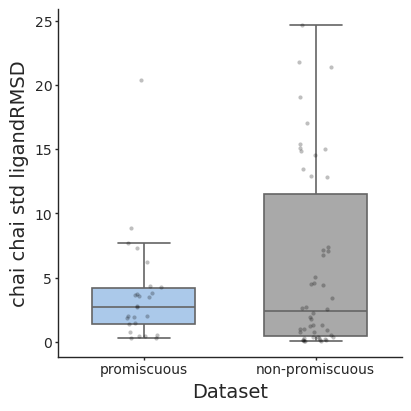

/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


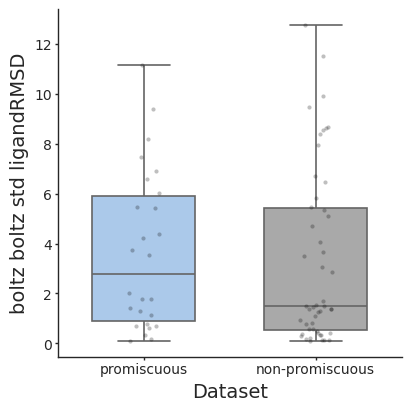

/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


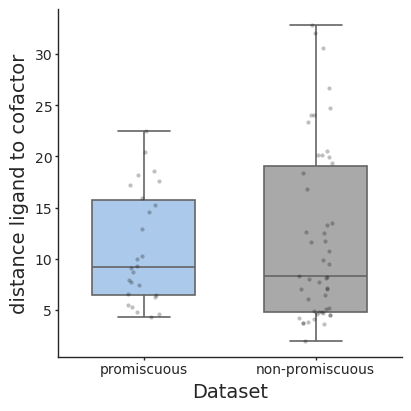

/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


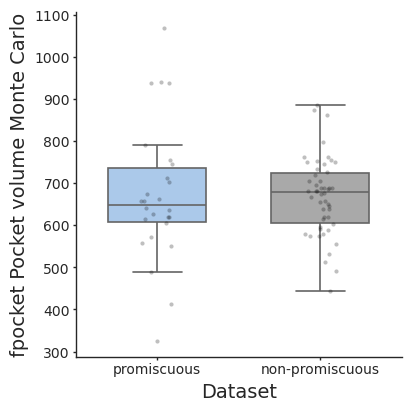

/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


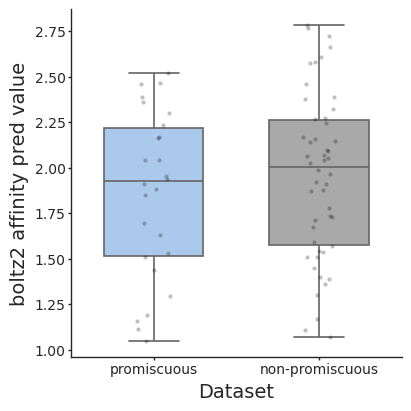

/tmp/ipykernel_1345383/3744876975.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


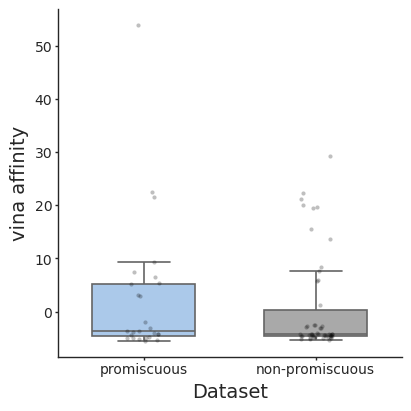

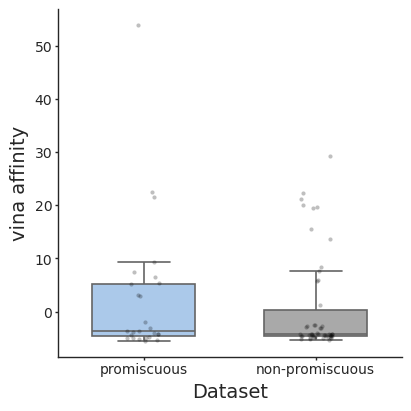

In [ ]:
# Average numeric columns per Entry
DEDB["boltz2_affinity_pred_value"] = pd.to_numeric(
    DEDB["boltz2_affinity_pred_value"], errors="coerce"
)
df_DEDB_avg = DEDB.groupby("Entry", as_index=False).mean(numeric_only=True)
# Add activity back 
activity_map = DEDB.groupby("Entry")["Dataset"].first()
df_DEDB_avg = df_DEDB_avg.merge(activity_map, on="Entry", how="left")

boxplot_features(
    df_DEDB_avg,
    features=["boltz_chai_std_ligandRMSD"],
    label_col="Dataset",
    order=("promiscuous","non-promiscuous")
)

fig = boxplot_features(
    df_DEDB_avg,
    features=["chai_chai_std_ligandRMSD"],
    label_col="Dataset",
    order=("promiscuous","non-promiscuous")
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/boxplot_DEDB_chai_chai_std_ligandRMSD_DEDB_avg_all.png', dpi=300)

fig = boxplot_features(
    df_DEDB_avg,
    features=["boltz_boltz_std_ligandRMSD"],
    label_col="Dataset",
    order=("promiscuous","non-promiscuous")
)

fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/boxplot_DEDB_boltz_boltz_std_ligandRMSD_DEDB_avg_all.png', dpi=300)

fig = boxplot_features(
    df_DEDB_avg,
    features=["distance_ligand_to_cofactor"],
    label_col="Dataset",
    order=("promiscuous","non-promiscuous")
)
fig.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/boxplot_DEDB_distance_ligand_to_cofactor_DEDB_avg_all.png', dpi=300)

boxplot_features(
    df_DEDB_avg,
    features=["fpocket_Pocket_volume_Monte_Carlo"],
    label_col="Dataset",
    order=("promiscuous","non-promiscuous")
)

boxplot_features(
    df_DEDB_avg,
    features=["boltz2_affinity_pred_value"],
    label_col="Dataset",
    order=("promiscuous","non-promiscuous")
)

boxplot_features(
    df_DEDB_avg,
    features=["vina_affinity"],
    label_col="Dataset",
    order=("promiscuous","non-promiscuous")
)


## Predicting most important features

### Random forest

/tmp/ipykernel_1345383/3714415033.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


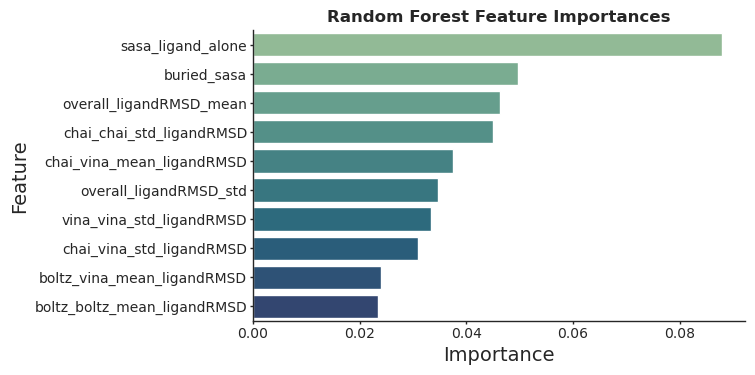

/tmp/ipykernel_1345383/3714415033.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


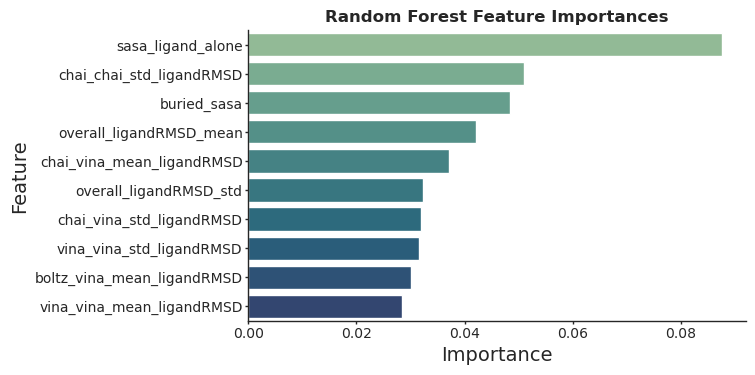

/tmp/ipykernel_1345383/3714415033.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


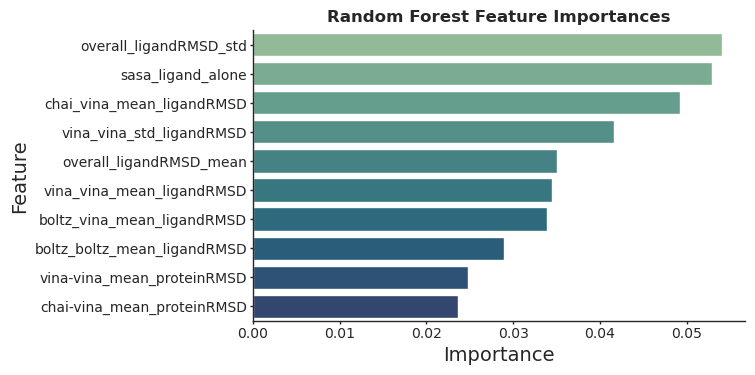

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


def random_forest_feature_importance(
    df,
    label_col="activity",
    feature_cols=None,
    missing_columns = None, 
    test_size=0.2,
    random_state=42,
    top_n=None,
    n_estimators=100,
    ax=None
):
    """
    Trains a Random Forest classifier and plots feature importances.

    Parameters
    ----------
    df : pd.DataFrame
        Input data containing features and label.
    label_col : str
        Name of the binary label column.
    feature_cols : list or None
        Columns to use as features. If None, all numeric columns except label_col are used.
    test_size : float
        Fraction of the dataset used as the test split.
    random_state : int
        Random seed.
    top_n : int or None
        If provided, only the top N most important features are shown.
    n_estimators : int
        Number of trees in the Random Forest.
    ax : matplotlib.axes.Axes or None
        Axes to plot on. If None, a new figure/axes are created.

    Returns
    -------
    feature_importance_df : pd.DataFrame
        DataFrame with columns ['Feature', 'Importance'] sorted descending.
    rf : RandomForestClassifier
        The fitted Random Forest model.
    ax : matplotlib.axes.Axes
        The axes the barplot was drawn on.
    """

    s2 = set(missing_columns)        
    feature_cols = [x for x in feature_cols if x not in s2]

    # 1) Select features
    if feature_cols is None:
        feature_cols = (
            df.select_dtypes(include="number")
              .columns.drop(label_col, errors="ignore")
              .tolist()
        )

    X = df[feature_cols].copy()
    y = df[label_col].copy()

    # 2) Encode labels if needed
    if y.dtype == "object" or y.dtype.name == "category":
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y), index=y.index, name=label_col)

    # 3) Handle missing: drop rows where any selected feature or label is NA
    data = pd.concat([X, y], axis=1).dropna(axis=0, how="any")
    if data.empty:
        raise ValueError("After dropping NA rows, no data remains. Check missing values or impute first.")

    X = data[feature_cols]
    y = data[label_col]

    # 4) Train/test split (stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # 5) Train Random Forest
    rf = RandomForestClassifier(
        random_state=random_state,
        n_estimators=n_estimators,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)

    # 6) Importances
    importances = rf.feature_importances_
    feature_importance_df = (
        pd.DataFrame({"Feature": feature_cols, "Importance": importances})
        .sort_values("Importance", ascending=False)
        .reset_index(drop=True)
    )
    if top_n is not None:
        feature_importance_df = feature_importance_df.head(top_n)

    # 7) Plot on provided ax (or create one)
    created_ax = False
    if ax is None:
        height = max(4, 0.3 * len(feature_importance_df))
        fig, ax = plt.subplots(figsize=(8, height))
        created_ax = True

    sns.barplot(
        data=feature_importance_df,
        y="Feature",
        x="Importance",
        ax=ax, 
        palette='crest'
    )
    ax.set_title("Random Forest Feature Importances")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    ax.figure.tight_layout()
    clean_plt(ax)

    if created_ax:
        plt.show()

    return feature_importance_df, rf, ax

important_features = random_forest_feature_importance(martinez_chai_only, feature_cols= feature_columns_martinez, missing_columns=missing_columns_chai,label_col='activity', top_n=10)
important_features = random_forest_feature_importance(martinez_boltz_only, feature_cols= feature_columns_martinez, missing_columns=missing_columns_boltz,label_col='activity', top_n=10)
important_features = random_forest_feature_importance(martinez_vina_only, feature_cols= feature_columns_martinez, missing_columns=missing_columns_vina,label_col='activity', top_n=10)

/tmp/ipykernel_1345383/3714415033.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


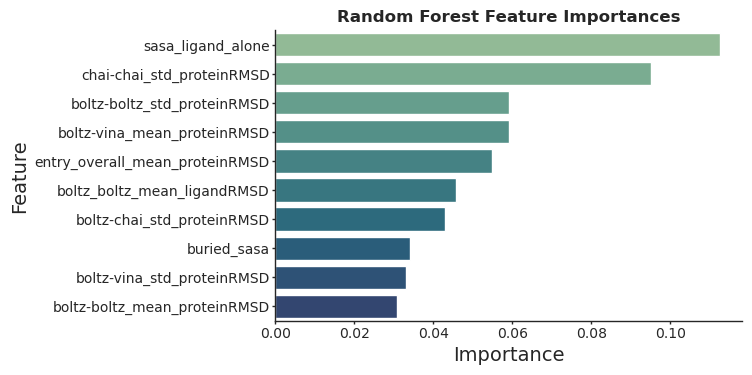

/tmp/ipykernel_1345383/3714415033.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


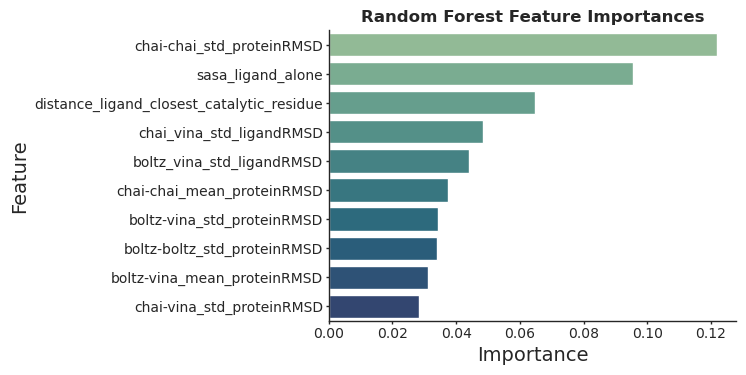

In [ ]:
# DEDB

important_features = random_forest_feature_importance(DEDB_chai_only, feature_cols= feature_columns_DEDB, missing_columns=missing_columns_chai,label_col='Dataset', top_n=10)
important_features = random_forest_feature_importance(DEDB_boltz_only, feature_cols= feature_columns_DEDB, missing_columns=missing_columns_boltz,label_col='Dataset', top_n=10)
#important_features = random_forest_feature_importance(DEDB_vina_only, feature_cols= feature_columns_DEDB, missing_columns=missing_columns_vina,label_col='Dataset', top_n=10)

### XGBoost

/tmp/ipykernel_1345383/840978508.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


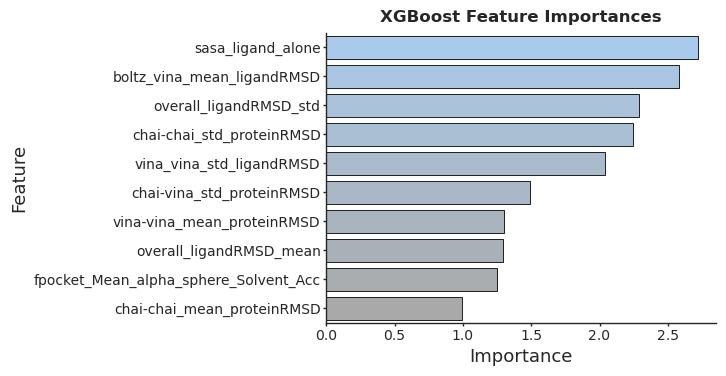

/tmp/ipykernel_1345383/840978508.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


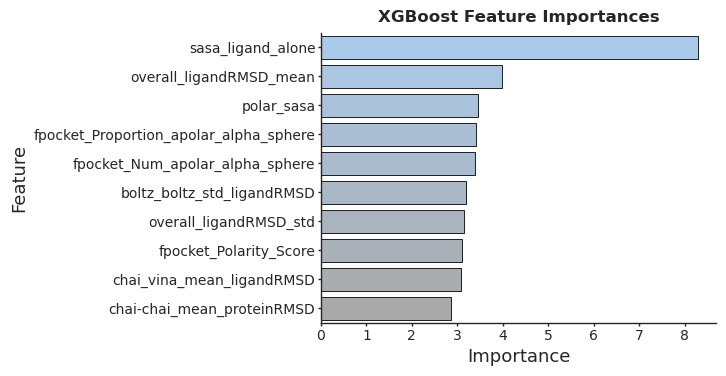

/tmp/ipykernel_1345383/840978508.py:149: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


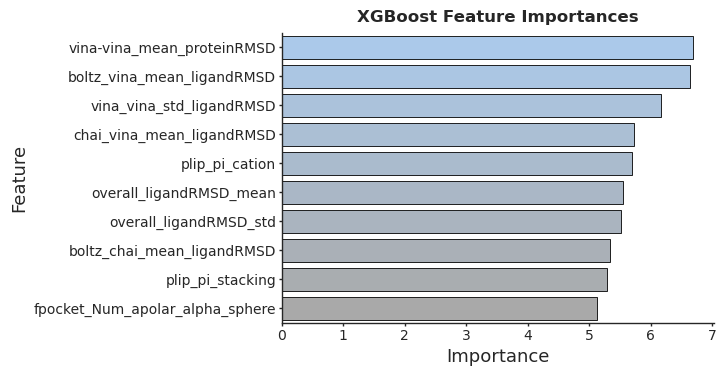

In [ ]:
# pip install xgboost if needed
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def xgb_feature_importance(
    df,
    *,
    label_col="activity",
    feature_cols=None,
    missing_columns=None,
    test_size=0.2,
    random_state=42,
    top_n=None,
    # XGBoost hyperparams (tweak as needed)
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    # Importance settings
    importance_type="gain",   # one of: 'gain','weight','cover','total_gain','total_cover','permutation'
    scoring="roc_auc",        # only used if importance_type='permutation'
    n_repeats=10,             # only used if importance_type='permutation'
    # Plotting
    ax=None,
    palette=None,             # list of colors or None → grey→blue gradient
    title="XGBoost Feature Importances"
):
    """
    Train an XGBoost classifier and plot feature importances.

    Returns
    -------
    feature_importance_df : pd.DataFrame  (columns: Feature, Importance)
    model : XGBClassifier
    ax : matplotlib.axes.Axes
    """

    # --- columns & data prep
    if missing_columns is None:
        missing_columns = []
    s2 = set(missing_columns)
    if feature_cols is None:
        feature_cols = (
            df.select_dtypes(include="number")
              .columns.drop(label_col, errors="ignore")
              .tolist()
        )
    feature_cols = [c for c in feature_cols if c not in s2]

    X = df[feature_cols].copy()
    y = df[label_col].copy()

    # encode labels if needed
    if y.dtype == "object" or y.dtype.name == "category":
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y), index=y.index, name=label_col)

    # drop rows with NA
    data = pd.concat([X, y], axis=1).dropna(axis=0, how="any")
    if data.empty:
        raise ValueError("After dropping NA rows, no data remains. Check missing values or impute first.")
    X = data[feature_cols].to_numpy(dtype=float)
    y = data[label_col].to_numpy()

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    # --- model
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=random_state,
        tree_method="hist"  # fast default
    )
    model.fit(X_train, y_train)

    # --- importance
    if importance_type.lower() == "permutation":
        pi = permutation_importance(
            model, X_test, y_test,
            scoring=scoring, n_repeats=n_repeats,
            random_state=random_state, n_jobs=-1
        )
        importances = pi.importances_mean
        fi_df = (
            pd.DataFrame({"Feature": feature_cols, "Importance": importances})
            .sort_values("Importance", ascending=False)
            .reset_index(drop=True)
        )
    else:
        # XGBoost native importance (gain/weight/cover/total_gain/total_cover)
        booster = model.get_booster()
        raw_score = booster.get_score(importance_type=importance_type)

        # Map keys (may be 'f0','f1',...) to feature names
        # Case 1: keys already equal to feature names
        if set(raw_score.keys()) <= set(feature_cols):
            mapping = raw_score
        else:
            # Case 2: keys like 'f0', 'f1' → map by index order
            mapping = {}
            for i, feat in enumerate(feature_cols):
                key = f"f{i}"
                mapping[feat] = raw_score.get(key, 0.0)

        fi_df = (
            pd.DataFrame({"Feature": list(mapping.keys()), "Importance": list(mapping.values())})
            .sort_values("Importance", ascending=False)
            .reset_index(drop=True)
        )

    if top_n is not None:
        fi_df = fi_df.head(top_n)

    # --- plot
    created_ax = False
    if ax is None:
        height = max(4, 0.35 * len(fi_df))
        fig, ax = plt.subplots(figsize=(7.5, height))
        created_ax = True

    # palette
    if palette is None:
        # discrete gradient grey → blue
        palette = sns.blend_palette([pu.pastel_blue, "darkgrey"], n_colors=len(fi_df))
    elif isinstance(palette, str):
        palette = sns.color_palette(palette, n_colors=len(fi_df))


    sns.barplot(
        data=fi_df,
        y="Feature",
        x="Importance",
        ax=ax,
        palette=palette,
        edgecolor="black",
        linewidth=0.6
    )
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel("Importance", fontsize=13)
    ax.set_ylabel("Feature", fontsize=13)
    ax.tick_params(axis="both", labelsize=10)
    ax.figure.tight_layout()

    # optional clean_plt if you have it
    try:
        pu.clean_plt(ax)
    except Exception:
        pass

    if created_ax:
        plt.show()

    return fi_df, model, ax


fig_chai, xgb_chai, ax1 = xgb_feature_importance(
    DEDB_chai_only,
    feature_cols=feature_columns_martinez,
    missing_columns=missing_columns_chai,
    label_col="dataset",
    top_n=10,
    importance_type="gain",  # try 'permutation' if you prefer model-agnostic
    title="XGBoost Feature Importances"
)

ax1.figure.savefig('/nvme2/helen/masterthesis/3_manuscript/figures/XGBoost_DEDB_chai_only_feature_importances.png', dpi=300)

fi_boltz, xgb_boltz, ax2 = xgb_feature_importance(
    martinez_boltz_only,
    feature_cols=feature_columns_martinez,
    missing_columns=missing_columns_boltz,
    label_col="activity",
    top_n=10,
    importance_type="gain",
    title="XGBoost Feature Importances"
)

fi_vina, xgb_vina, ax3 = xgb_feature_importance(
    martinez_vina_only,
    feature_cols=feature_columns_martinez,
    missing_columns=missing_columns_vina,
    label_col="activity",
    top_n=10,
    importance_type="gain",
    title="XGBoost Feature Importances"
)


### Decision tree

/tmp/ipykernel_1345383/3469052103.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, y="Feature", x="Importance", palette="mako")


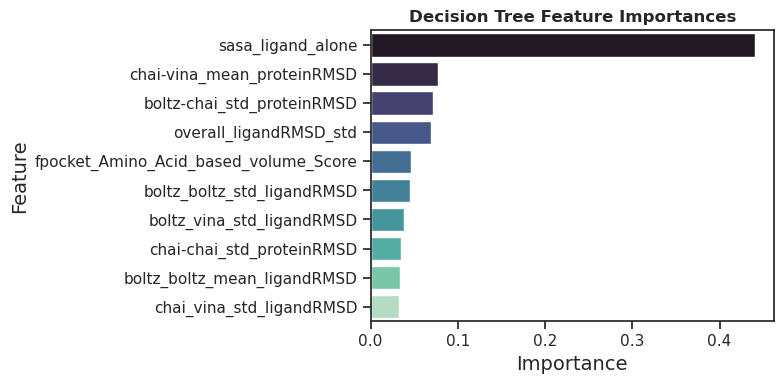

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def decision_tree_feature_importance(
    df, label_col="activity", feature_cols=None, missing_columns = None, test_size=0.2, random_state=42,
    top_n=None, max_depth=None, class_weight=None
):
    """
    Trains a Decision Tree classifier and plots feature importances.
    Mirrors your RF helper: no data coercion; only label encoding if needed.
    """

    s2 = set(missing_columns)        
    feature_cols = [x for x in feature_cols if x not in s2]

    X = df[feature_cols].copy()
    y = df[label_col].copy()

    # Encode labels if not numeric
    if y.dtype == "object" or y.dtype.name == "category":
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y), index=y.index, name=label_col)

    # Drop rows with NA in features or label
    data = pd.concat([X, y], axis=1).dropna()
    X = data[feature_cols]
    y = data[label_col]

    # Train/test split (fallback if stratify not feasible)
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=None
        )

    # Train Decision Tree
    dt = DecisionTreeClassifier(
        random_state=random_state, max_depth=max_depth, class_weight=class_weight
    )
    dt.fit(X_train, y_train)

    # Importances
    importances = dt.feature_importances_
    feature_importance_df = (
        pd.DataFrame({"Feature": feature_cols, "Importance": importances})
        .sort_values("Importance", ascending=False)
    )

    if top_n is not None:
        feature_importance_df = feature_importance_df.head(top_n)

    # Plot
    plt.figure(figsize=(8, max(4, 0.3 * len(feature_importance_df))))
    sns.barplot(data=feature_importance_df, y="Feature", x="Importance", palette="mako")
    plt.title("Decision Tree Feature Importances")
    plt.tight_layout()
    plt.show()

    return feature_importance_df



imp_dt = decision_tree_feature_importance(
    martinez_chai_only, label_col="activity", feature_cols=feature_columns_martinez, missing_columns=missing_columns_chai, top_n=10
)

/tmp/ipykernel_1345383/3469052103.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, y="Feature", x="Importance", palette="mako")


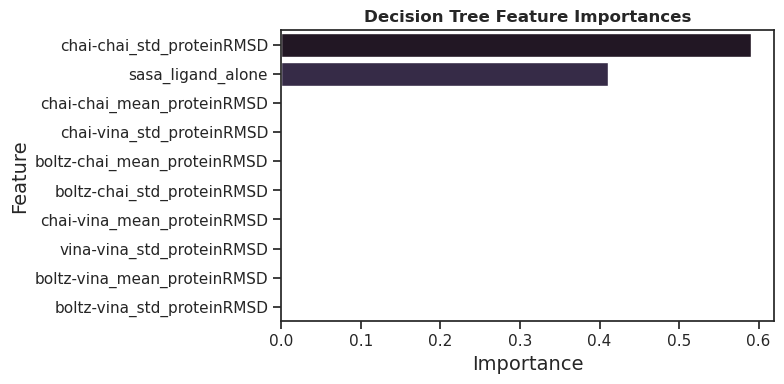

/tmp/ipykernel_1345383/3469052103.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, y="Feature", x="Importance", palette="mako")


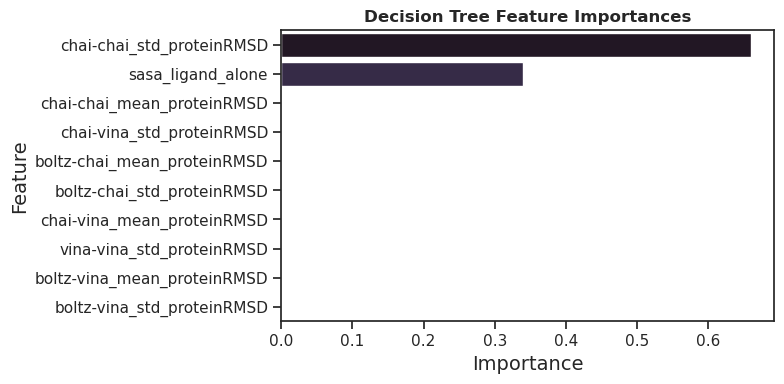

In [ ]:
imp_dt = decision_tree_feature_importance(
    DEDB_chai_only, label_col="Dataset", feature_cols=feature_columns_DEDB, missing_columns=missing_columns_chai, top_n=10
)

imp_dt = decision_tree_feature_importance(
    DEDB_boltz_only, label_col="Dataset", feature_cols=feature_columns_DEDB, missing_columns=missing_columns_boltz, top_n=10
)

### Logistic regression

/home/helen/miniconda3/envs/promiscuity/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


/home/helen/miniconda3/envs/promiscuity/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/tmp/ipykernel_1345383/3549932298.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, y="Feature", x="Importance", palette="crest")


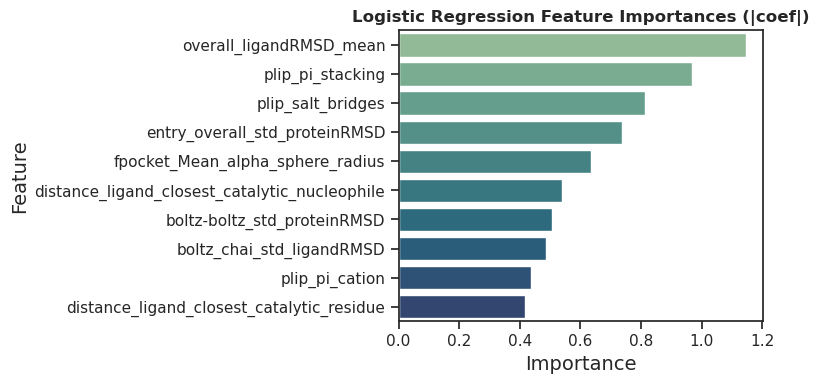

/home/helen/miniconda3/envs/promiscuity/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/tmp/ipykernel_1345383/3549932298.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, y="Feature", x="Importance", palette="crest")


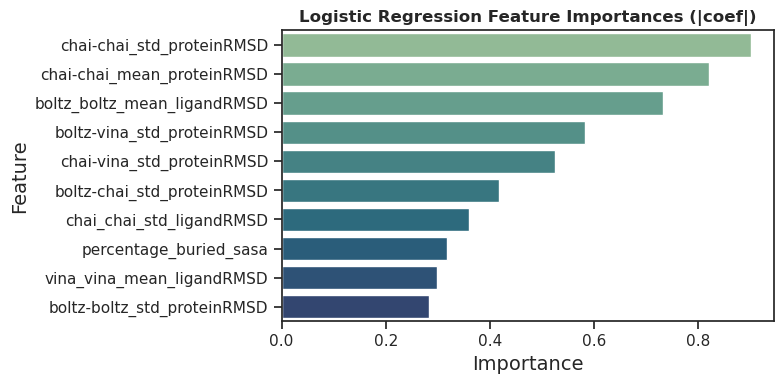

In [ ]:

def logistic_regression_feature_importance(
    df, label_col="activity", feature_cols=None, missing_columns = None, test_size=0.2, random_state=42,
    top_n=None, penalty="l2", C=1.0, max_iter=2000, class_weight=None
):
    """
    Trains a Logistic Regression classifier and plots coefficient magnitudes as importances.
    Mirrors your RF helper: no data coercion; only label encoding if needed.
    Note: LR can benefit from scaling, but we keep it off to stay consistent with your RF helper.
    """
    # Select features
    s2 = set(missing_columns)        
    feature_cols = [x for x in feature_cols if x not in s2]

    X = df[feature_cols].copy()
    y = df[label_col].copy()

    # Encode labels if not numeric
    if y.dtype == "object" or y.dtype.name == "category":
        le = LabelEncoder()
        y = pd.Series(le.fit_transform(y), index=y.index, name=label_col)

    # Drop rows with NA in features or label
    data = pd.concat([X, y], axis=1).dropna()
    X = data[feature_cols]
    y = data[label_col]

    # Train/test split (fallback if stratify not feasible)
    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
    except ValueError:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=None
        )

    # Train Logistic Regression
    lr = LogisticRegression(
        penalty=penalty, C=C, max_iter=max_iter, solver="lbfgs",
        multi_class="auto", class_weight=class_weight
    )
    lr.fit(X_train, y_train)

    # Importances = |coefficients| (avg over classes if multiclass)
    coef = lr.coef_  # (n_classes, n_features) or (1, n_features)
    if coef.ndim == 1:
        coef = coef.reshape(1, -1)
    imp_vals = np.mean(np.abs(coef), axis=0)

    feature_importance_df = (
        pd.DataFrame({"Feature": feature_cols, "Importance": imp_vals})
        .sort_values("Importance", ascending=False)
    )

    if top_n is not None:
        feature_importance_df = feature_importance_df.head(top_n)

    # Plot
    plt.figure(figsize=(8, max(4, 0.3 * len(feature_importance_df))))
    sns.barplot(data=feature_importance_df, y="Feature", x="Importance", palette="crest")
    plt.title("Logistic Regression Feature Importances (|coef|)")
    plt.tight_layout()
    plt.show()

    return feature_importance_df

# martinez
imp_lr = logistic_regression_feature_importance(
    martinez_chai_only, label_col="activity", feature_cols=feature_columns_martinez, missing_columns = missing_columns_chai, top_n=10
)

# DEDB
imp_lr = logistic_regression_feature_importance(
    DEDB_chai_only, label_col="Dataset", feature_cols=feature_columns_DEDB, missing_columns = missing_columns_chai, top_n=10
)


## Train binary classification with XGBoost for martinez

In [ ]:
feature_columns= [
'chai-chai_mean_proteinRMSD',
'chai-chai_std_proteinRMSD',
'chai-vina_mean_proteinRMSD',
'chai-vina_std_proteinRMSD',
'boltz-chai_mean_proteinRMSD',
'boltz-chai_std_proteinRMSD',
'vina-vina_mean_proteinRMSD',
'vina-vina_std_proteinRMSD',
'boltz-vina_mean_proteinRMSD',
'boltz-vina_std_proteinRMSD',
'boltz-boltz_mean_proteinRMSD',
'boltz-boltz_std_proteinRMSD',
'entry_overall_mean_proteinRMSD',
'entry_overall_std_proteinRMSD',
'chai_aggregate_score',
'chai_ptm',
'chai_iptm',
'boltz2_confidence_score',
'boltz2_ptm',
'boltz2_iptm',
'boltz2_ligand_iptm',
'boltz2_protein_iptm',
'boltz2_complex_plddt',
'boltz2_complex_iplddt',
'boltz2_complex_pde',
'boltz2_complex_ipde',
'boltz2_affinity_pred_value',
'boltz2_affinity_probability_binary',
'boltz2_affinity_pred_value1',
'boltz2_affinity_probability_binary1',
'boltz2_affinity_pred_value2',
'boltz2_affinity_probability_binary2',
'boltz_boltz_mean_ligandRMSD',
'boltz_boltz_std_ligandRMSD',
'boltz_chai_mean_ligandRMSD',
'boltz_chai_std_ligandRMSD',
'boltz_vina_mean_ligandRMSD',
'boltz_vina_std_ligandRMSD',
'chai_chai_mean_ligandRMSD',
'chai_chai_std_ligandRMSD',
'chai_vina_mean_ligandRMSD',
'chai_vina_std_ligandRMSD',
'vina_vina_mean_ligandRMSD',
'vina_vina_std_ligandRMSD',
'overall_ligandRMSD_mean',
'overall_ligandRMSD_std',
'vina_affinity',
'fpocket_Pocket_Score',
'fpocket_Drug_Score',
'fpocket_Num_alpha_spheres',
'fpocket_Mean_alpha_sphere_radius',
'fpocket_Mean_alpha_sphere_Solvent_Acc',
'fpocket_Mean_B_factor',
'fpocket_Hydrophobicity_Score',
'fpocket_Polarity_Score',
'fpocket_Amino_Acid_based_volume_Score',
'fpocket_Pocket_volume_Monte_Carlo',
'fpocket_Pocket_volume_convex_hull',
'fpocket_Charge_Score',
'fpocket_Local_hydrophobic_density_Score',
'fpocket_Num_apolar_alpha_sphere',
'fpocket_Proportion_apolar_alpha_sphere',
'total_sasa',
'polar_sasa',
'apolar_sasa',
'sasa_ligand_in_complex',
'sasa_ligand_alone',
'buried_sasa',
'percentage_buried_sasa',
'plip_hydrogen_nbonds',
'plip_hydrophobic_contacts',
'plip_salt_bridges',
'plip_pi_stacking',
'plip_pi_cation',
'plip_halogen_bonds',
'plip_water_bridges',
'plip_metal_complexes',
'distance_ligand_closest_nucleophile',
'distance_ligand_closest_catalytic_residue',
'distance_ligand_closest_catalytic_nucleophile',
#'distance_cofactor_closest_catalytic_residues',
#'distance_ligand_to_cofactor',
]


In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report

# ========= 0) DATA PREP =========
df = martinez.copy()

# labels (binary)
LABEL_MAP = {"hydrolyzed": 1, "not hydrolyzed": 0}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}
df["label_bin"] = df["activity"].map(LABEL_MAP).astype(int)

# normalize group IDs
for col in ["UniprotID", "substrate_name"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# features
X = df[feature_columns].copy()
y = df["label_bin"].copy()

# coerce object feature columns to numeric (common culprit)
for c in X.columns:
    if X[c].dtype == "object":
        X[c] = pd.to_numeric(X[c], errors="coerce")

# ==================
def make_model(y_train):
    # handle imbalance
    pos = int((y_train == 1).sum())
    neg = int((y_train == 0).sum())
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        tree_method="hist",
    )

def fold_metrics(y_true, proba, pred):
    out = {}
    uniq = np.unique(y_true)
    out["n"] = len(y_true)
    out["pos_rate"] = float((y_true==1).mean()) if len(y_true) else np.nan
    out["acc"] = accuracy_score(y_true, pred) if len(y_true) else np.nan
    out["f1"] = f1_score(y_true, pred, zero_division=0) if len(y_true) else np.nan
    if len(uniq) == 2:
        out["roc_auc"] = roc_auc_score(y_true, proba)
    else:
        out["roc_auc"] = np.nan  # undefined with single-class fold
    return out

def summarize(scores):
    if not scores:
        return {}
    keys = scores[0].keys()
    return {k: (np.nanmean([s[k] for s in scores]), np.nanstd([s[k] for s in scores])) for k in keys}

# ========= 2) GROUPK-FOLD: UNSEEN PROTEINS =========
def cv_unseen_proteins(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []
    for fold, (tr, va) in enumerate(gkf.split(X, y, groups=groups), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]
        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)
        sc = fold_metrics(y_va, proba, pred)
        sc["fold"] = fold
        fold_scores.append(sc)
        print(f"[Proteins CV] Fold {fold}: n={sc['n']}, pos_rate={sc['pos_rate']:.3f}, "
              f"acc={sc['acc']:.3f}, f1={sc['f1']:.3f}, roc_auc={sc['roc_auc'] if not np.isnan(sc['roc_auc']) else 'NA'}")
    print("== Protein-wise CV Summary (mean ± sd) ==")
    summ = summarize(fold_scores)
    for k,(m,s) in summ.items():
        if k=="fold": continue
        print(f"{k}: {m:.3f} ± {s:.3f}")
    return fold_scores

# ========= 3) GROUPK-FOLD: UNSEEN SUBSTRATES =========
def cv_unseen_substrates(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []
    for fold, (tr, va) in enumerate(gkf.split(X, y, groups=groups), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]
        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)
        sc = fold_metrics(y_va, proba, pred)
        sc["fold"] = fold
        fold_scores.append(sc)
        print(f"[Substrates CV] Fold {fold}: n={sc['n']}, pos_rate={sc['pos_rate']:.3f}, "
              f"acc={sc['acc']:.3f}, f1={sc['f1']:.3f}, roc_auc={sc['roc_auc'] if not np.isnan(sc['roc_auc']) else 'NA'}")
    print("== Substrate-wise CV Summary (mean ± sd) ==")
    summ = summarize(fold_scores)
    for k,(m,s) in summ.items():
        if k=="fold": continue
        print(f"{k}: {m:.3f} ± {s:.3f}")
    return fold_scores

# ========= 4) DOUBLE-BLOCKED CV (UNSEEN PROTEINS & SUBSTRATES) =========
def cv_double_blocked(X, y, proteins, substrates, K=5, strict=True, random_state=42):
    """
    Train folds exclude prot_block U subs_block.
    Validation:
      - strict=True : rows with (protein in prot_block) AND (substrate in subs_block)
      - strict=False: rows with (protein in prot_block) OR  (substrate in subs_block)
    """
    rng = np.random.default_rng(random_state)
    uniq_p = np.array(pd.unique(proteins))
    uniq_s = np.array(pd.unique(substrates))
    rng.shuffle(uniq_p)
    rng.shuffle(uniq_s)
    prot_blocks = np.array_split(uniq_p, K)
    subs_blocks = np.array_split(uniq_s, K)

    fold_scores = []
    for k in range(K):
        prot_block = set(prot_blocks[k])
        subs_block = set(subs_blocks[k])

        train_mask = (~proteins.isin(prot_block)) & (~substrates.isin(subs_block))
        if strict:
            valid_mask = (proteins.isin(prot_block)) & (substrates.isin(subs_block))
        else:
            valid_mask = (proteins.isin(prot_block)) | (substrates.isin(subs_block))

        X_tr, y_tr = X.loc[train_mask], y.loc[train_mask]
        X_va, y_va = X.loc[valid_mask], y.loc[valid_mask]

        if len(y_va) == 0 or len(y_tr) == 0:
            print(f"[Double CV] Fold {k+1}: skipped (empty train/valid)")
            continue

        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)
        sc = fold_metrics(y_va, proba, pred)
        sc["fold"] = k+1
        fold_scores.append(sc)
        print(f"[Double CV {'STRICT' if strict else 'RELAX'}] Fold {k+1}: n={sc['n']}, pos_rate={sc['pos_rate']:.3f}, "
              f"acc={sc['acc']:.3f}, f1={sc['f1']:.3f}, roc_auc={sc['roc_auc'] if not np.isnan(sc['roc_auc']) else 'NA'}")

    print(f"== Double-blocked CV ({'STRICT' if strict else 'RELAXED'}) Summary (mean ± sd) ==")
    summ = summarize(fold_scores)
    for k,(m,s) in summ.items():
        if k=="fold": continue
        print(f"{k}: {m:.3f} ± {s:.3f}")
    return fold_scores

# ========= 5) RUN ALL THREE =========
print("\n>>> Unseen PROTEINS (GroupKFold by UniprotID)")
prot_scores = cv_unseen_proteins(X, y, groups=df["UniprotID"], n_splits=5)

print("\n>>> Unseen SUBSTRATES (GroupKFold by substrate_name)")
subs_scores = cv_unseen_substrates(X, y, groups=df["substrate_name"], n_splits=5)

print("\n>>> Double-blocked CV (STRICT: both unseen in validation rows)")
dbl_strict_scores = cv_double_blocked(
    X, y,
    proteins=df["UniprotID"], substrates=df["substrate_name"],
    K=5, strict=True, random_state=42
)

print("\n>>> Double-blocked CV (RELAXED: either unseen; training still excludes both blocks)")
dbl_relax_scores = cv_double_blocked(
    X, y,
    proteins=df["UniprotID"], substrates=df["substrate_name"],
    K=5, strict=False, random_state=42
)



>>> Unseen PROTEINS (GroupKFold by UniprotID)
[Proteins CV] Fold 1: n=968, pos_rate=0.186, acc=0.892, f1=0.756, roc_auc=0.959278059785674
[Proteins CV] Fold 2: n=1065, pos_rate=0.157, acc=0.881, f1=0.545, roc_auc=0.8912820239254231
[Proteins CV] Fold 3: n=967, pos_rate=0.193, acc=0.848, f1=0.576, roc_auc=0.7919717537364597
[Proteins CV] Fold 4: n=1075, pos_rate=0.350, acc=0.784, f1=0.566, roc_auc=0.7548283261802575
[Proteins CV] Fold 5: n=966, pos_rate=0.214, acc=0.898, f1=0.754, roc_auc=0.9064304035948648
== Protein-wise CV Summary (mean ± sd) ==
n: 1008.200 ± 50.562
pos_rate: 0.220 ± 0.067
acc: 0.860 ± 0.042
f1: 0.639 ± 0.095
roc_auc: 0.861 ± 0.076

>>> Unseen SUBSTRATES (GroupKFold by substrate_name)
[Substrates CV] Fold 1: n=1037, pos_rate=0.168, acc=0.838, f1=0.152, roc_auc=0.7726455428137613
[Substrates CV] Fold 2: n=1022, pos_rate=0.094, acc=0.875, f1=0.471, roc_auc=0.9126619870410366
[Substrates CV] Fold 3: n=1006, pos_rate=0.451, acc=0.631, f1=0.403, roc_auc=0.635973312903019

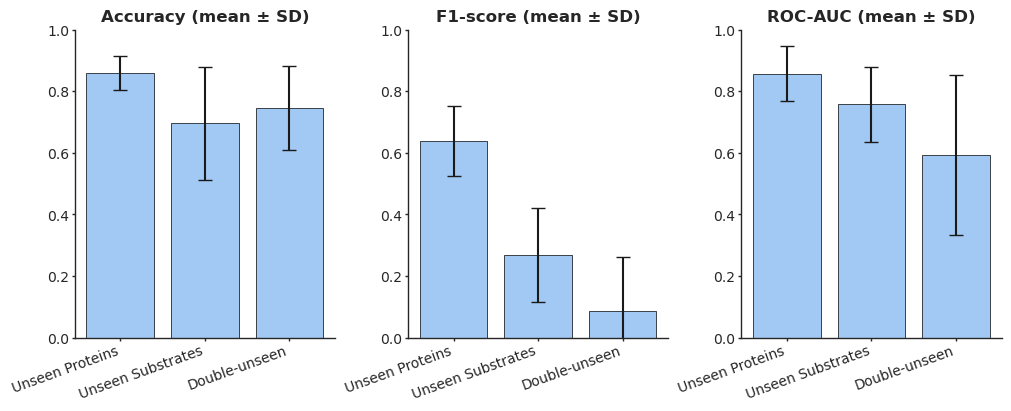

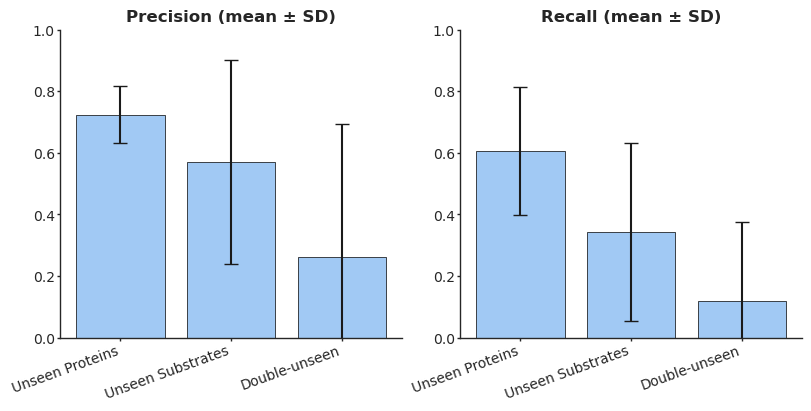

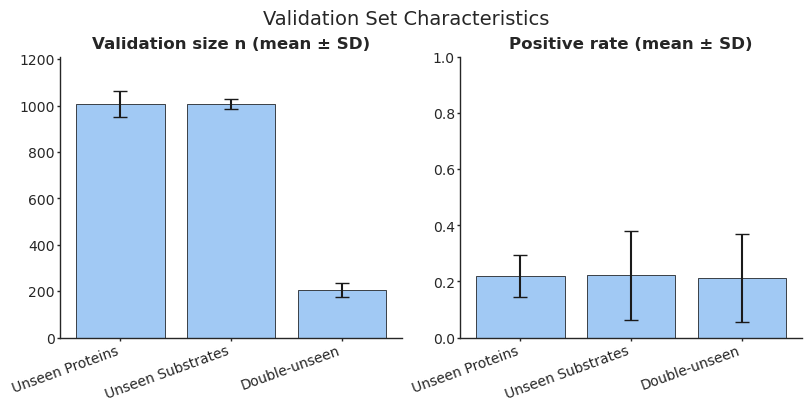


=== Validation Summary Across Modes (mean ± sd) ===
                mode  folds_used  folds_with_auc   n_mean   n_sd  \
0    Unseen Proteins           5               5 1008.200 56.531   
1  Unseen Substrates           5               5 1008.200 21.452   
2      Double-unseen           5               5  204.200 30.793   

   pos_rate_mean  pos_rate_sd  acc_mean  acc_sd  f1_mean  f1_sd  \
0          0.220        0.075     0.859   0.056    0.639  0.114   
1          0.222        0.158     0.696   0.183    0.268  0.153   
2          0.212        0.158     0.745   0.137    0.085  0.176   

   precision_mean  precision_sd  recall_mean  recall_sd  roc_auc_mean  \
0           0.724         0.093        0.605      0.208         0.856   
1           0.570         0.330        0.343      0.289         0.757   
2           0.261         0.434        0.118      0.257         0.592   

   roc_auc_sd  
0       0.089  
1       0.121  
2       0.260  


In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)

df = martinez.copy()

LABEL_MAP = {"hydrolyzed": 1, "not hydrolyzed": 0}
df["label_bin"] = df["activity"].map(LABEL_MAP).astype(int)

# normalize group IDs
for col in ["UniprotID", "substrate_name"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

X = df[feature_columns].copy()
y = df["label_bin"].copy()

# coerce features to numeric
for c in X.columns:
    if X[c].dtype == "object":
        X[c] = pd.to_numeric(X[c], errors="coerce")


def make_model(y_train):
    pos = int((y_train == 1).sum())
    neg = int((y_train == 0).sum())
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        tree_method="hist",
    )

def fold_metrics(y_true, proba, pred):
    uniq = np.unique(y_true)
    m = {
        "n": len(y_true),
        "pos_rate": float((y_true == 1).mean()) if len(y_true) else np.nan,
        "acc": accuracy_score(y_true, pred) if len(y_true) else np.nan,
        "f1": f1_score(y_true, pred, zero_division=0) if len(y_true) else np.nan,
        "precision": precision_score(y_true, pred, zero_division=0) if len(y_true) else np.nan,  # NEW
        "recall":    recall_score(y_true, pred, zero_division=0)    if len(y_true) else np.nan,  # NEW
        "roc_auc": roc_auc_score(y_true, proba) if len(uniq) == 2 else np.nan,
    }
    return m

def summarize_scores(fold_scores):
    if not fold_scores:
        return {}
    df_sc = pd.DataFrame(fold_scores)
    return {
        "n_mean": df_sc["n"].mean(),
        "n_sd":   df_sc["n"].std(ddof=1),
        "pos_rate_mean": df_sc["pos_rate"].mean(),
        "pos_rate_sd":   df_sc["pos_rate"].std(ddof=1),
        "acc_mean": df_sc["acc"].mean(),
        "acc_sd":   df_sc["acc"].std(ddof=1),
        "f1_mean":  df_sc["f1"].mean(),
        "f1_sd":    df_sc["f1"].std(ddof=1),
        "precision_mean": df_sc["precision"].mean(),          # NEW
        "precision_sd":   df_sc["precision"].std(ddof=1),     # NEW
        "recall_mean":    df_sc["recall"].mean(),             # NEW
        "recall_sd":      df_sc["recall"].std(ddof=1),        # NEW
        "roc_auc_mean": np.nanmean(df_sc["roc_auc"].values),
        "roc_auc_sd":   np.nanstd(df_sc["roc_auc"].values, ddof=1),
        "folds_used":   int(len(df_sc)),
        "folds_with_auc": int(np.isfinite(df_sc["roc_auc"]).sum()),
    }

# cross validation types
def cv_unseen_proteins(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []
    for tr, va in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]
        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)
        fold_scores.append(fold_metrics(y_va, proba, pred))
    return summarize_scores(fold_scores)

def cv_unseen_substrates(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []
    for tr, va in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]
        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)
        fold_scores.append(fold_metrics(y_va, proba, pred))
    return summarize_scores(fold_scores)

def cv_double_blocked(X, y, proteins, substrates, K=5, strict=True, random_state=42):
    rng = np.random.default_rng(random_state)
    uniq_p = np.array(pd.unique(proteins))
    uniq_s = np.array(pd.unique(substrates))
    rng.shuffle(uniq_p)
    rng.shuffle(uniq_s)
    prot_blocks = np.array_split(uniq_p, K)
    subs_blocks = np.array_split(uniq_s, K)

    fold_scores = []
    for k in range(K):
        prot_block = set(prot_blocks[k])
        subs_block = set(subs_blocks[k])

        train_mask = (~proteins.isin(prot_block)) & (~substrates.isin(subs_block))
        valid_mask = (proteins.isin(prot_block)) & (substrates.isin(subs_block)) if strict \
                     else (proteins.isin(prot_block)) |  (substrates.isin(subs_block))

        X_tr, y_tr = X.loc[train_mask], y.loc[train_mask]
        X_va, y_va = X.loc[valid_mask], y.loc[valid_mask]

        # skip empty or degenerate folds
        if len(y_va) == 0 or len(y_tr) == 0:
            continue

        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)
        fold_scores.append(fold_metrics(y_va, proba, pred))

    return summarize_scores(fold_scores)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importances(fi_df, title="Feature Importances", top_n=20):
    """
    Plot barplot of feature importances (mean across folds with error bars).
    fi_df must have columns ["Feature","mean","std"].
    """
    if fi_df.empty:
        print("No feature importances to plot.")
        return

    # restrict to top_n if desired
    plot_df = fi_df.head(top_n).copy()

    # dynamic figure height (0.3 per feature, min 4)
    height = max(4, 0.3 * len(plot_df))
    plt.figure(figsize=(8, height))

    sns.barplot(
        data=plot_df,
        y="Feature",
        x="mean",
        palette="crest",
        xerr=plot_df["std"], 
        edgecolor="black",   # <- black outline
        linewidth=0.8,   # error bars = std across folds
    )

    plt.title(title)
    plt.xlabel("Importance (mean across folds)")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


results = []

prot_summary = cv_unseen_proteins(X, y, groups=df["UniprotID"], n_splits=5)
results.append({"mode": "Unseen Proteins", **prot_summary})

subs_summary = cv_unseen_substrates(X, y, groups=df["substrate_name"], n_splits=5)
results.append({"mode": "Unseen Substrates", **subs_summary})

dbl_strict = cv_double_blocked(
    X, y, proteins=df["UniprotID"], substrates=df["substrate_name"],
    K=5, strict=True, random_state=42
)
results.append({"mode": "Double-unseen", **dbl_strict})   # <-- renamed

# summary statics df
summary_df = pd.DataFrame(results, columns=[
    "mode",
    "folds_used", "folds_with_auc",
    "n_mean", "n_sd",
    "pos_rate_mean", "pos_rate_sd",
    "acc_mean", "acc_sd",
    "f1_mean", "f1_sd",
    "precision_mean", "precision_sd",   # NEW
    "recall_mean", "recall_sd",         # NEW
    "roc_auc_mean", "roc_auc_sd",
])


# make summary plots
def _bar_with_error(ax, xlabels, means, sds, title, ylim=None):
    x = np.arange(len(xlabels))
    ax.bar(x, means, yerr=sds, capsize=5, color = pu.pastel_blue, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x, xlabels, rotation=20, ha="right")
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(False)


def plot_validation_summaries(summary_df, save_prefix=None):
    dfp = summary_df.copy()
    for col in ["acc_mean","acc_sd","f1_mean","f1_sd","roc_auc_mean","roc_auc_sd",
                "precision_mean","precision_sd","recall_mean","recall_sd",
                "n_mean","n_sd","pos_rate_mean","pos_rate_sd"]:
        if col in dfp.columns:
            dfp[col] = pd.to_numeric(dfp[col], errors="coerce")

    xlabels = dfp["mode"].tolist()

    # Metrics: Accuracy, F1, ROC-AUC
    fig, axes = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True)
    _bar_with_error(axes[0], xlabels, dfp["acc_mean"], dfp["acc_sd"], "Accuracy (mean ± SD)", ylim=(0,1))
    _bar_with_error(axes[1], xlabels, dfp["f1_mean"],  dfp["f1_sd"],  "F1-score (mean ± SD)", ylim=(0,1))
    _bar_with_error(axes[2], xlabels, dfp["roc_auc_mean"], dfp["roc_auc_sd"], "ROC-AUC (mean ± SD)", ylim=(0,1))
    for ax in np.ravel(axes):
        pu.clean_plt(ax)
    if save_prefix:
        fig.savefig(f"{save_prefix}_metrics.png", dpi=150)

    # NEW: Precision & Recall
    fig_pr, axes_pr = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    _bar_with_error(axes_pr[0], xlabels, dfp["precision_mean"], dfp["precision_sd"], "Precision (mean ± SD)", ylim=(0,1))
    _bar_with_error(axes_pr[1], xlabels, dfp["recall_mean"],    dfp["recall_sd"],    "Recall (mean ± SD)",    ylim=(0,1))
    for ax in np.ravel(axes_pr):
        pu.clean_plt(ax)
    if save_prefix:
        fig_pr.savefig(f"{save_prefix}_precision_recall.png", dpi=150)

    # Dataset characteristics
    fig2, axes2 = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    _bar_with_error(axes2[0], xlabels, dfp["n_mean"], dfp["n_sd"],
                    "Validation size n (mean ± SD)",
                    ylim=(0, max(1, float(dfp["n_mean"].max())*1.2)))
    _bar_with_error(axes2[1], xlabels, dfp["pos_rate_mean"], dfp["pos_rate_sd"],
                    "Positive rate (mean ± SD)", ylim=(0,1))
    fig2.suptitle("Validation Set Characteristics", fontsize=14)
    for ax in np.ravel(axes2):
        pu.clean_plt(ax)
    if save_prefix:
        fig2.savefig(f"{save_prefix}_set_characteristics.png", dpi=150)

    plt.show()
        

plot_validation_summaries(summary_df, save_prefix='XGboost')


with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n=== Validation Summary Across Modes (mean ± sd) ===")
    print(summary_df)


>>> Unseen PROTEINS (GroupKFold by UniprotID)
[Proteins CV] Fold 1: train=4073, valid=968 (valid unique proteins=7), pos_rate=0.186, acc=0.898, precision=0.667, recall=0.900, f1=0.766, roc_auc=0.9584531866892273
[Proteins CV] Fold 2: train=3976, valid=1065 (valid unique proteins=8), pos_rate=0.157, acc=0.881, precision=0.679, recall=0.455, f1=0.545, roc_auc=0.8855473907419014
[Proteins CV] Fold 3: train=4074, valid=967 (valid unique proteins=7), pos_rate=0.193, acc=0.850, precision=0.633, recall=0.535, f1=0.580, roc_auc=0.7824694912930208
[Proteins CV] Fold 4: train=3966, valid=1075 (valid unique proteins=8), pos_rate=0.350, acc=0.767, precision=0.853, recall=0.402, f1=0.546, roc_auc=0.7460848324353941
[Proteins CV] Fold 5: train=4075, valid=966 (valid unique proteins=7), pos_rate=0.214, acc=0.901, precision=0.788, recall=0.734, f1=0.760, roc_auc=0.9097210288136564
== Protein-wise CV Summary (mean ± sd) ==
folds_used: 5, folds_with_auc: 5
n_train: 4032.8 ± 56.5
n_valid: 1008.2 ± 56.5


,Feature,mean,std
0,sasa_ligand_alone,39.069793,11.557247
1,boltz_boltz_std_ligandRMSD,29.605044,21.472043
2,boltz_vina_mean_ligandRMSD,25.909161,12.805079
3,chai_vina_mean_ligandRMSD,24.646271,11.976973
4,boltz_vina_std_ligandRMSD,21.304388,17.333156
5,boltz-chai_std_proteinRMSD,20.062694,13.634727
6,vina-vina_std_proteinRMSD,18.882144,9.608507
7,chai-vina_mean_proteinRMSD,18.868676,8.092106
8,entry_overall_std_proteinRMSD,18.031542,9.878188
9,boltz_chai_mean_ligandRMSD,16.596678,8.981098


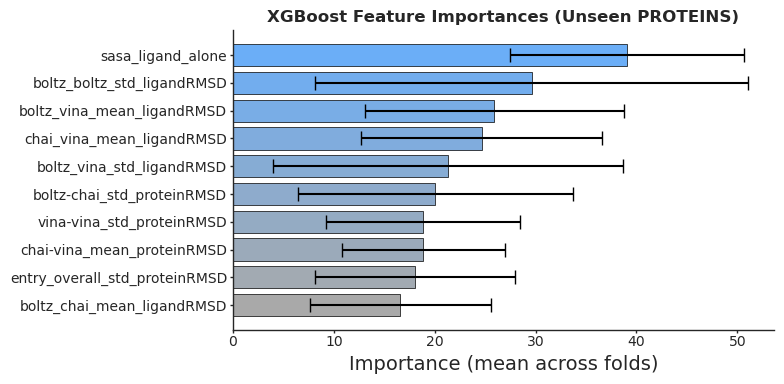


>>> Unseen SUBSTRATES (GroupKFold by substrate_name)
[Substrates CV] Fold 1: train=4004, valid=1037 (valid unique substrates=2), pos_rate=0.168, acc=0.839, precision=0.640, recall=0.092, f1=0.161, roc_auc=0.7591867449820859
[Substrates CV] Fold 2: train=4019, valid=1022 (valid unique substrates=2), pos_rate=0.094, acc=0.884, precision=0.416, recall=0.594, f1=0.489, roc_auc=0.9069699424046076
[Substrates CV] Fold 3: train=4035, valid=1006 (valid unique substrates=2), pos_rate=0.451, acc=0.619, precision=0.735, recall=0.244, f1=0.367, roc_auc=0.6302951222626572
[Substrates CV] Fold 4: train=4053, valid=988 (valid unique substrates=2), pos_rate=0.082, acc=0.427, precision=0.095, recall=0.704, f1=0.168, roc_auc=0.6455551472089509
[Substrates CV] Fold 5: train=4053, valid=988 (valid unique substrates=2), pos_rate=0.316, acc=0.710, precision=0.963, recall=0.083, f1=0.153, roc_auc=0.8433991427704446
== Substrate-wise CV Summary (mean ± sd) ==
folds_used: 5, folds_with_auc: 5
n_train: 4032.8 

,Feature,mean,std
0,sasa_ligand_alone,46.061073,13.552110
1,chai_vina_mean_ligandRMSD,30.293160,24.982064
2,entry_overall_mean_proteinRMSD,29.686889,40.744716
3,chai-vina_mean_proteinRMSD,23.965521,12.263371
4,boltz-chai_std_proteinRMSD,22.722700,11.808203
5,boltz_vina_mean_ligandRMSD,19.996690,10.678471
6,boltz_boltz_std_ligandRMSD,19.751674,7.682583
7,vina_vina_std_ligandRMSD,18.028798,3.609477
8,entry_overall_std_proteinRMSD,17.841226,8.904892
9,chai-chai_mean_proteinRMSD,17.262868,11.661477


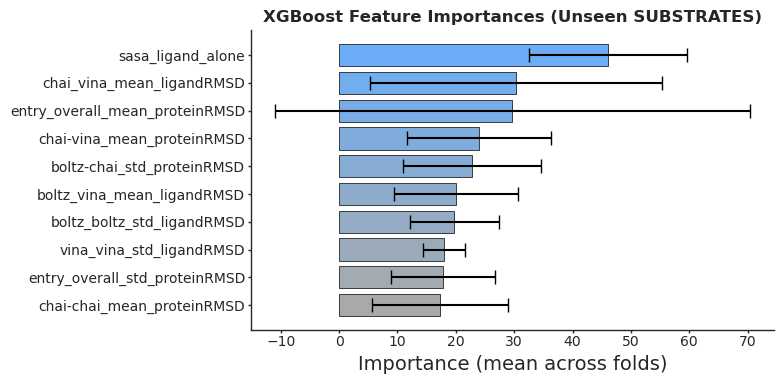


>>> Double-blocked CV (STRICT: both unseen in validation)
[Double CV STRICT] Fold 1: train=3063 (proteins=29, substrates=8), valid=258 (proteins=8, substrates=2), pos_rate=0.120, acc=0.760, precision=0.000, recall=0.000, f1=0.000, roc_auc=0.1935483870967742
[Double CV STRICT] Fold 2: train=3231 (proteins=29, substrates=8), valid=200 (proteins=8, substrates=2), pos_rate=0.315, acc=0.685, precision=0.000, recall=0.000, f1=0.000, roc_auc=0.5280963967095353
[Double CV STRICT] Fold 3: train=3257 (proteins=30, substrates=8), valid=188 (proteins=7, substrates=2), pos_rate=0.138, acc=0.761, precision=0.306, recall=0.577, f1=0.400, roc_auc=0.6391263057929724
[Double CV STRICT] Fold 4: train=3298 (proteins=30, substrates=8), valid=182 (proteins=7, substrates=2), pos_rate=0.434, acc=0.571, precision=1.000, recall=0.013, f1=0.025, roc_auc=0.7005038712056041
[Double CV STRICT] Fold 5: train=3295 (proteins=30, substrates=8), valid=193 (proteins=7, substrates=2), pos_rate=0.052, acc=0.948, precision

,Feature,mean,std
0,sasa_ligand_alone,34.711050,15.047039
1,fpocket_Polarity_Score,30.823330,27.135950
2,chai_vina_std_ligandRMSD,28.114374,19.674090
3,chai-vina_mean_proteinRMSD,25.219527,16.347381
4,chai_vina_mean_ligandRMSD,20.139472,15.576865
5,fpocket_Proportion_apolar_alpha_sphere,17.873055,21.971685
6,vina_vina_std_ligandRMSD,17.146448,4.826392
7,overall_ligandRMSD_std,17.016830,9.646822
8,vina_vina_mean_ligandRMSD,16.172429,5.797843
9,boltz_vina_mean_ligandRMSD,15.142541,8.809281


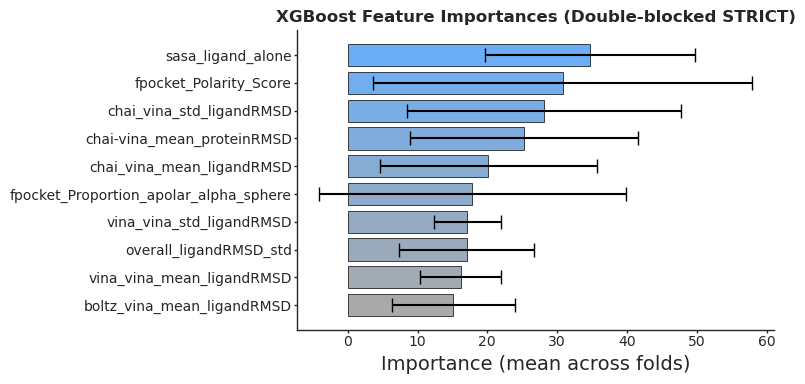

In [ ]:
# =========================
# COMPLETE GROUP-AWARE CV + FEATURE IMPORTANCE PIPELINE (XGBoost)
# with train/valid sizes & unique-group counts per fold
# =========================

# --- Imports ---
import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)

# Optional: only needed if you set importance="permutation"
try:
    from sklearn.inspection import permutation_importance
    _HAS_PERM = True
except Exception:
    _HAS_PERM = False


# --- Utils: safe display (works in/without notebooks) ---
def _safe_display(df, head=10, title=None):
    if title:
        print(title)
    try:
        # Jupyter/IPython
        from IPython.display import display
        display(df.head(head))
    except Exception:
        # Fallback to plain print
        print(df.head(head).to_string(index=False))


# --- Model factory (handles class imbalance per fold) ---
def make_model(y_train):
    pos = int((y_train == 1).sum())
    neg = int((y_train == 0).sum())
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0

    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        tree_method="hist",
    )


# --- Per-fold metrics ---
def fold_metrics(y_true, proba, pred):
    uniq = np.unique(y_true)
    m = {
        "n": len(y_true),
        "pos_rate": float((y_true == 1).mean()) if len(y_true) else np.nan,
        "acc": accuracy_score(y_true, pred) if len(y_true) else np.nan,
        "precision": precision_score(y_true, pred, zero_division=0) if len(y_true) else np.nan,
        "recall":    recall_score(y_true, pred, zero_division=0)    if len(y_true) else np.nan,
        "f1": f1_score(y_true, pred, zero_division=0) if len(y_true) else np.nan,
        "roc_auc": roc_auc_score(y_true, proba) if len(uniq) == 2 else np.nan,
    }
    return m


# --- Aggregate metrics across folds (mean ± sd) ---
def summarize_scores(fold_scores):
    if not fold_scores:
        return {}
    df_sc = pd.DataFrame(fold_scores)

    out = {
        "folds_used":   int(len(df_sc)),
        "folds_with_auc": int(np.isfinite(df_sc.get("roc_auc", pd.Series(np.nan))).sum()),
        "n_mean": df_sc["n"].mean(),
        "n_sd":   df_sc["n"].std(ddof=1),
        "pos_rate_mean": df_sc["pos_rate"].mean(),
        "pos_rate_sd":   df_sc["pos_rate"].std(ddof=1),
        "acc_mean": df_sc["acc"].mean(),
        "acc_sd":   df_sc["acc"].std(ddof=1),
        "precision_mean": df_sc["precision"].mean(),
        "precision_sd":   df_sc["precision"].std(ddof=1),
        "recall_mean":    df_sc["recall"].mean(),
        "recall_sd":      df_sc["recall"].std(ddof=1),
        "f1_mean":  df_sc["f1"].mean(),
        "f1_sd":    df_sc["f1"].std(ddof=1),
        "roc_auc_mean": float(np.nanmean(df_sc.get("roc_auc", pd.Series(np.nan)).values)),
        "roc_auc_sd":   float(np.nanstd(df_sc.get("roc_auc", pd.Series(np.nan)).values, ddof=1)),
    }

    # Optional numeric extras: include mean/sd if present
    optional_cols = [
        "n_train", "n_valid",
        "n_groups_valid",                 # for protein/substrate CV
        "n_proteins_valid", "n_substrates_valid",  # for double-blocked
        "n_proteins_train", "n_substrates_train",
    ]
    for col in optional_cols:
        if col in df_sc.columns:
            out[f"{col}_mean"] = df_sc[col].mean()
            out[f"{col}_sd"]   = df_sc[col].std(ddof=1)

    return out


# --- Pretty-printer for CV summary (prints only) ---
def _print_cv_summary(fold_scores, title):
    summ = summarize_scores(fold_scores)
    print(title)
    if not summ:
        print("(no folds)")
        return

    print(f"folds_used: {summ['folds_used']}, folds_with_auc: {summ['folds_with_auc']}")

    def pr(label, mean_key, sd_key, fmt="{:.3f} ± {:.3f}"):
        m = summ.get(mean_key, np.nan)
        s = summ.get(sd_key, np.nan)
        if np.isfinite(m):
            print(f"{label}: " + fmt.format(m, s))

    # sample counts
    pr("n_train", "n_train_mean", "n_train_sd", fmt="{:.1f} ± {:.1f}")
    pr("n_valid", "n_valid_mean", "n_valid_sd", fmt="{:.1f} ± {:.1f}")
    pr("n (valid rows)", "n_mean", "n_sd", fmt="{:.1f} ± {:.1f}")

    # group counts if present
    pr("valid unique groups", "n_groups_valid_mean", "n_groups_valid_sd", fmt="{:.1f} ± {:.1f}")
    pr("valid unique proteins", "n_proteins_valid_mean", "n_proteins_valid_sd", fmt="{:.1f} ± {:.1f}")
    pr("valid unique substrates", "n_substrates_valid_mean", "n_substrates_valid_sd", fmt="{:.1f} ± {:.1f}")
    pr("train unique proteins", "n_proteins_train_mean", "n_proteins_train_sd", fmt="{:.1f} ± {:.1f}")
    pr("train unique substrates", "n_substrates_train_mean", "n_substrates_train_sd", fmt="{:.1f} ± {:.1f}")

    # label stats & metrics
    pr("pos_rate", "pos_rate_mean", "pos_rate_sd")
    pr("acc",      "acc_mean",      "acc_sd")
    pr("precision","precision_mean","precision_sd")
    pr("recall",   "recall_mean",   "recall_sd")
    pr("f1",       "f1_mean",       "f1_sd")
    pr("roc_auc",  "roc_auc_mean",  "roc_auc_sd")


# --- Feature importance helpers ---
def _xgb_feature_importance(model, feature_names, method="gain"):
    """
    Returns a pandas Series (index=feature name, values=importance).
    method ∈ {"gain","weight","cover","total_gain","total_cover","sklearn"}.
    """
    booster = model.get_booster()
    if method == "sklearn":
        return pd.Series(model.feature_importances_, index=feature_names, dtype=float)

    imp_dict = booster.get_score(importance_type=method)  # keys may be real names or f0,f1,...
    names = booster.feature_names

    if names is not None and set(imp_dict.keys()).issubset(set(names)):
        s = pd.Series(imp_dict, dtype=float)
        s = s.reindex(feature_names).fillna(0.0)
        s.index.name = "Feature"
        return s
    else:
        # map f0,f1,... to feature_names by index
        idx_map = {f"f{i}": fn for i, fn in enumerate(feature_names)}
        mapped = {idx_map[k]: v for k, v in imp_dict.items() if k in idx_map}
        s = pd.Series(mapped, index=feature_names, dtype=float).fillna(0.0)
        s.index.name = "Feature"
        return s


def _permutation_importance(model, X_val, y_val, scoring="roc_auc", n_repeats=10, random_state=42):
    """
    Permutation importance on the validation fold.
    Returns Series of mean score drop, indexed by feature name.
    """
    if not _HAS_PERM:
        raise ImportError("scikit-learn permutation_importance not available. Install scikit-learn >= 0.22.")
    r = permutation_importance(model, X_val, y_val, scoring=scoring,
                               n_repeats=n_repeats, random_state=random_state, n_jobs=-1)
    s = pd.Series(r.importances_mean, index=X_val.columns, dtype=float)
    s.index.name = "Feature"
    return s


def _aggregate_importances(per_fold_importances):
    """
    per_fold_importances: list of Series (index=Feature, values=importance)
    Returns DataFrame with columns: Feature, mean, std (sorted by mean desc).
    """
    if not per_fold_importances:
        return pd.DataFrame(columns=["Feature", "mean", "std"])
    M = pd.concat(per_fold_importances, axis=1)  # columns = folds
    df = pd.DataFrame({
        "Feature": M.index,
        "mean": M.mean(axis=1).astype(float),
        "std":  M.std(axis=1).astype(float),
    }).sort_values("mean", ascending=False).reset_index(drop=True)
    return df


# --- CV: Unseen proteins (GroupKFold by protein ID) ---
def cv_unseen_proteins(X, y, groups, n_splits=5, importance="gain", top_n=None,
                       perm_scoring="roc_auc", perm_repeats=10):
    """
    importance: "gain","weight","cover","total_gain","total_cover","sklearn","permutation"
    Returns: (fold_scores: list[dict], fi_df: DataFrame[Feature, mean, std])
    """
    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []
    per_fold_imps = []

    for fold, (tr, va) in enumerate(gkf.split(X, y, groups=groups), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]

        model = make_model(y_tr)
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)

        sc = fold_metrics(y_va, proba, pred)
        sc["fold"] = fold
        sc["n_train"] = int(len(y_tr))
        sc["n_valid"] = int(len(y_va))
        # unique groups in validation fold
        sc["n_groups_valid"] = int(pd.Series(groups).iloc[va].nunique())
        fold_scores.append(sc)

        print(f"[Proteins CV] Fold {fold}: "
              f"train={sc['n_train']}, valid={sc['n_valid']} "
              f"(valid unique proteins={sc['n_groups_valid']}), "
              f"pos_rate={sc['pos_rate']:.3f}, acc={sc['acc']:.3f}, "
              f"precision={sc['precision']:.3f}, recall={sc['recall']:.3f}, "
              f"f1={sc['f1']:.3f}, roc_auc={sc['roc_auc'] if np.isfinite(sc['roc_auc']) else 'NA'}")

        # Feature importance per fold
        if importance == "permutation":
            s_imp = _permutation_importance(model, X_va, y_va, scoring=perm_scoring, n_repeats=perm_repeats)
        else:
            s_imp = _xgb_feature_importance(model, X_tr.columns.tolist(), method=importance)
        s_imp.name = f"fold_{fold}"
        per_fold_imps.append(s_imp)

    _print_cv_summary(fold_scores, "== Protein-wise CV Summary (mean ± sd) ==")
    fi = _aggregate_importances(per_fold_imps)
    if top_n is not None:
        fi = fi.head(top_n)
    return fold_scores, fi


# --- CV: Unseen substrates (GroupKFold by substrate) ---
def cv_unseen_substrates(X, y, groups, n_splits=5, importance="gain", top_n=None,
                         perm_scoring="roc_auc", perm_repeats=10):
    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []
    per_fold_imps = []

    for fold, (tr, va) in enumerate(gkf.split(X, y, groups=groups), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]

        model = make_model(y_tr)
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)

        sc = fold_metrics(y_va, proba, pred)
        sc["fold"] = fold
        sc["n_train"] = int(len(y_tr))
        sc["n_valid"] = int(len(y_va))
        sc["n_groups_valid"] = int(pd.Series(groups).iloc[va].nunique())
        fold_scores.append(sc)

        print(f"[Substrates CV] Fold {fold}: "
              f"train={sc['n_train']}, valid={sc['n_valid']} "
              f"(valid unique substrates={sc['n_groups_valid']}), "
              f"pos_rate={sc['pos_rate']:.3f}, acc={sc['acc']:.3f}, "
              f"precision={sc['precision']:.3f}, recall={sc['recall']:.3f}, "
              f"f1={sc['f1']:.3f}, roc_auc={sc['roc_auc'] if np.isfinite(sc['roc_auc']) else 'NA'}")

        if importance == "permutation":
            s_imp = _permutation_importance(model, X_va, y_va, scoring=perm_scoring, n_repeats=perm_repeats)
        else:
            s_imp = _xgb_feature_importance(model, X_tr.columns.tolist(), method=importance)
        s_imp.name = f"fold_{fold}"
        per_fold_imps.append(s_imp)

    _print_cv_summary(fold_scores, "== Substrate-wise CV Summary (mean ± sd) ==")
    fi = _aggregate_importances(per_fold_imps)
    if top_n is not None:
        fi = fi.head(top_n)
    return fold_scores, fi


# --- CV: Double-blocked (proteins & substrates) ---
def cv_double_blocked(X, y, proteins, substrates, K=5, strict=True, random_state=42,
                      importance="gain", top_n=None, perm_scoring="roc_auc", perm_repeats=10):
    """
    Training excludes any row whose protein ∈ prot_block OR substrate ∈ subs_block.
    Validation:
      - strict=True : rows with protein ∈ prot_block AND substrate ∈ subs_block
      - strict=False: rows with protein ∈ prot_block OR  substrate ∈ subs_block
    """
    rng = np.random.default_rng(random_state)
    uniq_p = np.array(pd.unique(proteins))
    uniq_s = np.array(pd.unique(substrates))
    rng.shuffle(uniq_p); rng.shuffle(uniq_s)
    prot_blocks = np.array_split(uniq_p, K)
    subs_blocks = np.array_split(uniq_s, K)

    fold_scores = []
    per_fold_imps = []

    for k in range(K):
        prot_block = set(prot_blocks[k])
        subs_block = set(subs_blocks[k])

        train_mask = (~proteins.isin(prot_block)) & (~substrates.isin(subs_block))
        if strict:
            valid_mask = (proteins.isin(prot_block)) & (substrates.isin(subs_block))
        else:
            valid_mask = (proteins.isin(prot_block)) | (substrates.isin(subs_block))

        X_tr, y_tr = X.loc[train_mask], y.loc[train_mask]
        X_va, y_va = X.loc[valid_mask], y.loc[valid_mask]

        if len(y_va) == 0 or len(y_tr) == 0:
            print(f"[Double CV] Fold {k+1}: skipped (empty train/valid)")
            continue

        model = make_model(y_tr)
        model.fit(X_tr, y_tr)

        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)

        sc = fold_metrics(y_va, proba, pred)
        sc["fold"] = k+1
        sc["n_train"] = int(len(y_tr))
        sc["n_valid"] = int(len(y_va))
        sc["n_proteins_valid"] = int(proteins[valid_mask].nunique())
        sc["n_substrates_valid"] = int(substrates[valid_mask].nunique())
        sc["n_proteins_train"] = int(proteins[train_mask].nunique())
        sc["n_substrates_train"] = int(substrates[train_mask].nunique())
        fold_scores.append(sc)

        print(f"[Double CV {'STRICT' if strict else 'RELAX'}] Fold {k+1}: "
              f"train={sc['n_train']} (proteins={sc['n_proteins_train']}, substrates={sc['n_substrates_train']}), "
              f"valid={sc['n_valid']} (proteins={sc['n_proteins_valid']}, substrates={sc['n_substrates_valid']}), "
              f"pos_rate={sc['pos_rate']:.3f}, acc={sc['acc']:.3f}, "
              f"precision={sc['precision']:.3f}, recall={sc['recall']:.3f}, "
              f"f1={sc['f1']:.3f}, roc_auc={sc['roc_auc'] if np.isfinite(sc['roc_auc']) else 'NA'}")

        if importance == "permutation":
            s_imp = _permutation_importance(model, X_va, y_va, scoring=perm_scoring, n_repeats=perm_repeats)
        else:
            s_imp = _xgb_feature_importance(model, X_tr.columns.tolist(), method=importance)
        s_imp.name = f"fold_{k+1}"
        per_fold_imps.append(s_imp)

    _print_cv_summary(fold_scores, f"== Double-blocked CV ({'STRICT' if strict else 'RELAXED'}) Summary (mean ± sd) ==")
    fi = _aggregate_importances(per_fold_imps)
    if top_n is not None:
        fi = fi.head(top_n)
    return fold_scores, fi



# --- Plotting (Matplotlib; stable with xerr/std) ---
import matplotlib.pyplot as plt

def plot_feature_importances(fi_df, title="Feature Importances (mean ± sd)", top_n=20):
    """
    Plot barplot of feature importances (mean across folds) with std as error bars.
    fi_df must have columns ["Feature","mean","std"].
    """
    if fi_df is None or fi_df.empty:
        print("No feature importances to plot.")
        return

    plot_df = fi_df.head(top_n).copy()
    # reverse order so the most important is at the top
    plot_df = plot_df.iloc[::-1]

    height = max(4, 0.3 * len(plot_df))
    plt.figure(figsize=(8, height))

    means = plot_df["mean"].values
    errs  = np.nan_to_num(plot_df["std"].values, nan=0.0)
    y_pos = np.arange(len(plot_df))
    colors10 = [cPALETTE_grey_blue(x) for x in np.linspace(0, 1, 10)]
    pu.clean_plt(ax=plt.gca())
    plt.barh(y_pos, means, xerr=errs, align="center", color=colors10, ecolor="black", capsize=5, edgecolor="black", linewidth=0.5)
    plt.yticks(y_pos, plot_df["Feature"].values)
    plt.xlabel("Importance (mean across folds)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =========================
# RUN (example with your 'martinez' dataset)
# =========================
# Required inputs (replace names if your columns differ):
# - martinez: DataFrame
# - feature_columns: list[str] of feature column names
# - 'activity': label column with {'hydrolyzed','not hydrolyzed'}
# - group columns: 'UniprotID', 'substrate_name'

# 0) Copy & clean
df = martinez.copy()

# 1) Binary labels
LABEL_MAP = {"hydrolyzed": 1, "not hydrolyzed": 0}
df["label_bin"] = df["activity"].map(LABEL_MAP).astype(int)

# 2) Normalize group IDs
for col in ["UniprotID", "substrate_name"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# 3) Features matrix
X = df[feature_columns].copy()
y = df["label_bin"].copy()

# 4) Coerce object features to numeric (XGB can handle NaNs)
for c in X.columns:
    if X[c].dtype == "object":
        X[c] = pd.to_numeric(X[c], errors="coerce")

# 5) Run the three CV schemes
print("\n>>> Unseen PROTEINS (GroupKFold by UniprotID)")
prot_scores, prot_fi = cv_unseen_proteins(
    X, y, groups=df["UniprotID"], n_splits=5,
    importance="gain",  # or "permutation" (slower)
    top_n=20
)
_safe_display(prot_fi, head=10, title="\nTop features (Unseen PROTEINS)")
plot_feature_importances(prot_fi, title="XGBoost Feature Importances (Unseen PROTEINS)", top_n=10)

print("\n>>> Unseen SUBSTRATES (GroupKFold by substrate_name)")
subs_scores, subs_fi = cv_unseen_substrates(
    X, y, groups=df["substrate_name"], n_splits=5,
    importance="gain",
    top_n=20
)
_safe_display(subs_fi, head=10, title="\nTop features (Unseen SUBSTRATES)")
plot_feature_importances(subs_fi, title="XGBoost Feature Importances (Unseen SUBSTRATES)", top_n=10)

print("\n>>> Double-blocked CV (STRICT: both unseen in validation)")
dbl_strict_scores, dbl_strict_fi = cv_double_blocked(
    X, y,
    proteins=df["UniprotID"], substrates=df["substrate_name"],
    K=5, strict=True,
    importance="gain",
    top_n=20
)
_safe_display(dbl_strict_fi, head=10, title="\nTop features (Double-blocked STRICT)")
plot_feature_importances(dbl_strict_fi, title="XGBoost Feature Importances (Double-blocked STRICT)", top_n=10)

# (Optional) also run relaxed:
# print("\n>>> Double-blocked CV (RELAXED: either unseen in validation; training still excludes both blocks)")
# dbl_relax_scores, dbl_relax_fi = cv_double_blocked(
#     X, y,
#     proteins=df["UniprotID"], substrates=df["substrate_name"],
#     K=5, strict=False,
#     importance="gain",
#     top_n=20
# )
# _safe_display(dbl_relax_fi, head=10, title="\nTop features (Double-blocked RELAXED)")
# plot_feature_importances(dbl_relax_fi, title="XGBoost Feature Importances (Double-blocked RELAXED)", top_n=15)


DEDB

/tmp/ipykernel_916850/4250028294.py:242: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[id_col].str.contains(regex, case=case, na=False)
/home/helen/miniconda3/envs/promiscuity/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


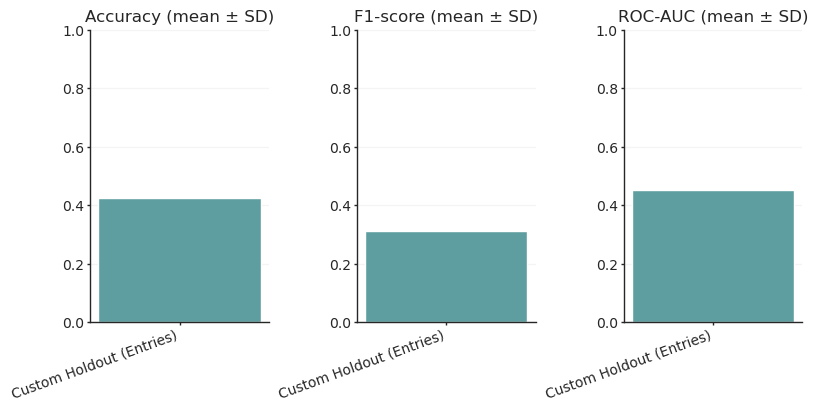

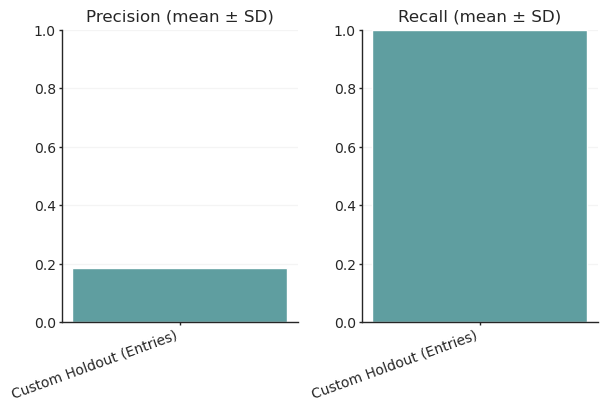

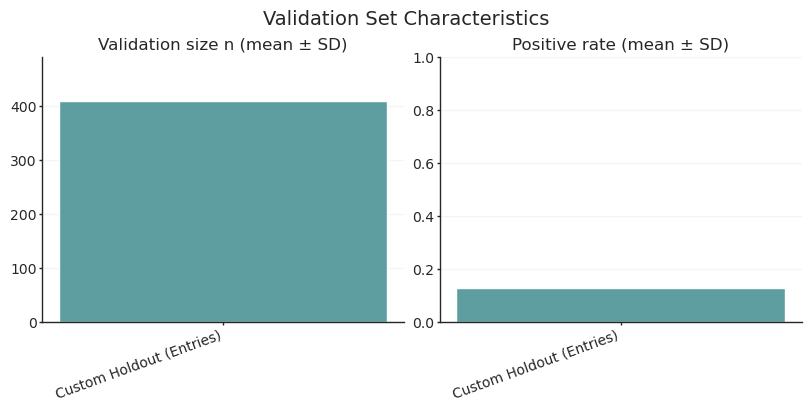


=== DEDB Custom Holdout (mean ± sd) ===
                       mode  folds_used  folds_with_auc  n_mean  n_sd  \
0  Custom Holdout (Entries)           1               1 409.000   NaN   

   pos_rate_mean  pos_rate_sd  acc_mean  acc_sd  f1_mean  f1_sd  \
0          0.130          NaN     0.425     NaN    0.311    NaN   

   precision_mean  precision_sd  recall_mean  recall_sd  roc_auc_mean  \
0           0.184           NaN        1.000        NaN         0.453   

   roc_auc_sd  
0         NaN  


In [ ]:
import numpy as np
import pandas as pd
import re
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score
)

from sklearn.metrics import precision_recall_curve

def _best_threshold_for_f1(y_true, proba):
    """Return threshold in [0,1] that maximizes F1 on (y_true, proba).
       If degenerate or empty, return 0.5."""
    y_true = np.asarray(y_true)
    if y_true.size == 0 or len(np.unique(y_true)) < 2:
        return 0.5
    # precision_recall_curve returns thresholds of length n-1
    p, r, thr = precision_recall_curve(y_true, proba)
    # Avoid division by zero: F1 = 2PR/(P+R)
    denom = (p + r)
    denom[denom == 0] = 1e-12
    f1 = 2 * p * r / denom
    # The first precision/recall corresponds to threshold below min(proba); has no threshold value
    # Align f1 (len n) to thresholds (len n-1) by dropping the first point
    if len(f1) > 1 and len(thr) == len(f1) - 1:
        f1_use = f1[1:]
    else:
        # Fallback: sweep a small grid
        grid = np.linspace(0.01, 0.99, 99)
        best_t, best_f1 = 0.5, 0.0
        for t in grid:
            pred = (proba >= t).astype(int)
            f1_t = f1_score(y_true, pred, zero_division=0)
            if f1_t > best_f1:
                best_f1, best_t = f1_t, t
        return best_t
    best_idx = int(np.nanargmax(f1_use)) if len(f1_use) else 0
    return float(thr[best_idx]) if len(thr) else 0.5

def _fold_metrics_with_threshold(y_true, proba, thr):
    """Compute metrics at a given threshold; safe for single-class y_true."""
    y_true = np.asarray(y_true)
    uniq = np.unique(y_true)
    pred = (proba >= thr).astype(int)
    out = {
        "n": len(y_true),
        "pos_rate": float((y_true == 1).mean()) if len(y_true) else np.nan,
        "acc": accuracy_score(y_true, pred) if len(y_true) else np.nan,
    }
    # precision/recall/f1 only meaningful if positives exist in labels
    if len(uniq) == 2:
        out.update({
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall":    recall_score(y_true, pred, zero_division=0),
            "f1":        f1_score(y_true, pred, zero_division=0),
            "roc_auc":   roc_auc_score(y_true, proba),
        })
    else:
        out.update({"precision": np.nan, "recall": np.nan, "f1": np.nan, "roc_auc": np.nan})
    return out


def make_model(y_train):
    pos = int((y_train == 1).sum())
    neg = int((y_train == 0).sum())
    scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        tree_method="hist",
    )

def fold_metrics(y_true, proba, pred):
    uniq = np.unique(y_true)
    m = {
        "n": len(y_true),
        "pos_rate": float((y_true == 1).mean()) if len(y_true) else np.nan,
        "acc": accuracy_score(y_true, pred) if len(y_true) else np.nan,
        "f1": f1_score(y_true, pred, zero_division=0) if len(y_true) else np.nan,
        "precision": precision_score(y_true, pred, zero_division=0) if len(y_true) else np.nan,  # NEW
        "recall":    recall_score(y_true, pred, zero_division=0)    if len(y_true) else np.nan,  # NEW
        "roc_auc": roc_auc_score(y_true, proba) if len(uniq) == 2 else np.nan,
    }
    return m

def summarize_scores(fold_scores):
    if not fold_scores:
        return {}
    df_sc = pd.DataFrame(fold_scores)
    return {
        "n_mean": df_sc["n"].mean(),
        "n_sd":   df_sc["n"].std(ddof=1),
        "pos_rate_mean": df_sc["pos_rate"].mean(),
        "pos_rate_sd":   df_sc["pos_rate"].std(ddof=1),
        "acc_mean": df_sc["acc"].mean(),
        "acc_sd":   df_sc["acc"].std(ddof=1),
        "f1_mean":  df_sc["f1"].mean(),
        "f1_sd":    df_sc["f1"].std(ddof=1),
        "precision_mean": df_sc["precision"].mean(),          # NEW
        "precision_sd":   df_sc["precision"].std(ddof=1),     # NEW
        "recall_mean":    df_sc["recall"].mean(),             # NEW
        "recall_sd":      df_sc["recall"].std(ddof=1),        # NEW
        "roc_auc_mean": np.nanmean(df_sc["roc_auc"].values),
        "roc_auc_sd":   np.nanstd(df_sc["roc_auc"].values, ddof=1),
        "folds_used":   int(len(df_sc)),
        "folds_with_auc": int(np.isfinite(df_sc["roc_auc"]).sum()),
    }

# cross validation types
def cv_unseen_proteins(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []
    for tr, va in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]
        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)
        fold_scores.append(fold_metrics(y_va, proba, pred))
    return summarize_scores(fold_scores)

def cv_unseen_substrates(X, y, groups, n_splits=5):
    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []
    for tr, va in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y.iloc[tr], y.iloc[va]
        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)
        fold_scores.append(fold_metrics(y_va, proba, pred))
    return summarize_scores(fold_scores)

def cv_double_blocked(X, y, proteins, substrates, K=5, strict=True, random_state=42):
    rng = np.random.default_rng(random_state)
    uniq_p = np.array(pd.unique(proteins))
    uniq_s = np.array(pd.unique(substrates))
    rng.shuffle(uniq_p)
    rng.shuffle(uniq_s)
    prot_blocks = np.array_split(uniq_p, K)
    subs_blocks = np.array_split(uniq_s, K)

    fold_scores = []
    for k in range(K):
        prot_block = set(prot_blocks[k])
        subs_block = set(subs_blocks[k])

        train_mask = (~proteins.isin(prot_block)) & (~substrates.isin(subs_block))
        valid_mask = (proteins.isin(prot_block)) & (substrates.isin(subs_block)) if strict \
                     else (proteins.isin(prot_block)) |  (substrates.isin(subs_block))

        X_tr, y_tr = X.loc[train_mask], y.loc[train_mask]
        X_va, y_va = X.loc[valid_mask], y.loc[valid_mask]

        # skip empty or degenerate folds
        if len(y_va) == 0 or len(y_tr) == 0:
            continue

        model = make_model(y_tr)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        pred  = model.predict(X_va)
        fold_scores.append(fold_metrics(y_va, proba, pred))
        proba = model.predict_proba(X_va)[:, 1]
        print(proba[:20])  

    return summarize_scores(fold_scores)


def evaluate_holdout_by_ids(df, feature_columns, label_col="label_bin",
                            id_col="Entry", val_ids=None):
    """
    Train on all rows NOT in val_ids (by id_col), validate ONLY on val_ids.
    Returns a dict compatible with summarize_scores() output.
    """
    if val_ids is None or len(val_ids) == 0:
        raise ValueError("val_ids must be a non-empty list of IDs to hold out.")

    df = df.copy()
    # normalize id col to str
    df[id_col] = df[id_col].astype(str).str.strip()

    # Build X, y (coerce features to numeric)
    X = df[feature_columns].copy()
    for c in X.columns:
        if X[c].dtype == "object":
            X[c] = pd.to_numeric(X[c], errors="coerce")
    y = df[label_col].astype(int)

    # Masks
    val_ids = set(map(str, val_ids))
    val_mask = df[id_col].isin(val_ids)
    train_mask = ~val_mask

    # Safety checks
    if train_mask.sum() == 0 or val_mask.sum() == 0:
        raise ValueError("Empty train or validation split. Check your val_ids and id_col.")
    if len(np.unique(y[train_mask])) < 2:
        raise ValueError("Training split has only one class; cannot train classifier.")

    # Train → Predict
    model = make_model(y[train_mask])
    model.fit(X[train_mask], y[train_mask])
    proba = model.predict_proba(X[val_mask])[:, 1]
    y_val = y[val_mask].values

    # Report both @0.5 and @best-F1 thresholds
    thr_best = _best_threshold_for_f1(y_val, proba)
    m05 = _fold_metrics_with_threshold(y_val, proba, 0.5)
    mbest = _fold_metrics_with_threshold(y_val, proba, thr_best)

    # Pick which to return. Often you’ll want mbest for F1-focused work.
    chosen = mbest

    # Make shape compatible with summarize_scores by wrapping in a list
    return summarize_scores([chosen])


def evaluate_holdout_by_pattern(df, feature_columns, label_col="label_bin",
                                id_col="Entry", patterns=("P18","R18","R19","P19"),
                                case=False):
    """
    Hold out any rows where df[id_col] contains ANY of the substrings in `patterns`.
    Substring match (regex OR), case-insensitive by default.
    """
    df = df.copy()
    df[id_col] = df[id_col].astype(str).str.strip()

    # Build safe regex: (P18|R18|R19|P19)
    regex = "(" + "|".join(re.escape(p) for p in patterns) + ")"
    mask = df[id_col].str.contains(regex, case=case, na=False)

    val_ids = df.loc[mask, id_col].unique().tolist()
    if len(val_ids) == 0:
        raise ValueError(f"No IDs matched the patterns {patterns} in column '{id_col}'.")

    # Reuse the ID-based evaluator
    return evaluate_holdout_by_ids(
        df, feature_columns=feature_columns, label_col=label_col,
        id_col=id_col, val_ids=val_ids
    )


df = DEDB.copy()

LABEL_MAP = {"promiscuous": 1, "non-promiscuous": 0}
df["label_bin"] = df["Dataset"].map(LABEL_MAP).astype(int)

# normalize group IDs
for col in ["UniprotID", "substrate_name"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

X = df[feature_columns].copy()
y = df["label_bin"].copy()

# coerce features to numeric
for c in X.columns:
    if X[c].dtype == "object":
        X[c] = pd.to_numeric(X[c], errors="coerce")

holdout_patterns = ["R19", "P19", "R20", "P20", "R18", "P18", "P33", "R33", "R34", "P34", "P18", "R18"]
#holdout_patterns = ["R22", "P22", "R38", "P38", "R23", "P23", "P21", "R21"]

id_col = "Entry"  

# Build the same label mapping for DEDB
DEDB = DEDB.copy()
LABEL_MAP = {"promiscuous": 1, "non-promiscuous": 0}
DEDB["label_bin"] = DEDB["Dataset"].map(LABEL_MAP).astype(int)

# Evaluate custom holdout
custom_summary = evaluate_holdout_by_pattern(
    DEDB,
    feature_columns=feature_columns,
    label_col="label_bin",
    id_col="Entry",                
    patterns=holdout_patterns,
    case=False                     # case-insensitive
)

# Assemble results (you can mix with the other modes if you want)
results_dedb = []
results_dedb.append({"mode": "Custom Holdout (Entries)", **custom_summary})

summary_df_dedb = pd.DataFrame(results_dedb, columns=[
    "mode",
    "folds_used", "folds_with_auc",
    "n_mean", "n_sd",
    "pos_rate_mean", "pos_rate_sd",
    "acc_mean", "acc_sd",
    "f1_mean", "f1_sd",
    "precision_mean", "precision_sd",
    "recall_mean", "recall_sd",
    "roc_auc_mean", "roc_auc_sd",
])


def _bar_with_error(ax, xlabels, means, sds, title, ylim=None):
    x = np.arange(len(xlabels))
    ax.bar(x, means, yerr=sds, capsize=5, color = "cadetblue")
    ax.set_xticks(x, xlabels, rotation=20, ha="right")
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.2)


def plot_validation_summaries(summary_df, save_prefix=None):
    dfp = summary_df.copy()
    for col in ["acc_mean","acc_sd","f1_mean","f1_sd","roc_auc_mean","roc_auc_sd",
                "precision_mean","precision_sd","recall_mean","recall_sd",
                "n_mean","n_sd","pos_rate_mean","pos_rate_sd"]:
        if col in dfp.columns:
            dfp[col] = pd.to_numeric(dfp[col], errors="coerce")

    xlabels = dfp["mode"].tolist()

    # Metrics: Accuracy, F1, ROC-AUC
    fig, axes = plt.subplots(1, 3, figsize=(8, 4), constrained_layout=True)
    _bar_with_error(axes[0], xlabels, dfp["acc_mean"], dfp["acc_sd"], "Accuracy (mean ± SD)", ylim=(0,1))
    _bar_with_error(axes[1], xlabels, dfp["f1_mean"],  dfp["f1_sd"],  "F1-score (mean ± SD)", ylim=(0,1))
    _bar_with_error(axes[2], xlabels, dfp["roc_auc_mean"], dfp["roc_auc_sd"], "ROC-AUC (mean ± SD)", ylim=(0,1))
    for ax in np.ravel(axes):
        clean_plt(ax)
    if save_prefix:
        fig.savefig(f"{save_prefix}_metrics.png", dpi=150)

    # NEW: Precision & Recall
    fig_pr, axes_pr = plt.subplots(1, 2, figsize=(6, 4), constrained_layout=True)
    _bar_with_error(axes_pr[0], xlabels, dfp["precision_mean"], dfp["precision_sd"], "Precision (mean ± SD)", ylim=(0,1))
    _bar_with_error(axes_pr[1], xlabels, dfp["recall_mean"],    dfp["recall_sd"],    "Recall (mean ± SD)",    ylim=(0,1))
    for ax in np.ravel(axes_pr):
        clean_plt(ax)
    if save_prefix:
        fig_pr.savefig(f"{save_prefix}_precision_recall.png", dpi=150)

    # Dataset characteristics
    fig2, axes2 = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)
    _bar_with_error(axes2[0], xlabels, dfp["n_mean"], dfp["n_sd"],
                    "Validation size n (mean ± SD)",
                    ylim=(0, max(1, float(dfp["n_mean"].max())*1.2)))
    _bar_with_error(axes2[1], xlabels, dfp["pos_rate_mean"], dfp["pos_rate_sd"],
                    "Positive rate (mean ± SD)", ylim=(0,1))
    fig2.suptitle("Validation Set Characteristics", fontsize=14)
    for ax in np.ravel(axes2):
        clean_plt(ax)
    if save_prefix:
        fig2.savefig(f"{save_prefix}_set_characteristics.png", dpi=150)

    plt.show()
        

plot_validation_summaries(summary_df_dedb)


with pd.option_context('display.float_format', '{:.3f}'.format):
    print("\n=== DEDB Custom Holdout (mean ± sd) ===")
    print(summary_df_dedb)

### Predict experimentally tested enzymes using XGboost boost

In [ ]:
import pandas as pd
import re

df_exptested = pd.read_pickle("/nvme2/helen/masterthesis/3_manuscript/screened_esterases/geometricfiltering/structural_features_final.pkl")

In [ ]:
tested_enzymes = [
    "pUC19",
    "TrpB",
    "QHH",
    "SbPTE",
    "Q06174",
    "O52787",
    "CEMPOHJE_228316",
    "JMPBJLAA_319200",
    "MHHEAJED_192158",
    "BNFFOPBF_118865",
    "JMPBJLAA_503136",
    "JMPBJLAA_464548",
]
pattern = "|".join(map(re.escape, tested_enzymes))  # escape special chars

df_exptested = df_exptested[df_exptested["Entry"].str.contains(pattern, case=False, na=False)]

df_exptested["activity_exp"] = (
    df_exptested["Entry"]
      .fillna("")
      .str.contains(r"(QHH|SbPTE|Q06174)", case=False, regex=True)
)

s = df_exptested["Entry"].fillna("").astype(str)
parts = s.str.split("_", n=2, expand=True)  # cols: 0=first token, 1=second token

df_exptested["enzyme"] = np.where(
    parts[1].str.match(r"^\d+$", na=False),   # if 2nd token is digits
    parts[0] + "_" + parts[1],               # keep first_second
    parts[0]                                 # else just first
)

/tmp/ipykernel_916850/1026367395.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  .str.contains(r"(QHH|SbPTE|Q06174)", case=False, regex=True)


In [ ]:
# ===== Final training + prediction on a new enzyme set =====
# Assumes you already defined:
#   - martinez (your labeled DataFrame)
#   - feature_columns (list of feature names to use)
#   - make_model(...) from your CV script (for class imbalance)

import numpy as np
import pandas as pd

# ---------- Helpers ----------
def prepare_features(df, feature_columns, train_feature_order=None):
    """
    Ensure df has the requested feature columns, coerced to numeric and in the same order
    used during training. Missing columns are added as NaN (XGBoost can handle NaNs).
    """
    X = df.copy()
    # add any missing feature columns as NaN
    for c in feature_columns:
        if c not in X.columns:
            X[c] = np.nan
    # coerce to numeric
    for c in feature_columns:
        if X[c].dtype == "object":
            X[c] = pd.to_numeric(X[c], errors="coerce")
    # order columns
    order = train_feature_order if train_feature_order is not None else feature_columns
    return X[order]

def train_final_xgb(train_df, feature_columns, label_col="label_bin"):
    """
    Fits a final XGBClassifier on ALL labeled rows, using your make_model() to set
    scale_pos_weight. Returns (model, X_train_columns_order).
    """
    y = train_df[label_col].astype(int)
    X = prepare_features(train_df, feature_columns)
    model = make_model(y)            # uses your factory (handles class imbalance)
    model.fit(X, y)
    return model, X.columns.tolist()

def predict_activity_on_new(model, new_df, feature_columns, train_feature_order,
                            id_cols=("UniprotID","substrate_name"),
                            threshold=0.5):
    """
    Applies the trained model to a new set of enzymes.
    - Returns a DataFrame with id columns (if present), predicted probability,
      and binary call at `threshold`.
    """
    X_new = prepare_features(new_df, feature_columns, train_feature_order)
    proba = model.predict_proba(X_new)[:, 1]
    pred  = (proba >= float(threshold)).astype(int)

    keep_cols = [c for c in id_cols if c in new_df.columns]
    out = new_df[keep_cols].copy() if keep_cols else pd.DataFrame(index=new_df.index)
    out["pred_proba"] = proba
    out["pred_label"] = pred
    return out.sort_values("pred_proba", ascending=False)

# ---------- Train on your labeled dataset ----------
# Map labels if you haven’t already done so
if "label_bin" not in martinez.columns:
    LABEL_MAP = {"hydrolyzed": 1, "not hydrolyzed": 0}
    martinez = martinez.copy()
    martinez["label_bin"] = martinez["activity"].map(LABEL_MAP).astype(int)

final_model, feature_order = train_final_xgb(martinez, feature_columns, label_col="label_bin")

# ---------- Predict on a new set of enzymes ----------
# Example: suppose your new set is in `new_enzymes_df`
# Make sure it has the same feature columns (any missing ones will be filled with NaN)
preds_new = predict_activity_on_new(
    final_model,
    new_df=df_exptested,          
    feature_columns=feature_columns,
    train_feature_order=feature_order,
    id_cols=("Entry","substrate_name"),  # adjust/extend as you like
    threshold=0.5                   # you can change this (e.g., 0.3 to favor recall)
)


# ---------- (Optional) choose a data-driven threshold ----------
# If you want a threshold that optimizes F1 on your training set:
from sklearn.metrics import precision_recall_curve

X_train_all = prepare_features(martinez, feature_columns, feature_order)
y_train_all = martinez["label_bin"].astype(int).values
proba_train = final_model.predict_proba(X_train_all)[:,1]
prec, rec, thr = precision_recall_curve(y_train_all, proba_train)
f1 = (2 * prec * rec) / (prec + rec + 1e-12)
best_idx = np.nanargmax(f1)
best_thr = thr[best_idx] if best_idx < len(thr) else 0.5
print(f"Best F1 threshold on training (approx): {best_thr:.3f}")

# Recompute predictions on the new set with this threshold if desired:
preds_new_f1 = predict_activity_on_new(
    final_model, df_exptested, feature_columns, feature_order,
    id_cols=("UniprotID","substrate_name"), threshold=best_thr
)

preds_new

Best F1 threshold on training (approx): 0.976


,Entry,substrate_name,pred_proba,pred_label
666,QHH21706_m-cresyldiphenylPi,m-cresyldiphenylPi,0.985232,1
664,QHH21706_m-cresyldiphenylPi,m-cresyldiphenylPi,0.982677,1
669,QHH21706_m-cresyldiphenylPi,m-cresyldiphenylPi,0.980686,1
520,O52787_tri_n_butylPi,tri_n_butylPi,0.978609,1
671,QHH21706_m-cresyldiphenylPi,m-cresyldiphenylPi,0.974933,1
...,...,...,...,...
334,JMPBJLAA_503136_TPP,TPP,0.000094,0
335,JMPBJLAA_503136_TPP,TPP,0.000094,0
339,JMPBJLAA_503136_TPP,TPP,0.000091,0
337,JMPBJLAA_503136_TPP,TPP,0.000091,0


Validation on experimental set (one row per trial):


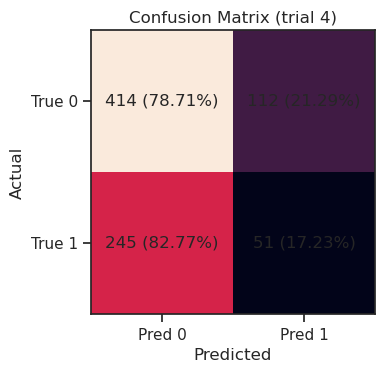

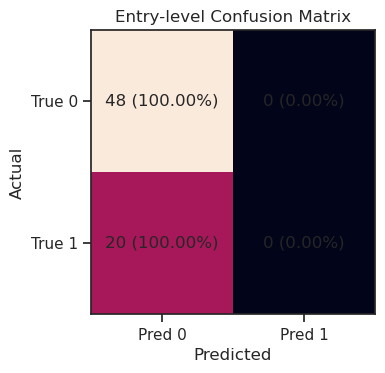

{'threshold': 0.5, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'tn': 48, 'fp': 0, 'fn': 20, 'tp': 0, 'roc_auc': 0.4791666666666667, 'avg_prec': 0.32164635359745486, 'brier': 0.2581547322508002}


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve
)

# Requires:
# - martinez with 'label_bin' (1=positive, 0=negative)
# - df_exptested with 'activity_exp' (boolean/int)
# - feature_columns
# - prepare_features(...)
# - make_model(y) -> returns an XGBClassifier (or similar)


import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, average_precision_score, brier_score_loss
)

def aggregate_predictions_by_entry(
    pred_df,
    id_col="Entry",
    proba_col="pred_proba",
    threshold=0.5,
    truth_df=None,              # e.g., df_exptested
    truth_col="activity_exp",
    truth_reduce="any"          # how to aggregate truth per Entry: "any", "majority", "all", or "mean"
):
    """
    - Averages predicted probabilities over duplicate entries.
    - Produces a single binary prediction per Entry using `threshold` on the mean probability.
    - Optionally merges & aggregates ground truth per Entry for evaluation.

    Returns: agg (DataFrame), and (optionally) metrics dict if truth was provided.
    """
    # 1) Aggregate predictions per Entry
    grp = pred_df.groupby(id_col)[proba_col]
    agg = grp.agg(
        pred_proba_mean="mean",
        pred_proba_median="median",
        pred_proba_std="std",
        n_rows="size"
    ).reset_index()
    agg["pred_label"] = (agg["pred_proba_mean"] >= float(threshold)).astype(int)

    metrics = None

    # 2) Optional: attach aggregated ground truth per Entry
    if truth_df is not None and truth_col in truth_df.columns:
        # If truth already in pred_df, use that; else merge it in for aggregation
        if truth_col in pred_df.columns:
            truth_source = pred_df[[id_col, truth_col]].copy()
        else:
            truth_source = pred_df[[id_col]].merge(truth_df[[id_col, truth_col]], on=id_col, how="left")

        # Aggregate truth per Entry using chosen reducer
        tc = truth_source.copy()
        # ensure boolean-ish
        tc[truth_col] = tc[truth_col].astype(float)  # handles 0/1 or True/False

        if truth_reduce == "any":
            truth_agg = tc.groupby(id_col)[truth_col].agg(lambda s: int((s == 1).any())).reset_index()
        elif truth_reduce == "majority":
            truth_agg = tc.groupby(id_col)[truth_col].agg(lambda s: int((s.mean() >= 0.5))).reset_index()
        elif truth_reduce == "all":
            truth_agg = tc.groupby(id_col)[truth_col].agg(lambda s: int((s == 1).all())).reset_index()
        elif truth_reduce == "mean":
            # rounds mean to 0/1; also keep the mean for reference
            truth_agg = tc.groupby(id_col)[truth_col].agg(["mean"]).reset_index()
            truth_agg["truth_mean"] = truth_agg["mean"]
            truth_agg[truth_col] = (truth_agg["mean"] >= 0.5).astype(int)
            truth_agg = truth_agg.drop(columns=["mean"])
        else:
            raise ValueError("truth_reduce must be one of {'any','majority','all','mean'}")

        agg = agg.merge(truth_agg, on=id_col, how="left")

        # 3) Compute metrics on aggregated level
        if truth_col in agg.columns:
            y_true = agg[truth_col].astype(int).values
            y_score = agg["pred_proba_mean"].values
            y_pred  = agg["pred_label"].astype(int).values

            prec, rec, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, average="binary", zero_division=0
            )
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
            metrics = dict(
                threshold=float(threshold),
                precision=float(prec),
                recall=float(rec),
                f1=float(f1),
                tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
                roc_auc=float(roc_auc_score(y_true, y_score)),
                avg_prec=float(average_precision_score(y_true, y_score)),
                brier=float(brier_score_loss(y_true, y_score))
            )

    return agg, metrics


def train_pos_all_neg_subsets_validate_on_experimental(
    train_df,
    exp_df,
    feature_columns,
    label_col="label_bin",
    exp_truth_col="activity_exp",
    id_cols=("Entry", "substrate_name"),
    neg_pos_ratio=1.0,         # e.g., 1.0 => ~1:1 neg:pos in TRAIN
    n_trials=5,                # how many different negative samples to try
    base_seed=123,             # base RNG seed for reproducibility
    decision_threshold=0.5,    # operating threshold for metrics
):
    """
    For each trial:
      - Train set = ALL positives + (downsampled) NEGATIVES at neg_pos_ratio
      - Fit model (via make_model)
      - Predict on experimental set and compute metrics vs exp_truth_col
    Returns:
      - summary_df: one row per trial with metrics
      - models: list of trained models
      - preds_per_trial: list of DataFrames with predictions on experimental set
    """
    # --- Split positives / negatives in TRAIN ---
    df = train_df.copy()
    y = df[label_col].astype(int).values
    pos_df = df.iloc[np.where(y == 1)[0]]
    neg_df = df.iloc[np.where(y == 0)[0]]

    # --- Prepare experimental ground truth ---
    if exp_truth_col not in exp_df.columns:
        raise ValueError(f"Experimental DataFrame must contain '{exp_truth_col}'")
    exp_truth = exp_df[exp_truth_col].astype(int).values

    models = []
    preds_per_trial = []
    rows = []

    for t in range(n_trials):
        rng = np.random.RandomState(base_seed + t)

        # Downsample negatives for TRAIN according to neg_pos_ratio
        n_pos = len(pos_df)
        n_neg_target = int(np.round(neg_pos_ratio * n_pos))
        n_neg_target = min(n_neg_target, len(neg_df)) if n_neg_target > 0 else 0
        neg_sample = neg_df.sample(n=n_neg_target, random_state=rng) if n_neg_target > 0 else neg_df.iloc[[]]

        train_bal = pd.concat([pos_df, neg_sample], axis=0)

        # Prepare TRAIN features
        X_train = prepare_features(train_bal, feature_columns, train_feature_order=None)
        y_train = train_bal[label_col].astype(int).values
        feature_order = X_train.columns.tolist()

        # Fit model
        model = make_model(y_train)
        model.fit(X_train, y_train)
        models.append(model)

        # Predict on EXPERIMENTAL set
        X_exp = prepare_features(exp_df, feature_columns, train_feature_order=feature_order)
        proba_exp = model.predict_proba(X_exp)[:, 1]
        y_pred = (proba_exp >= float(decision_threshold)).astype(int)

        # Compute metrics on EXP set
        prec, rec, f1, _ = precision_recall_fscore_support(
            exp_truth, y_pred, average="binary", zero_division=0
        )
        tn, fp, fn, tp = confusion_matrix(exp_truth, y_pred).ravel()
        roc_auc = roc_auc_score(exp_truth, proba_exp)
        ap = average_precision_score(exp_truth, proba_exp)
        brier = brier_score_loss(exp_truth, proba_exp)

        # Keep predictions table
        keep_cols = [c for c in id_cols if c in exp_df.columns]
        out = exp_df[keep_cols].copy() if keep_cols else pd.DataFrame(index=exp_df.index)
        out["pred_proba"] = proba_exp
        out["pred_label"] = y_pred
        out[exp_truth_col] = exp_truth
        preds_per_trial.append(out)

        # Record summary
        rows.append({
            "trial": t,
            "seed": int(base_seed + t),
            "neg_pos_ratio": float(neg_pos_ratio),
            "n_pos_train": int(n_pos),
            "n_neg_train": int(n_neg_target),
            "threshold": float(decision_threshold),
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
            "roc_auc": float(roc_auc),
            "avg_prec": float(ap),
            "brier": float(brier),
        })

    summary_df = pd.DataFrame(rows).sort_values(["avg_prec", "roc_auc", "f1"], ascending=False)
    return summary_df, models, preds_per_trial

# ===================== USAGE =====================

# Ensure labels exist in training set
if "label_bin" not in martinez.columns:
    LABEL_MAP = {"hydrolyzed": 1, "not hydrolyzed": 0}
    martinez = martinez.copy()
    martinez["label_bin"] = martinez["activity"].map(LABEL_MAP).astype(int)

# Run the training-on-all-positives + neg-subsets, validate on experimental
summary, model_list, preds_list = train_pos_all_neg_subsets_validate_on_experimental(
    train_df=martinez,
    exp_df=df_exptested,                # <- has 'activity_exp'
    feature_columns=feature_columns,
    label_col="label_bin",
    exp_truth_col="activity_exp",
    id_cols=("Entry", "substrate_name"),
    neg_pos_ratio=1.0,                  # try 0.5, 1.0, 2.0, etc.
    n_trials=5,
    base_seed=123,
    decision_threshold=0.2              # evaluate at 0.5 on experimental
)

print("Validation on experimental set (one row per trial):")
#print(summary)

# Example: get the predictions for the best trial (row 0 after sorting)
best_preds = preds_list[int(summary.iloc[0]["trial"])]


import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Pick the best trial
best_idx = summary.sort_values(["avg_prec", "roc_auc", "f1"], ascending=False).index[0]
best_trial = int(summary.loc[best_idx, "trial"])

# Get that trial's predictions on the experimental set
eval_df = preds_list[best_trial].copy()  # has columns: pred_label, pred_proba, activity_exp (+ your IDs)

# Prepare y_true / y_pred
y_true = eval_df["activity_exp"].astype(int).values
y_pred = eval_df["pred_label"].astype(int).values

# Confusion matrix (rows=true, cols=pred)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_norm = cm / cm.sum(axis=1, keepdims=True)

# Plot (one chart, matplotlib, no explicit colors)
fig, ax = plt.subplots()
im = ax.imshow(cm)

ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (trial {best_trial})")

# Annotate with counts and row-normalized percentages
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]:.2%})", ha="center", va="center")

plt.tight_layout()
plt.show()


agg_eval, agg_metrics = aggregate_predictions_by_entry(
    pred_df=preds_new,                # has Entry + pred_proba
    id_col="Entry",
    proba_col="pred_proba",
    threshold=0.5,                    # change if you like (e.g., best_thr)
    truth_df=df_exptested,            # has Entry + activity_exp
    truth_col="activity_exp",
    truth_reduce="any"                # options: "any", "majority", "all", "mean"
)

# 2) Build confusion matrix at Entry level
y_true = agg_eval["activity_exp"].astype(int).values
y_pred = agg_eval["pred_label"].astype(int).values

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])        # [[TN FP],[FN TP]]
cm_norm = cm / cm.sum(axis=1, keepdims=True)                # row-normalized (%)

# 3) Plot (single figure, matplotlib, no explicit colors)
fig, ax = plt.subplots()
im = ax.imshow(cm)

ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Entry-level Confusion Matrix")

# Annotate with counts and row-normalized percentages
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]:.2%})", ha="center", va="center")

plt.tight_layout()
plt.show()

# (Optional) print Entry-level metrics summary you computed
print(agg_metrics)

Enzyme-level metrics: {'threshold': 0.3, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'tn': 4, 'fp': 1, 'fn': 3, 'tp': 0, 'roc_auc': 0.4666666666666666, 'avg_prec': 0.4206349206349207, 'brier': 0.2787475396672223}
            enzyme  pred_proba_mean  pred_proba_median  pred_proba_std  \
0  BNFFOPBF_118865         0.324309           0.312896        0.293913   
1         CEMPOHJE         0.243877           0.049482        0.370944   
2         JMPBJLAA         0.155515           0.006712        0.249507   
3         MHHEAJED         0.058382           0.034149        0.066277   
4           O52787         0.211366           0.002532        0.374421   

   n_rows  pred_label  activity_exp  
0    1095           1             0  
1     903           0             0  
2    2707           0             0  
3     411           0             0  
4    1126           0             0  


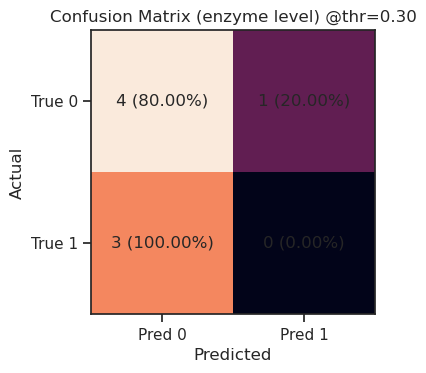

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, average_precision_score, brier_score_loss
)

# ---------- 0) Ensure preds_new has 'enzyme' and (optionally) 'activity_exp' ----------
# Assumes:
#   - preds_new: from predict_activity_on_new(...), contains at least ['Entry','pred_proba']
#   - df_exptested: your experimental dataframe with columns ['Entry','enzyme', 'activity_exp']

cols_to_bring = [c for c in ["Entry", "enzyme", "activity_exp"] if c in df_exptested.columns]
if "enzyme" not in preds_new.columns:
    preds_new = preds_new.merge(df_exptested[cols_to_bring], on="Entry", how="left")

# ---------- 1) Helper to aggregate by enzyme and (optionally) evaluate ----------
def aggregate_predictions_by_enzyme(
    pred_df: pd.DataFrame,
    enzyme_col: str = "enzyme",
    proba_col: str = "pred_proba",
    threshold: float = 0.5,
    truth_col: str = "activity_exp",          # set to None to skip evaluation
    truth_reduce: str = "any"                  # "any" | "majority" | "all" | "mean"
):
    """
    - Averages predicted probabilities per enzyme.
    - Creates a single binary call per enzyme via `threshold` on the mean probability.
    - If truth_col is present, aggregates it to enzyme-level using `truth_reduce` and computes metrics.
    Returns:
      agg_enzyme (DataFrame), metrics (dict or None)
    """
    # 1) Aggregate predictions
    g = pred_df.groupby(enzyme_col)[proba_col]
    agg = g.agg(
        pred_proba_mean="mean",
        pred_proba_median="median",
        pred_proba_std="std",
        n_rows="size"
    ).reset_index()
    agg["pred_label"] = (agg["pred_proba_mean"] >= float(threshold)).astype(int)

    metrics = None

    # 2) Aggregate truth (optional)
    if truth_col is not None and truth_col in pred_df.columns:
        tc = pred_df[[enzyme_col, truth_col]].copy()
        # normalize to numeric 0/1 for robust aggregation
        tc[truth_col] = tc[truth_col].astype(float)

        if truth_reduce == "any":
            truth = tc.groupby(enzyme_col)[truth_col].agg(lambda s: int((s == 1).any())).reset_index()
        elif truth_reduce == "majority":
            truth = tc.groupby(enzyme_col)[truth_col].agg(lambda s: int((s.mean() >= 0.5))).reset_index()
        elif truth_reduce == "all":
            truth = tc.groupby(enzyme_col)[truth_col].agg(lambda s: int((s == 1).all())).reset_index()
        elif truth_reduce == "mean":
            truth = tc.groupby(enzyme_col)[truth_col].mean().reset_index()
            truth = truth.rename(columns={truth_col: "truth_mean"})
            truth[truth_col] = (truth["truth_mean"] >= 0.5).astype(int)
        else:
            raise ValueError("truth_reduce must be one of {'any','majority','all','mean'}")

        agg = agg.merge(truth, on=enzyme_col, how="left")

        # 3) Compute enzyme-level metrics
        if truth_col in agg.columns:
            y_true = agg[truth_col].astype(int).values
            y_score = agg["pred_proba_mean"].values
            y_pred  = agg["pred_label"].astype(int).values

            prec, rec, f1, _ = precision_recall_fscore_support(
                y_true, y_pred, average="binary", zero_division=0
            )
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

            metrics = dict(
                threshold=float(threshold),
                precision=float(prec),
                recall=float(rec),
                f1=float(f1),
                tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
                roc_auc=float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
                avg_prec=float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
                brier=float(brier_score_loss(y_true, y_score))
            )

    return agg, metrics

# ---------- 2) Run aggregation (choose your threshold & truth reducer) ----------
THRESHOLD = 0.3     # or use your CV-derived 'best_thr_cv'
TRUTH_RULE = "any"  # "any" | "majority" | "all" | "mean"

agg_enzyme, met_enzyme = aggregate_predictions_by_enzyme(
    preds_new,
    enzyme_col="enzyme",
    proba_col="pred_proba",
    threshold=THRESHOLD,
    truth_col="activity_exp",      # set to None if you don't have truth on experimental
    truth_reduce=TRUTH_RULE
)

print("Enzyme-level metrics:", met_enzyme)
print(agg_enzyme.head())

# ---------- 3) Plot enzyme-level confusion matrix ----------
if "activity_exp" in agg_enzyme.columns:
    y_true = agg_enzyme["activity_exp"].astype(int).values
    y_pred = agg_enzyme["pred_label"].astype(int).values

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN FP],[FN TP]]
    row_sums = cm.sum(axis=1, keepdims=True)
    # avoid division by zero in case a row has zero count
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    fig, ax = plt.subplots()
    im = ax.imshow(cm)  # default colormap; one chart only

    ax.set_xticks([0, 1]); ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["True 0", "True 1"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix (enzyme level) @thr={THRESHOLD:.2f}")

    # annotate counts and row-normalized percentages
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]:.2%})",
                    ha="center", va="center")

    plt.tight_layout()
    plt.show()
else:
    print("No 'activity_exp' in agg_enzyme; skipping confusion matrix plot.")


In [ ]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_fscore_support, confusion_matrix
)
import numpy as np
import pandas as pd

# --- 1) Align predictions with ground-truth column ---
eval_df = preds_new.join(
    df_exptested[["activity_exp"]],  # ground truth
    how="left"
)

# Ensure boolean/integer GT
eval_df["activity_exp"] = eval_df["activity_exp"].astype(bool)
y_true = eval_df["activity_exp"].astype(int).values
y_score = eval_df["pred_proba"].values

# Use the same threshold you used for preds_new
thr = best_thr  # or 'best_thr' if you computed it earlier
eval_df["pred_label_thr"] = (eval_df["pred_proba"] >= float(thr)).astype(int)

# --- 2) Scalar metrics ---
auc_roc = roc_auc_score(y_true, y_score)
ap = average_precision_score(y_true, y_score)  # PR-AUC
brier = brier_score_loss(y_true, y_score)

prec, rec, f1, _ = precision_recall_fscore_support(
    y_true, eval_df["pred_label_thr"].values, average="binary", zero_division=0
)
tn, fp, fn, tp = confusion_matrix(y_true, eval_df["pred_label_thr"].values).ravel()

print(f"ROC AUC: {auc_roc:.3f}")
print(f"Average Precision (PR-AUC): {ap:.3f}")
print(f"Brier score: {brier:.3f}")
print(f"@thr={thr:.2f} → Precision: {prec:.3f}, Recall: {rec:.3f}, F1: {f1:.3f}")
print(f"Confusion matrix @thr={thr:.2f}: TN={tn}, FP={fp}, FN={fn}, TP={tp}")


ROC AUC: 0.513
Average Precision (PR-AUC): 0.349
Brier score: 0.323
@thr=0.98 → Precision: 0.000, Recall: 0.000, F1: 0.000
Confusion matrix @thr=0.98: TN=526, FP=0, FN=296, TP=0


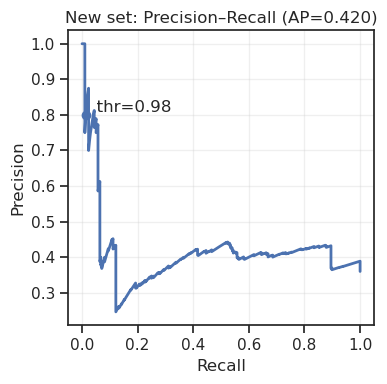

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

# --- Precision–Recall curve on new set ---
prec_new, rec_new, thr_new = precision_recall_curve(y_true, y_score)
ap_new = average_precision_score(y_true, y_score)

plt.figure()
plt.plot(rec_new, prec_new, linewidth=2)
# mark your operating threshold if it's on the grid
if len(thr_new):
    j = np.argmin(np.abs(thr_new - thr))
    if j < len(prec_new):
        plt.scatter(rec_new[j], prec_new[j])
        plt.text(rec_new[j], prec_new[j], f"  thr={thr:.2f}", va="bottom")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"New set: Precision–Recall (AP={ap_new:.3f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



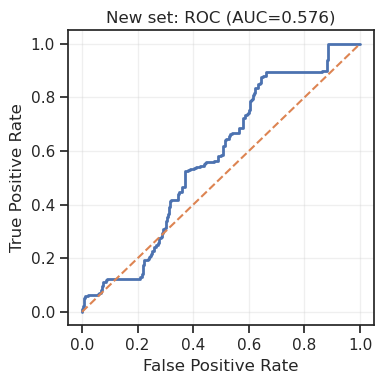

In [ ]:
# --- ROC curve on new set ---
fpr_new, tpr_new, _ = roc_curve(y_true, y_score)
auc_new = roc_auc_score(y_true, y_score)

plt.figure()
plt.plot(fpr_new, tpr_new, linewidth=2)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"New set: ROC (AUC={auc_new:.3f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


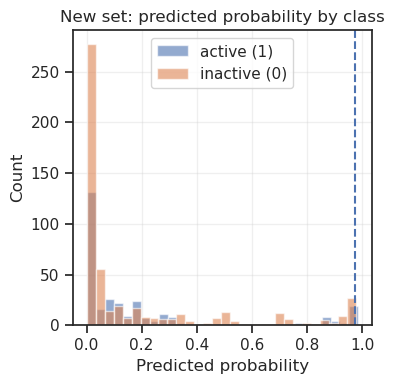

In [ ]:
# --- Probability distributions split by activity_exp on new set ---
plt.figure()
plt.hist(eval_df.loc[eval_df["activity_exp"] == 1, "pred_proba"], bins=30, alpha=0.6, label="active (1)")
plt.hist(eval_df.loc[eval_df["activity_exp"] == 0, "pred_proba"], bins=30, alpha=0.6, label="inactive (0)")
plt.axvline(thr, linestyle="--")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("New set: predicted probability by class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


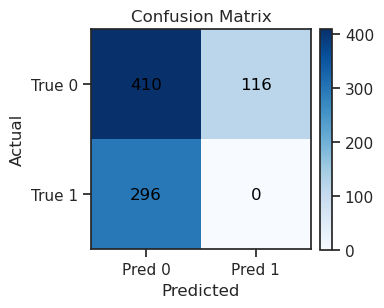

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")

# Labels
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(["Pred 0","Pred 1"])
ax.set_yticklabels(["True 0","True 1"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")

# Show counts in each cell
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_recall_fscore_support, confusion_matrix,
    roc_auc_score, average_precision_score, brier_score_loss
)

# ---------- 0) Label harmonization ----------
def ensure_label_bin(df, label_col_candidates=("label_bin", "activity")):
    """
    Create/standardize a binary label column 'label_bin' in-place.
    Supports either an existing 0/1 column or string labels like 'hydrolyzed'/'not hydrolyzed'.
    """
    df = df.copy()
    found = None
    for c in label_col_candidates:
        if c in df.columns:
            found = c
            break
    if found is None:
        raise ValueError("No label column found. Expected one of: %s" % (label_col_candidates,))

    if df[found].dtype == object:
        LABEL_MAP = {
            "hydrolyzed": 1, "not hydrolyzed": 0,
            "active": 1, "inactive": 0,
            "yes": 1, "no": 0,
            "1": 1, "0": 0
        }
        df["label_bin"] = (
            df[found].astype(str).str.strip().str.lower().map(LABEL_MAP)
        )
    else:
        df["label_bin"] = pd.to_numeric(df[found], errors="coerce")

    # Final cleanup to int 0/1
    df["label_bin"] = df["label_bin"].fillna(0).astype(int)
    return df

martinez_lbl = ensure_label_bin(martinez)
DEDB_lbl     = ensure_label_bin(DEDB)

# Mark source (optional but useful for debugging/domain shift)
martinez_lbl["source"] = "martinez"
DEDB_lbl["source"]     = "DEDB"

# ---------- 1) Combine datasets ----------
train_raw = pd.concat([martinez_lbl, DEDB_lbl], ignore_index=True)

# ---------- 2) Resolve duplicates across sources ----------
def resolve_duplicates_any_positive(
    df, feature_columns, key_cols=("Entry", "substrate_name"), label_col="label_bin"
):
    """
    If the same (Entry, substrate_name) appears multiple times (e.g., across sources),
    - label = 1 if ANY record is positive (liberal). Change to 'majority' or 'all' if you want stricter rules.
    - features are averaged across duplicates (numeric mean).
    - non-feature columns: take the first occurrence (except label aggregated as above).
    """
    df = df.copy()

    # Prepare aggregation dict
    agg_dict = {c: "first" for c in df.columns if c not in set(feature_columns) | set(key_cols) | {label_col}}
    # Features: numeric mean
    for c in feature_columns:
        agg_dict[c] = "mean"

    # Label: any-positive
    def any_pos(s):
        return int((pd.to_numeric(s, errors="coerce").fillna(0) == 1).any())

    agg_dict[label_col] = any_pos

    grouped = df.groupby(list(key_cols), dropna=False).agg(agg_dict).reset_index()
    return grouped

train_df = resolve_duplicates_any_positive(train_raw, feature_columns, key_cols=("Entry","substrate_name"), label_col="label_bin")

# ---------- 3) Train final model on combined data ----------
final_model, feature_order = train_final_xgb(train_df, feature_columns, label_col="label_bin")

# ---------- 4) Predict on experimental set ----------
preds_new = predict_activity_on_new(
    final_model,
    new_df=df_exptested,
    feature_columns=feature_columns,
    train_feature_order=feature_order,
    id_cols=("Entry","enzyme","substrate_name"),
    threshold=0.5  # you can replace with a CV-derived threshold if you have one
)

# ---------- 5) Attach truth (if available) and get quick metrics ----------
if "activity_exp" in df_exptested.columns:
    eval_df = preds_new.merge(
        df_exptested[["Entry","enzyme","activity_exp"]],
        on=["Entry","enzyme"], how="left"
    )
    y_true = eval_df["activity_exp"].astype(int).values
    y_score = eval_df["pred_proba"].values
    y_pred  = eval_df["pred_label"].astype(int).values

    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    print("Experimental set metrics @thr=0.5:")
    print(f"precision={prec:.3f}, recall={rec:.3f}, f1={f1:.3f}, tn={tn}, fp={fp}, fn={fn}, tp={tp}")
    print(f"ROC AUC={roc_auc_score(y_true, y_score):.3f}, AP={average_precision_score(y_true, y_score):.3f}, Brier={brier_score_loss(y_true, y_score):.3f}")

# ---------- 6) (Optional) Aggregate/evaluate at enzyme level ----------
def aggregate_predictions_by_enzyme(
    pred_df: pd.DataFrame,
    enzyme_col: str = "enzyme",
    proba_col: str = "pred_proba",
    threshold: float = 0.5,
    truth_col: str = "activity_exp",
    truth_reduce: str = "any"
):
    # Ensure enzyme & truth present
    df = pred_df.copy()
    if enzyme_col not in df.columns and "Entry" in df.columns:
        # bring enzyme from experimental DF if missing
        df = df.merge(df_exptested[["Entry", "enzyme"]].drop_duplicates(), on="Entry", how="left")

    # Aggregate predictions per enzyme
    g = df.groupby(enzyme_col)[proba_col]
    agg = g.agg(
        pred_proba_mean="mean",
        pred_proba_median="median",
        pred_proba_std="std",
        n_rows="size"
    ).reset_index()
    agg["pred_label"] = (agg["pred_proba_mean"] >= float(threshold)).astype(int)

    metrics = None
    # Aggregate truth per enzyme if available
    if truth_col in df.columns:
        tc = df[[enzyme_col, truth_col]].copy()
        tc[truth_col] = tc[truth_col].astype(float)

        if truth_reduce == "any":
            truth = tc.groupby(enzyme_col)[truth_col].agg(lambda s: int((s == 1).any())).reset_index()
        elif truth_reduce == "majority":
            truth = tc.groupby(enzyme_col)[truth_col].agg(lambda s: int((s.mean() >= 0.5))).reset_index()
        elif truth_reduce == "all":
            truth = tc.groupby(enzyme_col)[truth_col].agg(lambda s: int((s == 1).all())).reset_index()
        elif truth_reduce == "mean":
            truth = tc.groupby(enzyme_col)[truth_col].mean().reset_index().rename(columns={truth_col: "truth_mean"})
            truth[truth_col] = (truth["truth_mean"] >= 0.5).astype(int)
        else:
            raise ValueError("truth_reduce must be one of {'any','majority','all','mean'}")

        agg = agg.merge(truth, on=enzyme_col, how="left")

        if truth_col in agg.columns:
            y_true_e = agg[truth_col].astype(int).values
            y_score_e = agg["pred_proba_mean"].values
            y_pred_e  = agg["pred_label"].astype(int).values

            prec, rec, f1, _ = precision_recall_fscore_support(y_true_e, y_pred_e, average="binary", zero_division=0)
            tn, fp, fn, tp = confusion_matrix(y_true_e, y_pred_e).ravel()
            metrics = dict(
                threshold=float(threshold),
                precision=float(prec),
                recall=float(rec),
                f1=float(f1),
                tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp),
                roc_auc=float(roc_auc_score(y_true_e, y_score_e)) if len(np.unique(y_true_e)) > 1 else np.nan,
                avg_prec=float(average_precision_score(y_true_e, y_score_e)) if len(np.unique(y_true_e)) > 1 else np.nan,
                brier=float(brier_score_loss(y_true_e, y_score_e))
            )
    return agg, metrics

agg_enzyme, met_enzyme = aggregate_predictions_by_enzyme(
    preds_new.merge(df_exptested[["Entry","enzyme","activity_exp"]], on=["Entry","enzyme"], how="left"),
    enzyme_col="enzyme",
    proba_col="pred_proba",
    threshold=0.5,
    truth_col="activity_exp",
    truth_reduce="any"
)
print("Enzyme-level metrics:", met_enzyme)
print(agg_enzyme.head())


Experimental set metrics @thr=0.5:
precision=0.242, recall=0.017, f1=0.031, tn=6004, fp=238, fn=4444, tp=76
ROC AUC=0.509, AP=0.400, Brier=0.374
Enzyme-level metrics: {'threshold': 0.5, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'tn': 5, 'fp': 0, 'fn': 3, 'tp': 0, 'roc_auc': 0.3333333333333333, 'avg_prec': 0.3694444444444444, 'brier': 0.32056631034878497}
            enzyme  pred_proba_mean  pred_proba_median  pred_proba_std  \
0  BNFFOPBF_118865         0.107246           0.094375        0.092898   
1         CEMPOHJE         0.140275           0.038170        0.219060   
2         JMPBJLAA         0.073508           0.050845        0.075102   
3         MHHEAJED         0.082700           0.075296        0.040280   
4           O52787         0.175319           0.031406        0.208691   

   n_rows  pred_label  activity_exp  
0    1095           0             0  
1     903           0             0  
2    2707           0             0  
3     411           0             0  
4    1

# For DEDB:

/tmp/ipykernel_788256/2090731169.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[id_col].str.contains(regex, case=case, na=False)


[Cytochome c] patterns matched 24 unique IDs


/home/helen/miniconda3/envs/promiscuity/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_788256/2090731169.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[id_col].str.contains(regex, case=case, na=False)


[RmaNOD] patterns matched 8 unique IDs


/tmp/ipykernel_788256/263209506.py:112: RuntimeWarning: Mean of empty slice
  "roc_auc_mean": np.nanmean(df_sc["roc_auc"].values),
/home/helen/miniconda3/envs/promiscuity/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Skipped: []
          mode  folds_used  folds_with_auc  n_mean  n_sd  pos_rate_mean  \
0  Cytochome c           1               1 409.000   NaN          0.130   
1       RmaNOD           1               0 144.000   NaN          0.000   

   pos_rate_sd  acc_mean  acc_sd  f1_mean  f1_sd  precision_mean  \
0          NaN     0.425     NaN    0.311    NaN           0.184   
1          NaN     0.868     NaN      NaN    NaN             NaN   

   precision_sd  recall_mean  recall_sd  roc_auc_mean  roc_auc_sd  
0           NaN        1.000        NaN         0.453         NaN  
1           NaN          NaN        NaN           NaN         NaN  


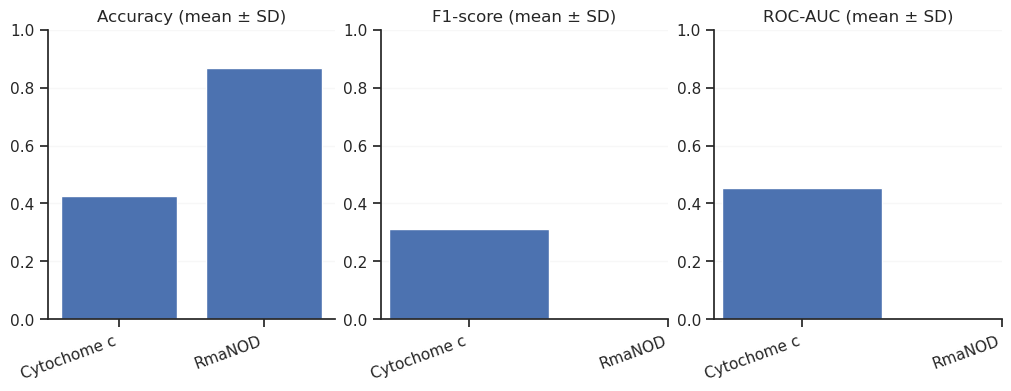

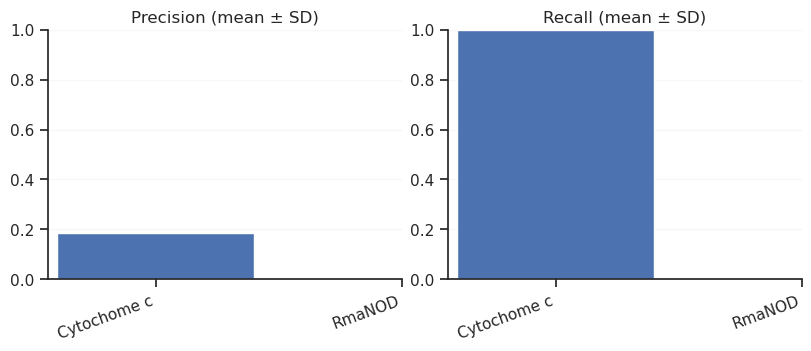

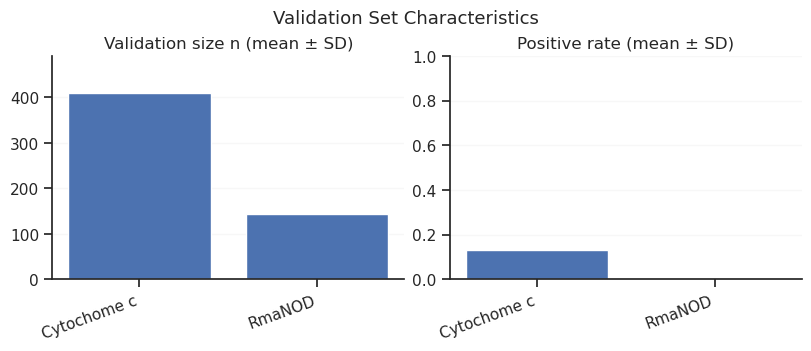

In [ ]:
# =======================
# MULTI-RUN CUSTOM HOLDOUTS (by IDs or patterns)
# =======================

import matplotlib.pyplot as plt

def clean_plt(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.15)

def get_val_ids_from_patterns(df, id_col, patterns, case=False):
    """Resolve pattern list -> list of matching IDs."""
    import re
    if not patterns:
        return []
    df = df.copy()
    df[id_col] = df[id_col].astype(str).str.strip()
    regex = "(" + "|".join(re.escape(p) for p in patterns) + ")"
    mask = df[id_col].str.contains(regex, case=case, na=False)
    return df.loc[mask, id_col].unique().tolist()

def run_multiple_holdouts(
    df,
    feature_columns,
    label_col="label_bin",
    id_col="Entry",
    specs=None,
    case=False,
    skip_single_class=False,
    verbose=True,
):
    """
    Run many custom holdouts. Each spec is:
      {"name": <label>,
       "ids": [list of IDs],             # OR
       "patterns": [list of substrings]} # resolves to IDs via contains()

    Returns: (summary_df, skipped)
      - summary_df has the same schema you used earlier.
      - skipped: list of (name, reason) for holdouts we didn’t run.
    """
    if not specs:
        raise ValueError("Provide a non-empty list of holdout specs.")

    results = []
    skipped = []

    for spec in specs:
        name = spec.get("name", "unnamed")
        ids = spec.get("ids")
        patterns = spec.get("patterns")

        try:
            if patterns is not None:
                val_ids = get_val_ids_from_patterns(df, id_col, patterns, case=case)
                if verbose:
                    print(f"[{name}] patterns matched {len(val_ids)} unique IDs")
                if not val_ids:
                    skipped.append((name, "no IDs matched patterns"))
                    continue
                summary = evaluate_holdout_by_ids(
                    df, feature_columns=feature_columns, label_col=label_col,
                    id_col=id_col, val_ids=val_ids
                )
            elif ids is not None:
                if not ids:
                    skipped.append((name, "empty ids list"))
                    continue
                summary = evaluate_holdout_by_ids(
                    df, feature_columns=feature_columns, label_col=label_col,
                    id_col=id_col, val_ids=ids
                )
            else:
                skipped.append((name, "spec must have 'ids' or 'patterns'"))
                continue

            # Optionally skip if the validation set turned out single-class (you’ll see NaNs)
            if skip_single_class and (
                pd.isna(summary.get("precision_mean")) and
                pd.isna(summary.get("recall_mean")) and
                pd.isna(summary.get("f1_mean"))
            ):
                skipped.append((name, "single-class validation"))
                continue

            results.append({"mode": name, **summary})

        except Exception as e:
            skipped.append((name, f"error: {e}"))

    # Build consistent summary DF (same columns you used)
    summary_df = pd.DataFrame(results, columns=[
        "mode",
        "folds_used", "folds_with_auc",
        "n_mean", "n_sd",
        "pos_rate_mean", "pos_rate_sd",
        "acc_mean", "acc_sd",
        "f1_mean", "f1_sd",
        "precision_mean", "precision_sd",
        "recall_mean", "recall_sd",
        "roc_auc_mean", "roc_auc_sd",
    ])
    return summary_df, skipped

def _bar_with_error(ax, xlabels, means, sds, title, ylim=None):
    import numpy as np
    x = np.arange(len(xlabels))
    ax.bar(x, means, yerr=sds, capsize=5)
    ax.set_xticks(x, xlabels, rotation=20, ha="right")
    ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    clean_plt(ax)

def plot_validation_summaries(summary_df, save_prefix=None):
    """Same visualization as before, now reusable for multi-holdout results."""
    dfp = summary_df.copy()
    for col in ["acc_mean","acc_sd","f1_mean","f1_sd","roc_auc_mean","roc_auc_sd",
                "precision_mean","precision_sd","recall_mean","recall_sd",
                "n_mean","n_sd","pos_rate_mean","pos_rate_sd"]:
        if col in dfp.columns:
            dfp[col] = pd.to_numeric(dfp[col], errors="coerce")

    xlabels = dfp["mode"].tolist()

    fig, axes = plt.subplots(1, 3, figsize=(10, 3.8), constrained_layout=True)
    _bar_with_error(axes[0], xlabels, dfp["acc_mean"], dfp["acc_sd"], "Accuracy (mean ± SD)", ylim=(0,1))
    _bar_with_error(axes[1], xlabels, dfp["f1_mean"],  dfp["f1_sd"],  "F1-score (mean ± SD)", ylim=(0,1))
    _bar_with_error(axes[2], xlabels, dfp["roc_auc_mean"], dfp["roc_auc_sd"], "ROC-AUC (mean ± SD)", ylim=(0,1))
    if save_prefix: fig.savefig(f"{save_prefix}_metrics.png", dpi=150)

    fig_pr, axes_pr = plt.subplots(1, 2, figsize=(8, 3.4), constrained_layout=True)
    _bar_with_error(axes_pr[0], xlabels, dfp["precision_mean"], dfp["precision_sd"], "Precision (mean ± SD)", ylim=(0,1))
    _bar_with_error(axes_pr[1], xlabels, dfp["recall_mean"],    dfp["recall_sd"],    "Recall (mean ± SD)",    ylim=(0,1))
    if save_prefix: fig_pr.savefig(f"{save_prefix}_precision_recall.png", dpi=150)

    fig2, axes2 = plt.subplots(1, 2, figsize=(8, 3.4), constrained_layout=True)
    ymax = 0 if dfp["n_mean"].isna().all() else max(1, float(dfp["n_mean"].max())*1.2)
    _bar_with_error(axes2[0], xlabels, dfp["n_mean"], dfp["n_sd"], "Validation size n (mean ± SD)", ylim=(0, ymax))
    _bar_with_error(axes2[1], xlabels, dfp["pos_rate_mean"], dfp["pos_rate_sd"], "Positive rate (mean ± SD)", ylim=(0,1))
    fig2.suptitle("Validation Set Characteristics", fontsize=13)
    if save_prefix: fig2.savefig(f"{save_prefix}_set_characteristics.png", dpi=150)
    plt.show()


holdout_specs = [
    {"name": "Cytochome c", "patterns": ["R19", "P19", "R20", "P20", "R18", "P18", "P33", "R33", "R34", "P34", "P18", "R18"]},
    {"name": "RmaNOD", "patterns": ["R22", "P22", "R38", "P38", "R23", "P23", "P21", "R21"]}
]


holdout_patterns = ["R19", "P19", "R20", "P20", "R18", "P18", "P33", "R33", "R34", "P34", "P18", "R18"]
holdout_patterns = ["R22", "P22", "R38", "P38", "R23", "P23", "P21", "R21"]

summary_df_dedb, skipped = run_multiple_holdouts(
    df=DEDB,                       # your DEDB DataFrame with label_bin already set
    feature_columns=feature_columns,
    label_col="label_bin",
    id_col="Entry",
    specs=holdout_specs,
    case=False,                    # case-insensitive matching
    skip_single_class=False,       # set True to auto-skip degenerate single-class validations
    verbose=True,
)

print("Skipped:", skipped)
with pd.option_context('display.float_format', '{:.3f}'.format):
    print(summary_df_dedb)

plot_validation_summaries(summary_df_dedb, save_prefix="dedb_custom")


DEDB holdout of cytochromes and RMANOD:

- RmaCyt-> P18, R18
- TDE -> R33, P33
- RDT -> P34, R34
- BORLAC -> P19, R19
- BORLAC_parent -> P20, R20

- THRAW -> P22, R22
- WAIHNM -> P38, R38
- THRAW_parent -> P23, R23
- RMANOD -> P21, R21


### For DEDB